In [652]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import requests
from io import StringIO
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample
from sklearn.neighbors import KNeighborsClassifier

In [134]:

base_url = "https://www.metoffice.gov.uk/pub/data/weather/uk/climate/stationdata/{}data.txt"
dataset_names = [
    "aberporth", "armagh", "ballypatrick", "bradford", "braemar",
    "camborne", "cambridge", "cardiff", "chivenor", "cwmystwyth",
    "dunstaffnage", "durham", "eastbourne", "eskdalemuir", "heathrow",
    "hurn", "lerwick", "leuchars", "lowestoft", "manston",
    "nairn", "newtonrigg", "oxford", "paisley", "ringway",
    "rossonwye", "shawbury", "sheffield", "southampton", "stornoway",
    "suttonbonington", "tiree", "valley", "waddington", "whitby",
    "wickairport", "yeovilton"
]

combined_data = []

for name in dataset_names:
    url = base_url.format(name)
    response = requests.get(url)

    if response.status_code == 200:
        lines = response.text.splitlines()

        # Check if site is closed
        is_closed = lines[-1].strip().lower().startswith("site closed")

        # Locate the header line
        start_index = next((i for i, line in enumerate(lines) if line.strip().lower().startswith("yyyy")), None)

        if start_index is not None:
            data_text = "\n".join(lines[start_index:])

            try:
                df = pd.read_csv(StringIO(data_text), delim_whitespace=True, usecols=range(7))
                df.columns = ['yyyy', 'mm', 'tmax', 'tmin', 'af', 'rain', 'sun']
                df['station'] = name
                df['is_closed'] = 'yes' if is_closed else 'no'
                combined_data.append(df)
            except Exception as e:
                print(f"Failed to parse {name}: {e}")
        else:
            print(f"Header not found in {name}")
    else:
        print(f"Failed to download data for {name}")

# Combine and save
if combined_data:
    final_df = pd.concat(combined_data, ignore_index=True)

    # Remove header rows mistakenly parsed as data (e.g., where tmax == 'degC')
    final_df = final_df[final_df['tmax'].astype(str).str.lower() != 'degc']
    # Remove anything except digits, one dot, and one minus sign
    final_df['sun'] = final_df['sun'].astype(str).str.replace('[^0-9.\-#*]', '', regex=True) ### This was added after finding some symbols like $ in sun 

    #final_df=final_df[final_df['sun'] != '152.0Change']
    #final_df['sun']=final_df['sun'].str.replace('71.6all', '') # To be added in the automation script
    #final_df['sun']=final_df['sun'].str.replace('$', '')# To be added in the automation script

    final_df.to_csv("combined_weather_data_latest.csv", index=False)
    print("Combined data saved to combined_weather_data.csv")
else:
    print("No valid data to combine.")


Combined data saved to combined_weather_data.csv


In [135]:
df=pd.read_csv('combined_weather_data_latest.csv')
df

,yyyy,mm,tmax,tmin,af,rain,sun,station,is_closed
0,degC,degC,days,mm,hours,NaN,NaN,aberporth,no
1,1941,1,---,---,---,74.7,---,aberporth,no
2,1941,2,---,---,---,69.1,---,aberporth,no
3,1941,3,---,---,---,76.2,---,aberporth,no
4,1941,4,---,---,---,33.7,---,aberporth,no
...,...,...,...,...,...,...,...,...,...
39740,2024,11,11.7,5.1,7,88.6,48.8#,yeovilton,no
39741,2024,12,10.5,5.0,1,29.6,27.9#,yeovilton,no
39742,2025,1,8.0,0.8,11,139.0,57.1#,yeovilton,no
39743,2025,2,8.9,2.8,5,51.2,55.8#,yeovilton,no


In [136]:
# Dropping the second row which has the measuearmunt units and the rows which has site closed solumns and they have been added to a column is_closed to recognize the closed stations
df=df[df['yyyy'] != 'Site'] # remove the records whihc has the value site closed
df=df.iloc[1:] # drop the first row which has measuemnt units
df

,yyyy,mm,tmax,tmin,af,rain,sun,station,is_closed
1,1941,1,---,---,---,74.7,---,aberporth,no
2,1941,2,---,---,---,69.1,---,aberporth,no
3,1941,3,---,---,---,76.2,---,aberporth,no
4,1941,4,---,---,---,33.7,---,aberporth,no
5,1941,5,---,---,---,51.3,---,aberporth,no
...,...,...,...,...,...,...,...,...,...
39740,2024,11,11.7,5.1,7,88.6,48.8#,yeovilton,no
39741,2024,12,10.5,5.0,1,29.6,27.9#,yeovilton,no
39742,2025,1,8.0,0.8,11,139.0,57.1#,yeovilton,no
39743,2025,2,8.9,2.8,5,51.2,55.8#,yeovilton,no


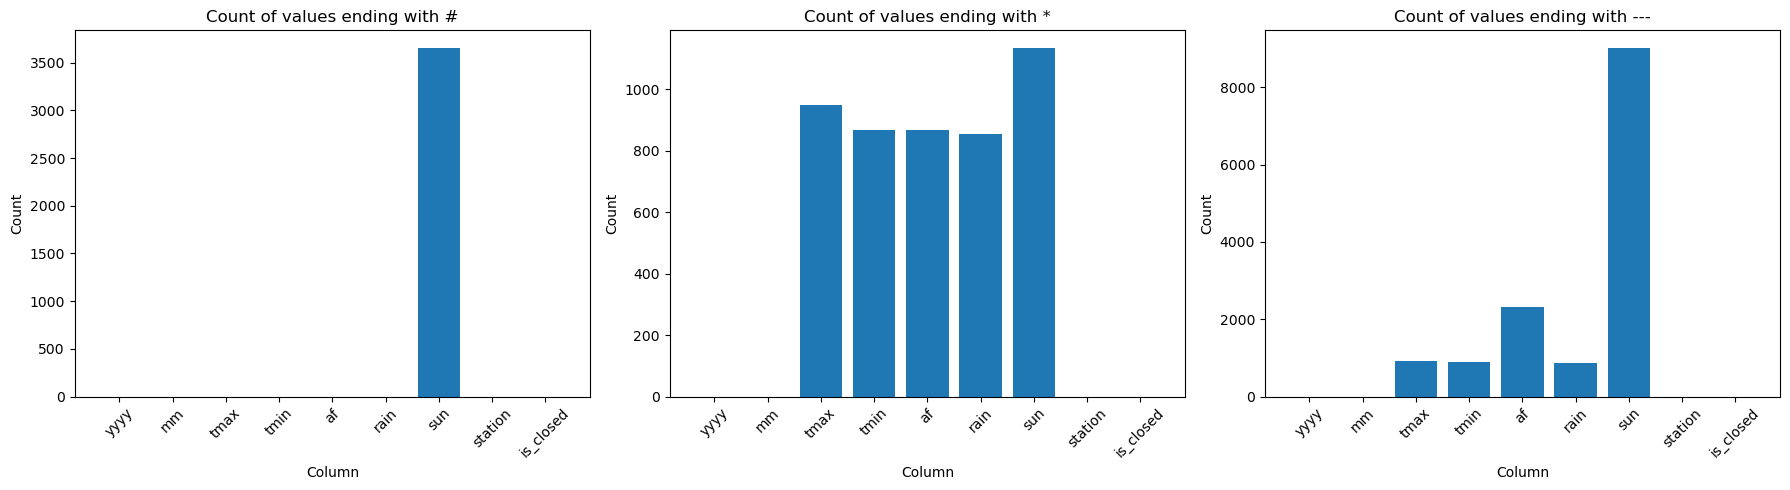

In [137]:

# Count of values ending with '#', '*', and '--' in each column
count_hash = df.applymap(lambda x: str(x).endswith('#')).sum()
count_star = df.applymap(lambda x: str(x).endswith('*')).sum()
count_dash = df.applymap(lambda x: str(x).endswith('---')).sum()


fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].bar(count_hash.index, count_hash.values)
axs[0].set_title("Count of values ending with #")
axs[0].set_ylabel("Count")
axs[0].set_xlabel("Column")
axs[0].tick_params(axis='x', rotation=45)

axs[1].bar(count_star.index, count_star.values)
axs[1].set_title("Count of values ending with *")
axs[1].set_ylabel("Count")
axs[1].set_xlabel("Column")
axs[1].tick_params(axis='x', rotation=45)

axs[2].bar(count_dash.index, count_dash.values)
axs[2].set_title("Count of values ending with ---")
axs[2].set_ylabel("Count")
axs[2].set_xlabel("Column")
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [138]:
df['sunshine_sensor'] = df.apply(lambda row: 'Kipp and Zonen' if any(str(x).endswith('#') for x in row) else 'Campbell-Stokes', axis=1)
df = df.applymap(lambda x: str(x).replace('#', '') if pd.notnull(x) else x) ## Remove # from sun values as we have added new column sunshine_sensor to identify the sensor type
df

,yyyy,mm,tmax,tmin,af,rain,sun,station,is_closed,sunshine_sensor
1,1941,1,---,---,---,74.7,---,aberporth,no,Campbell-Stokes
2,1941,2,---,---,---,69.1,---,aberporth,no,Campbell-Stokes
3,1941,3,---,---,---,76.2,---,aberporth,no,Campbell-Stokes
4,1941,4,---,---,---,33.7,---,aberporth,no,Campbell-Stokes
5,1941,5,---,---,---,51.3,---,aberporth,no,Campbell-Stokes
...,...,...,...,...,...,...,...,...,...,...
39740,2024,11,11.7,5.1,7,88.6,48.8,yeovilton,no,Kipp and Zonen
39741,2024,12,10.5,5.0,1,29.6,27.9,yeovilton,no,Kipp and Zonen
39742,2025,1,8.0,0.8,11,139.0,57.1,yeovilton,no,Kipp and Zonen
39743,2025,2,8.9,2.8,5,51.2,55.8,yeovilton,no,Kipp and Zonen


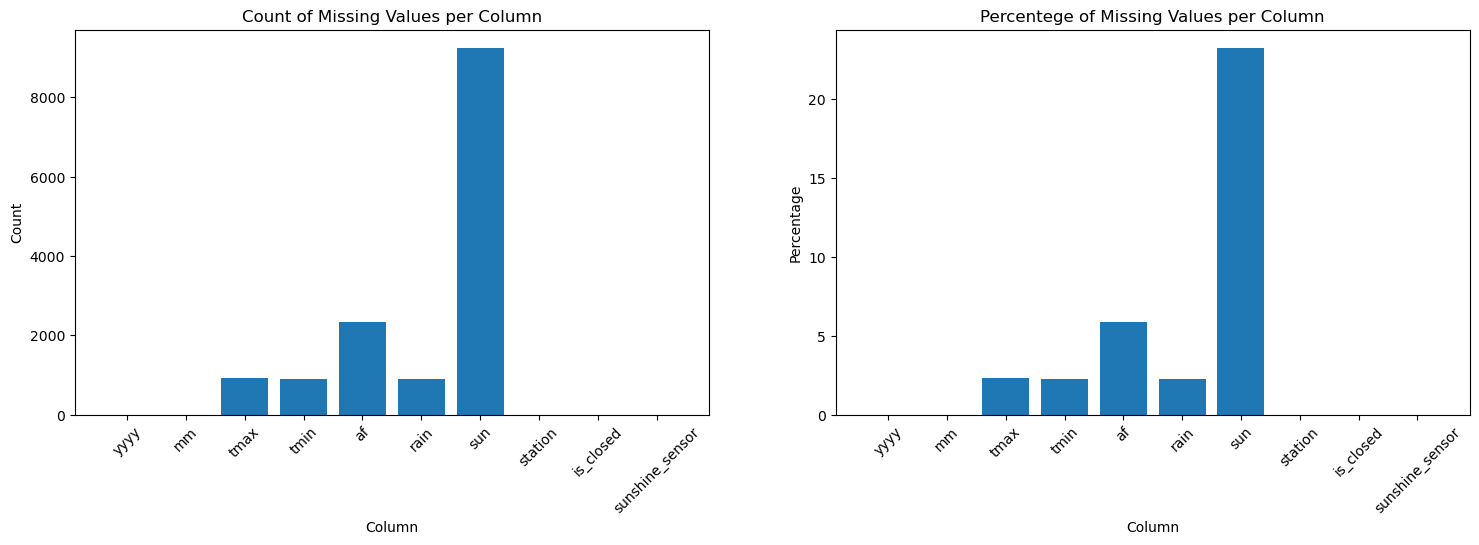

In [139]:
df.replace('---', np.nan, inplace=True)

missing = df.isnull().sum()

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(18, 5))

axs[0].bar((df.isnull().sum()).index, (df.isnull().sum()).values)
axs[0].set_title("Count of Missing Values per Column")
axs[0].set_ylabel("Count")
axs[0].set_xlabel("Column")
axs[0].tick_params(axis='x', rotation=45)

axs[1].bar((df.isnull().sum() / len(df)).index, ((df.isnull().sum() / len(df))*100).values)
axs[1].set_title("Percentege of Missing Values per Column")
axs[1].set_ylabel("Percentage")
axs[1].set_xlabel("Column")
axs[1].tick_params(axis='x', rotation=45)

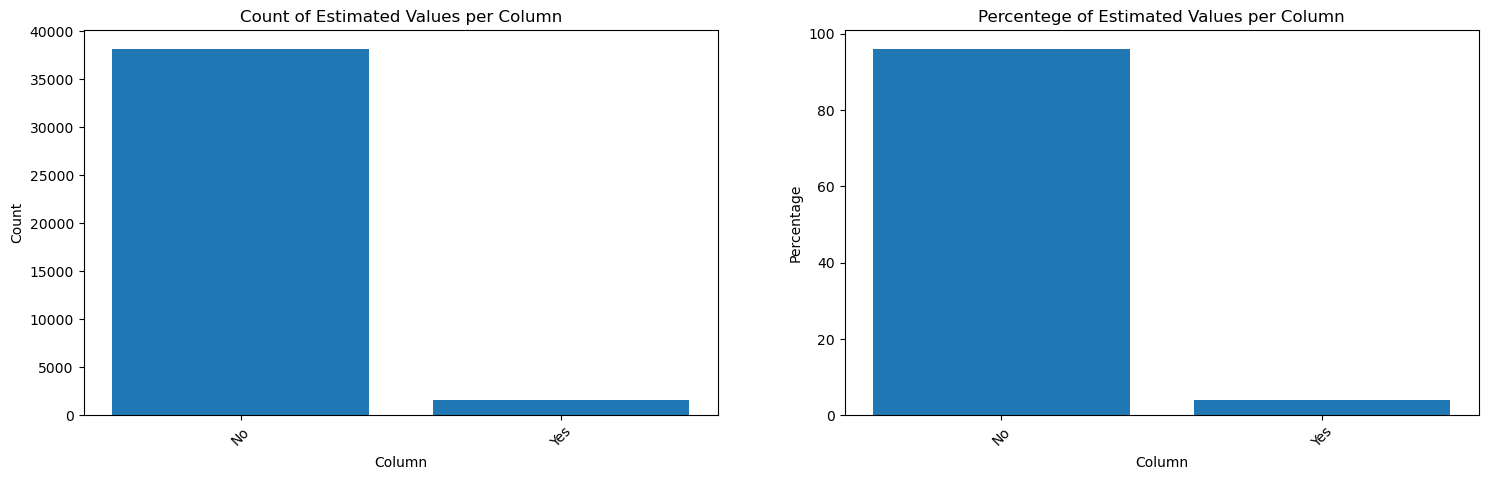

In [140]:
df['has_estimated_values'] = df.apply(lambda row: 'Yes' if any('*' in str(val) for val in row if pd.notnull(val)) else 'No',axis=1)
df = df.applymap(lambda x: str(x).replace('*', '') if pd.notnull(x) else x) ## Remove * from sun values as we have added new column has_estimated_values to identify the estimated values
df[df['has_estimated_values']== 'Yes']
Estimated=df['has_estimated_values'].value_counts()

fig, axs = plt.subplots(1, 2, figsize=(18, 5))

axs[0].bar(Estimated.index, Estimated.values)
axs[0].set_title("Count of Estimated Values per Column")
axs[0].set_ylabel("Count")
axs[0].set_xlabel("Column")
axs[0].tick_params(axis='x', rotation=45)

axs[1].bar(Estimated.index, ((Estimated / len(df))*100).values)
axs[1].set_title("Percentege of Estimated Values per Column")
axs[1].set_ylabel("Percentage")
axs[1].set_xlabel("Column")
axs[1].tick_params(axis='x', rotation=45)



In [141]:
print("The DataFrame", df)
print ('___________________________________________')
print("The Count for # Againest each Column\n", df.applymap(lambda x: str(x).endswith('#')).sum())
print ('___________________________________________')
print("The Count for * Againest each Column\n", df.applymap(lambda x: str(x).endswith('*')).sum())
print ('___________________________________________')
print("The Count for * Againest each Column\n", df.applymap(lambda x: str(x).endswith('--')).sum())

The DataFrame        yyyy  mm  tmax tmin   af   rain    sun    station is_closed  \
1      1941   1   NaN  NaN  NaN   74.7    NaN  aberporth        no   
2      1941   2   NaN  NaN  NaN   69.1    NaN  aberporth        no   
3      1941   3   NaN  NaN  NaN   76.2    NaN  aberporth        no   
4      1941   4   NaN  NaN  NaN   33.7    NaN  aberporth        no   
5      1941   5   NaN  NaN  NaN   51.3    NaN  aberporth        no   
...     ...  ..   ...  ...  ...    ...    ...        ...       ...   
39740  2024  11  11.7  5.1    7   88.6   48.8  yeovilton        no   
39741  2024  12  10.5  5.0    1   29.6   27.9  yeovilton        no   
39742  2025   1   8.0  0.8   11  139.0   57.1  yeovilton        no   
39743  2025   2   8.9  2.8    5   51.2   55.8  yeovilton        no   
39744  2025   3  13.0  2.3   12    6.4  166.4  yeovilton        no   

       sunshine_sensor has_estimated_values  
1      Campbell-Stokes                   No  
2      Campbell-Stokes                   No  
3      

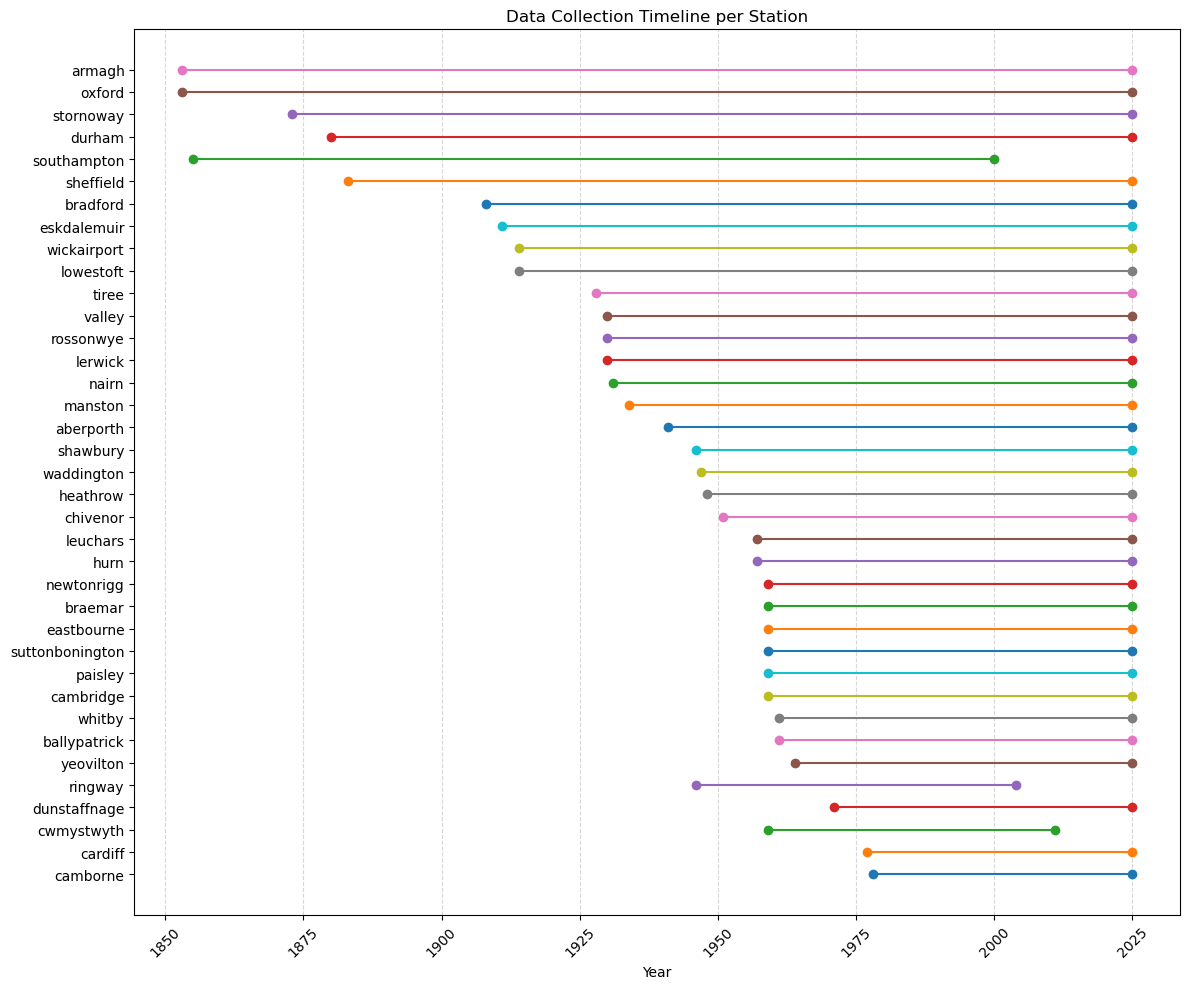

In [142]:
### Let's now check the data completness over the years
df['yyyy'] = pd.to_numeric(df['yyyy'], errors='coerce')
station_years = df.groupby('station')['yyyy'].agg(['min', 'max', 'nunique']).reset_index()
station_years.columns = ['station', 'min', 'max', 'year_count']

# Sort stations by most complete (longest) data span
station_years = station_years.sort_values(by='year_count', ascending=True).reset_index(drop=True)

# Plot the timeline sorted by data completeness
plt.figure(figsize=(12, 10))
for i, row in station_years.iterrows():
    plt.plot([row['min'], row['max']], [i, i], marker='o')

plt.yticks(range(len(station_years)), station_years['station'])
plt.xlabel("Year")
plt.title("Data Collection Timeline per Station")
plt.xticks(rotation=45)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


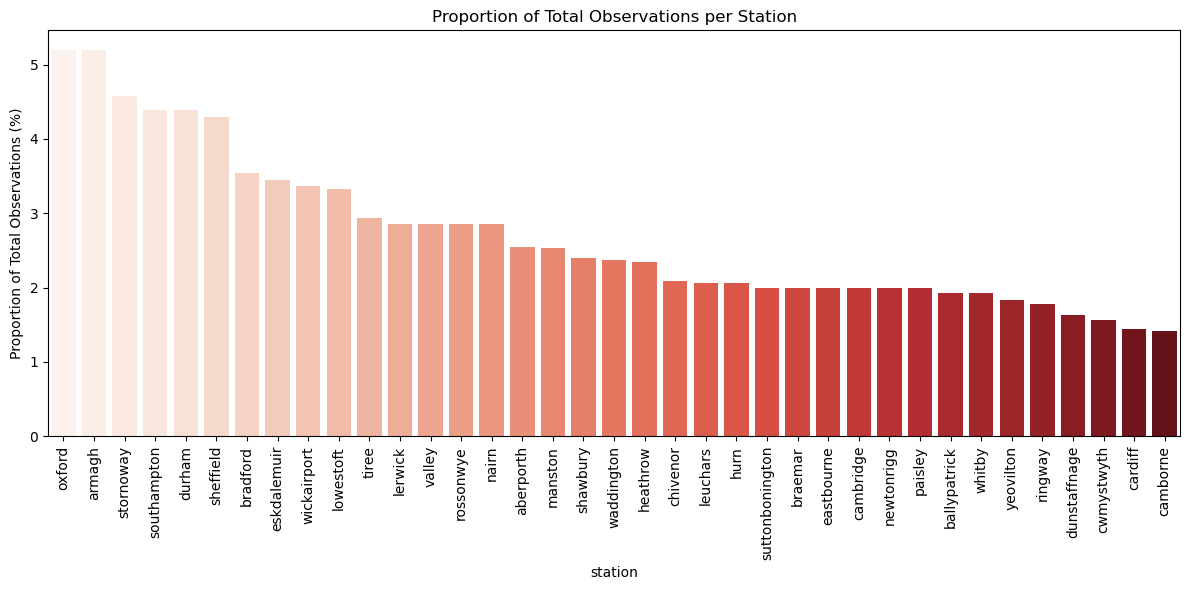

In [143]:
### From the above chart we coud see that we have a variance in the datat collection time, where some stations have less number of years which will make the data imbalanmced for each station, let check the proportions for each station
# Count the number of observations per station
station_counts = df['station'].value_counts().reset_index()
station_counts.columns = ['station', 'record_count']

# Calculate total number of observations
total_obs = station_counts['record_count'].sum()

# Add proportion column
station_counts['proportion'] = (station_counts['record_count'] / total_obs * 100).round(2)

# Sort by proportion descending
station_counts = station_counts.sort_values(by='proportion', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=station_counts, x='station', y='proportion', palette='Reds')
plt.xticks(rotation=90)
plt.ylabel("Proportion of Total Observations (%)")
plt.title("Proportion of Total Observations per Station")
plt.tight_layout()
plt.show()

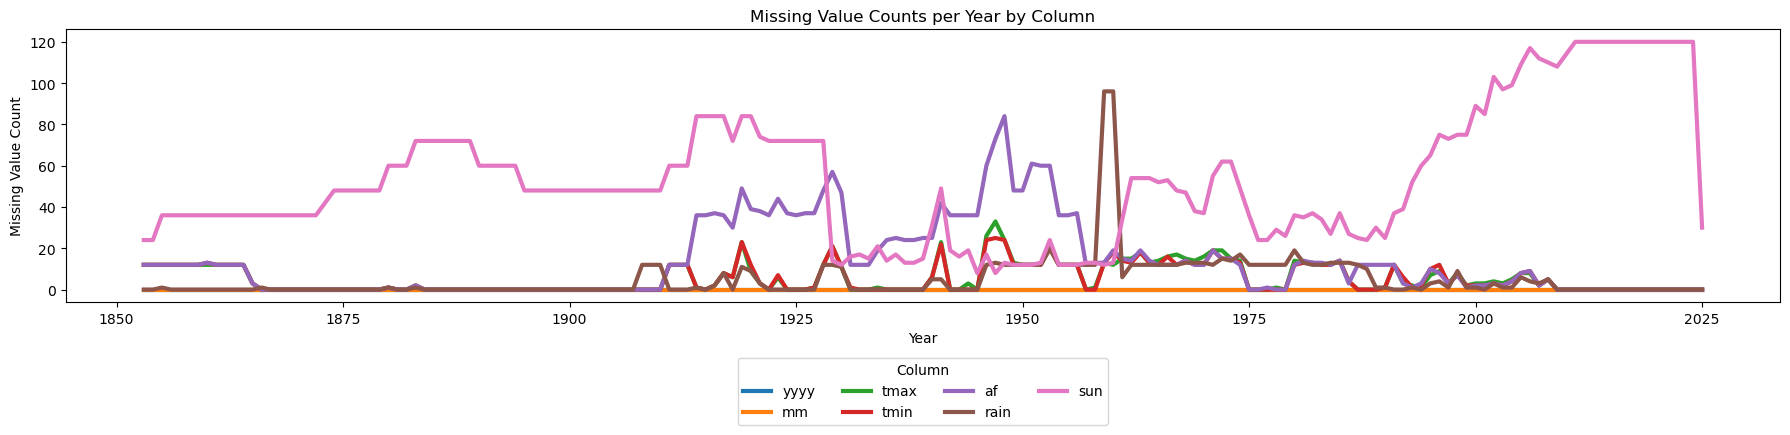

In [144]:

cols_to_numeric = ['yyyy', 'mm', 'tmax', 'tmin', 'af', 'rain', 'sun']

for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

missing_per_year = df[['yyyy', 'mm', 'tmax', 'tmin', 'af', 'rain', 'sun']].isna().groupby(df['yyyy']).sum().sort_index()

fig, ax = plt.subplots(figsize=(18, 6))
missing_per_year.plot(ax=ax, linewidth=3)
ax.set_xlabel('Year')
ax.set_ylabel('Missing Value Count')
ax.set_title('Missing Value Counts per Year by Column')
ax.legend(
    title='Column',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4
)

# Adjust layout to make room for legend
plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()

In [145]:
### From the above line chart, we could see the missing values count over years, I can see that sun is having higher number of null values from 1990 to 2025 also from 1850 to 1930

#### Opss, we can see a staion like has around 5.5 of the data set while a station like cambrone has 1.6% which means we can't take the entire data set for the clustering as it will be imbalamced, however, let's fill the null values first and then will proceed further on how to pick the dataset


In [147]:
# Iam getting an error that tmax has non nueric values like ""ValueError: Unable to parse string "days" at position 993"", let's check what is that error
df_tmax_not_missing[df_tmax_not_missing['tmax'] == 'days']

,yyyy,mm,tmax,tmin,af,rain,sun,station,is_closed,sunshine_sensor,has_estimated_values,season


In [148]:
## I am gettong multiple rows which has degC	degC	days	mm	hours	NaN	NaN	armagh	no	Campbell-Stokes	No which is the header from the files which we retrieved from the website
## it's an issue which hsould have been handeled during fetcheing the data from the website where we had to deop the headers of the files (first two rows) and then proceed
## let's fix for now by excluding those columns from the main dataframe (df) and recreate df_tmax_not_missing

df=df[df['tmax'] != 'days']
df_tmax_not_missing=df[df['tmax'].notnull()]
df_tmax_not_missing[df_tmax_not_missing['tmax'] == 'days'] ## to check whether those unwanted headers still exsit

,yyyy,mm,tmax,tmin,af,rain,sun,station,is_closed,sunshine_sensor,has_estimated_values


In [149]:
## I am gettong multiple rows which has degC	degC	days	mm	hours	NaN	NaN	armagh	no	Campbell-Stokes	No which is the header from the files which we retrieved from the website
## it's an issue which hsould have been handeled during fetcheing the data from the website where we had to deop the headers of the files (first two rows) and then proceed
## let's fix for now by excluding those columns from the main dataframe (df) and recreate df_tmax_not_missing

df=df[df['tmax'] != 'days']
df_tmax_not_missing=df[df['tmax'].notnull()]
df_tmax_not_missing[df_tmax_not_missing['tmax'] == 'days'] ## to check whether those unwanted headers still exsit
df_tmax_not_missing

,yyyy,mm,tmax,tmin,af,rain,sun,station,is_closed,sunshine_sensor,has_estimated_values
13,1942.0,1.0,5.8,2.1,NaN,114.0,58.0,aberporth,no,Campbell-Stokes,No
14,1942.0,2.0,4.2,-0.6,NaN,13.8,80.3,aberporth,no,Campbell-Stokes,No
15,1942.0,3.0,9.7,3.7,NaN,58.0,117.9,aberporth,no,Campbell-Stokes,No
16,1942.0,4.0,13.1,5.3,NaN,42.5,200.1,aberporth,no,Campbell-Stokes,No
17,1942.0,5.0,14.0,6.9,NaN,101.1,215.1,aberporth,no,Campbell-Stokes,No
...,...,...,...,...,...,...,...,...,...,...,...
39740,2024.0,11.0,11.7,5.1,7.0,88.6,48.8,yeovilton,no,Kipp and Zonen,No
39741,2024.0,12.0,10.5,5.0,1.0,29.6,27.9,yeovilton,no,Kipp and Zonen,No
39742,2025.0,1.0,8.0,0.8,11.0,139.0,57.1,yeovilton,no,Kipp and Zonen,No
39743,2025.0,2.0,8.9,2.8,5.0,51.2,55.8,yeovilton,no,Kipp and Zonen,No


In [150]:
## We have successfully dropped them, let's try to convert the data type for tmax from object to float again
df_tmax_not_missing['tmax'] = pd.to_numeric(df_tmax_not_missing['tmax'])
df_tmax_not_missing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38777 entries, 13 to 39744
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   yyyy                  38777 non-null  float64
 1   mm                    38777 non-null  float64
 2   tmax                  38777 non-null  float64
 3   tmin                  38749 non-null  float64
 4   af                    37317 non-null  float64
 5   rain                  38101 non-null  float64
 6   sun                   30098 non-null  float64
 7   station               38777 non-null  object 
 8   is_closed             38777 non-null  object 
 9   sunshine_sensor       38777 non-null  object 
 10  has_estimated_values  38777 non-null  object 
dtypes: float64(7), object(4)
memory usage: 3.6+ MB


In [151]:
## Great!! it worked !!
##let's get some statistical information now
df_tmax_not_missing['tmax'].describe()

count    38777.000000
mean        12.797470
std          5.044429
min         -0.900000
25%          8.600000
50%         12.400000
75%         16.900000
max         28.300000
Name: tmax, dtype: float64

In [152]:
## based on the column mm, the classification will happen considirng 12, 1, 2 under winter, 3, 4, 5 Spring, 6, 7, 8 Summer and 9,10, 11 Autumn
def get_season(month):
    month = int(month)
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df_tmax_not_missing['season'] = df_tmax_not_missing['mm'].astype(int).apply(get_season)
df_tmax_not_missing

,yyyy,mm,tmax,tmin,af,rain,sun,station,is_closed,sunshine_sensor,has_estimated_values,season
13,1942.0,1.0,5.8,2.1,NaN,114.0,58.0,aberporth,no,Campbell-Stokes,No,Winter
14,1942.0,2.0,4.2,-0.6,NaN,13.8,80.3,aberporth,no,Campbell-Stokes,No,Winter
15,1942.0,3.0,9.7,3.7,NaN,58.0,117.9,aberporth,no,Campbell-Stokes,No,Spring
16,1942.0,4.0,13.1,5.3,NaN,42.5,200.1,aberporth,no,Campbell-Stokes,No,Spring
17,1942.0,5.0,14.0,6.9,NaN,101.1,215.1,aberporth,no,Campbell-Stokes,No,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...
39740,2024.0,11.0,11.7,5.1,7.0,88.6,48.8,yeovilton,no,Kipp and Zonen,No,Autumn
39741,2024.0,12.0,10.5,5.0,1.0,29.6,27.9,yeovilton,no,Kipp and Zonen,No,Winter
39742,2025.0,1.0,8.0,0.8,11.0,139.0,57.1,yeovilton,no,Kipp and Zonen,No,Winter
39743,2025.0,2.0,8.9,2.8,5.0,51.2,55.8,yeovilton,no,Kipp and Zonen,No,Winter


In [153]:
## great, w eare getting closer to based on the season, the was 12.797470 for the entire dataset, now it's varying from 7 to 13 with smaller standard deviation.
## I could see that the data is almost ditributed equally between the seasons based on the count, now let's plot the data out and see.
tmax_stats_per_season = df_tmax_not_missing.groupby('season')['tmax'].describe()
tmax_stats_per_season

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
Autumn,9685.0,13.351740,3.548218,3.5,10.5,13.3,16.0,24.4
Spring,9696.0,11.955074,3.122992,2.7,9.7,11.8,14.1,21.1
Summer,9660.0,18.776874,2.646145,11.0,17.0,18.8,20.6,28.3
Winter,9736.0,7.152311,1.952102,-0.9,5.9,7.3,8.5,13.7


In [1404]:
df.describe()

,yyyy,mm,tmax,tmin,af,rain,sun
count,39705.000000,39705.000000,39705.000000,39705.000000,39705.000000,39705.000000,39705.000000
mean,1971.716736,6.491651,12.810242,5.996765,3.468108,73.587302,117.922164
std,37.651925,3.455728,5.035460,4.062468,5.113048,48.281631,61.417501
min,1853.000000,1.000000,-0.900000,-8.600000,0.000000,0.000000,2.800000
25%,1951.000000,3.000000,8.600000,2.700000,0.000000,39.700000,64.800000
50%,1978.000000,6.000000,12.500000,5.600000,1.000000,63.400000,112.000000
75%,2001.000000,9.000000,16.900000,9.500000,6.000000,95.800000,163.293750
max,2025.000000,12.000000,28.300000,17.000000,31.000000,568.800000,350.300000


In [174]:
df=df[~df['mm'].isna()]

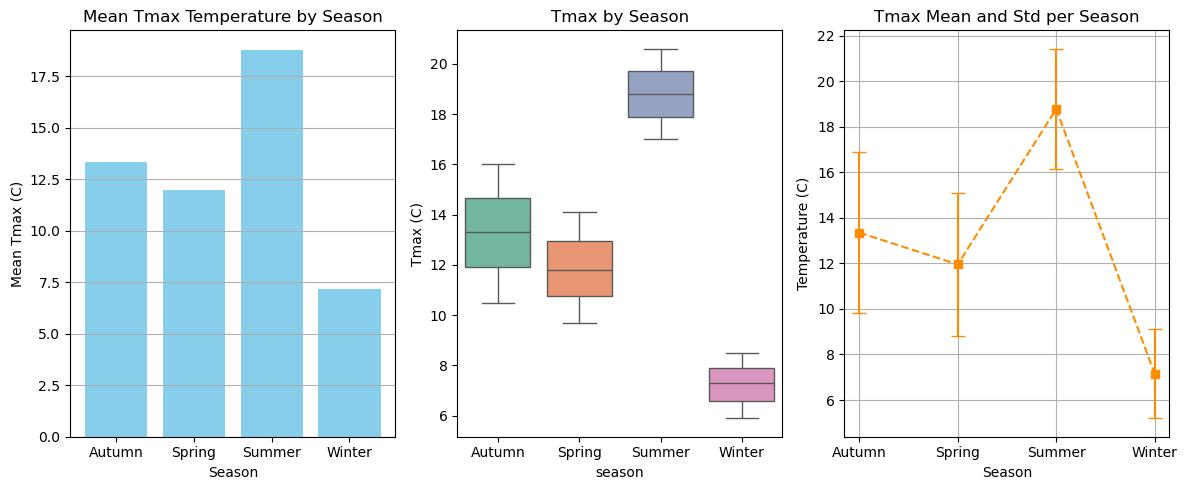

In [1424]:
# Extract values
seasons = tmax_stats_per_season.index
means = tmax_stats_per_season['mean']
stds = tmax_stats_per_season['std']

quartiles = tmax_stats_per_season[['25%', '50%', '75%']].copy()
quartiles['season'] = quartiles.index
df_quartiles_melted = quartiles.melt(id_vars='season', var_name='quartile', value_name='temp')
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))


axes[0].bar(seasons, means, color='skyblue')
axes[0].set_title("Mean Tmax Temperature by Season")
axes[0].set_ylabel("Mean Tmax (C)")
axes[0].set_xlabel("Season")
axes[0].grid(axis='y')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(ax=axes[1], x='season', y='temp', data=df_quartiles_melted, palette='Set2')
axes[1].set_title("Tmax by Season")
axes[1].set_ylabel("Tmax (C)")

axes[2].errorbar(seasons, means, yerr=stds, fmt='o', capsize=5, color='darkorange', marker='s', linestyle='--')
axes[2].set_title("Tmax Mean and Std per Season")
axes[2].set_ylabel("Temperature (C)")
axes[2].set_xlabel("Season")
axes[2].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


In [178]:
## Now I will get the average for each season and fill the missing data based on the season, firs let's see how many NAN do we have under each season
df['season'] = df['mm'].astype(int).apply(get_season) ## apply get season on the main dataframe (df)
df.isnull().groupby(df['season']).sum()

,yyyy,mm,tmax,tmin,af,rain,sun,station,is_closed,sunshine_sensor,has_estimated_values,season
season,,,,,,,,,,,,
Autumn,0,0,227,228,590,223,2300,0,0,0,0,0
Spring,0,0,229,213,574,213,2282,0,0,0,0,0
Summer,0,0,240,232,576,215,2292,0,0,0,0,0
Winter,0,0,232,229,587,222,2324,0,0,0,0,0


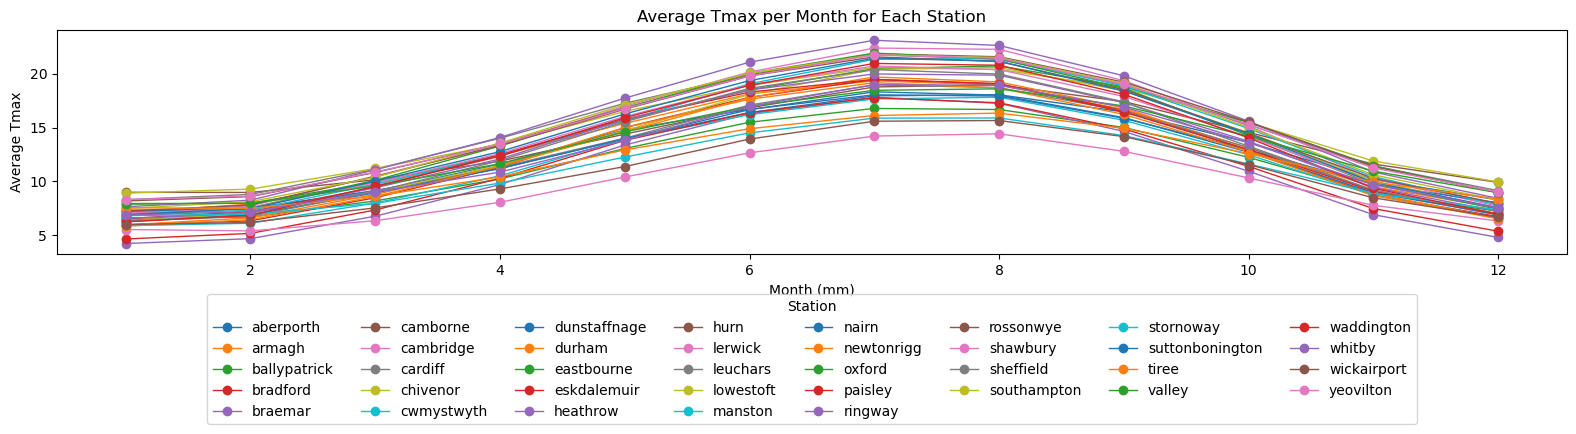

In [180]:
df['tmax'] = pd.to_numeric(df['tmax'], errors='coerce')
df['mm']   = pd.to_numeric(df['mm'],   errors='coerce')

mean_tmax = (df.groupby(['station', 'mm'])['tmax'].mean().reset_index())

pivot = mean_tmax.pivot(index='mm', columns='station', values='tmax')

fig, ax = plt.subplots(figsize=(16, 6))
pivot.plot(ax=ax, marker='o', linewidth=1)

ax.set_xlabel('Month (mm)')
ax.set_ylabel('Average Tmax')
ax.set_title('Average Tmax per Month for Each Station')

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=8,
    title='Station'
)

plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()


In [182]:
## Let's fill the null values with mean of tmax per month and station


df['tmax'] = df.groupby(['station', 'mm'])['tmax'] \
               .transform(lambda x: x.fillna(x.mean()))

# Quick check: any remaining NaNs?
remaining_nans = df['tmax'].isna().sum()
print(f"Remaining missing tmax values: {remaining_nans}")

Remaining missing tmax values: 0


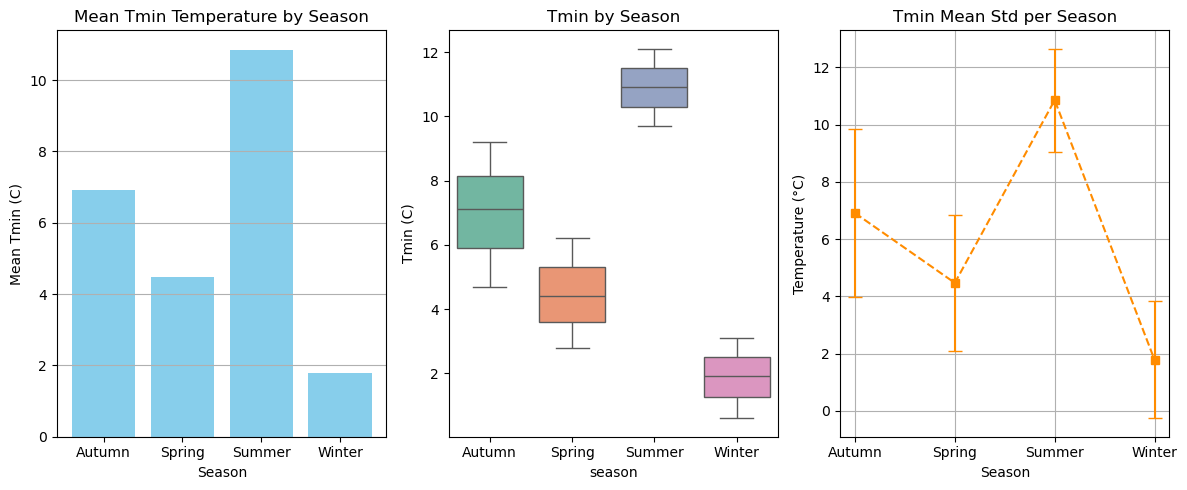

In [1426]:
### Let's do the exact the same with tmin


tmin_stats_per_season = df.groupby('season')['tmin'].describe()
tmin_stats_per_season



seasons = tmin_stats_per_season.index
means = tmin_stats_per_season['mean']
stds = tmin_stats_per_season['std']

# Prepare melted DataFrame for boxplot
quartiles = tmin_stats_per_season[['25%', '50%', '75%']].copy()
quartiles['season'] = quartiles.index
df_quartiles_melted = quartiles.melt(id_vars='season', var_name='quartile', value_name='temp')


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))

axes[0].bar(seasons, means, color='skyblue')
axes[0].set_title("Mean Tmin Temperature by Season")
axes[0].set_ylabel("Mean Tmin (C)")
axes[0].set_xlabel("Season")
axes[0].grid(axis='y')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(ax=axes[1], x='season', y='temp', data=df_quartiles_melted, palette='Set2')
axes[1].set_title("Tmin by Season")
axes[1].set_ylabel("Tmin (C)")

axes[2].errorbar(seasons, means, yerr=stds, fmt='o', capsize=5, color='darkorange', marker='s', linestyle='--')
axes[2].set_title("Tmin Mean Std per Season")
axes[2].set_ylabel("Temperature (°C)")
axes[2].set_xlabel("Season")
axes[2].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


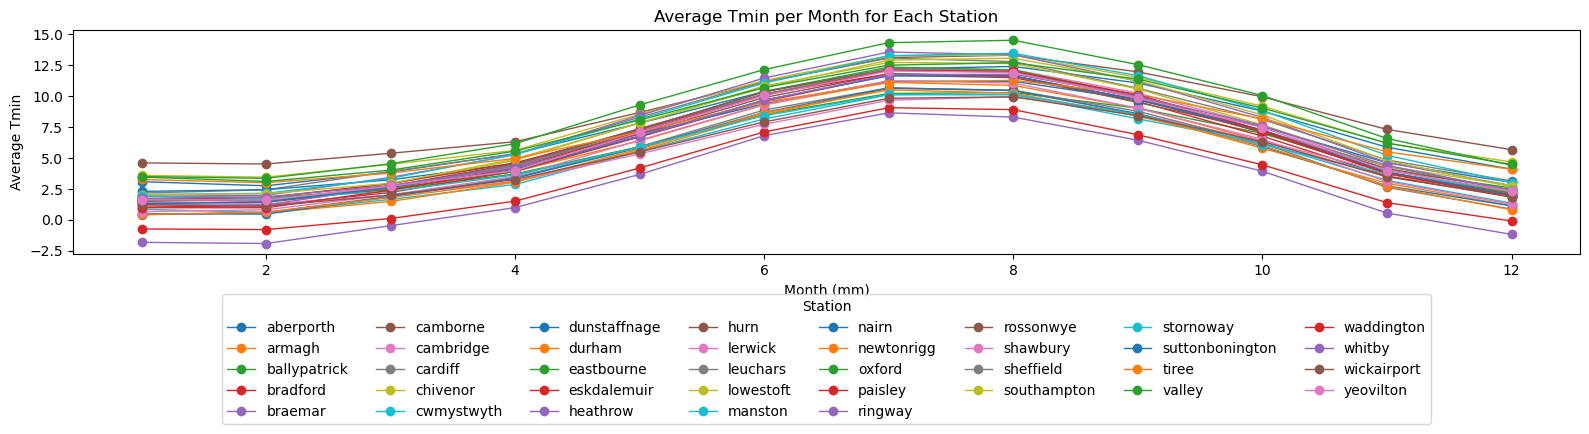

In [186]:
df['tmin'] = pd.to_numeric(df['tmin'], errors='coerce')
df['mm']   = pd.to_numeric(df['mm'],   errors='coerce')
mean_tmax = (df.groupby(['station', 'mm'])['tmin'].mean().reset_index())


pivot = mean_tmax.pivot(index='mm', columns='station', values='tmin')

fig, ax = plt.subplots(figsize=(16, 6))
pivot.plot(ax=ax, marker='o', linewidth=1)

ax.set_xlabel('Month (mm)')
ax.set_ylabel('Average Tmin')
ax.set_title('Average Tmin per Month for Each Station')

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=8,
    title='Station'
)

plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()


In [188]:
## Let's fill the null values with mean of tmax per month and station


df['tmin'] = df.groupby(['station', 'mm'])['tmin'] \
               .transform(lambda x: x.fillna(x.mean()))

# any remaining NaNs?
remaining_nans = df['tmin'].isna().sum()
print(f"Remaining missing tmax values: {remaining_nans}")

Remaining missing tmax values: 0


#### RAIN

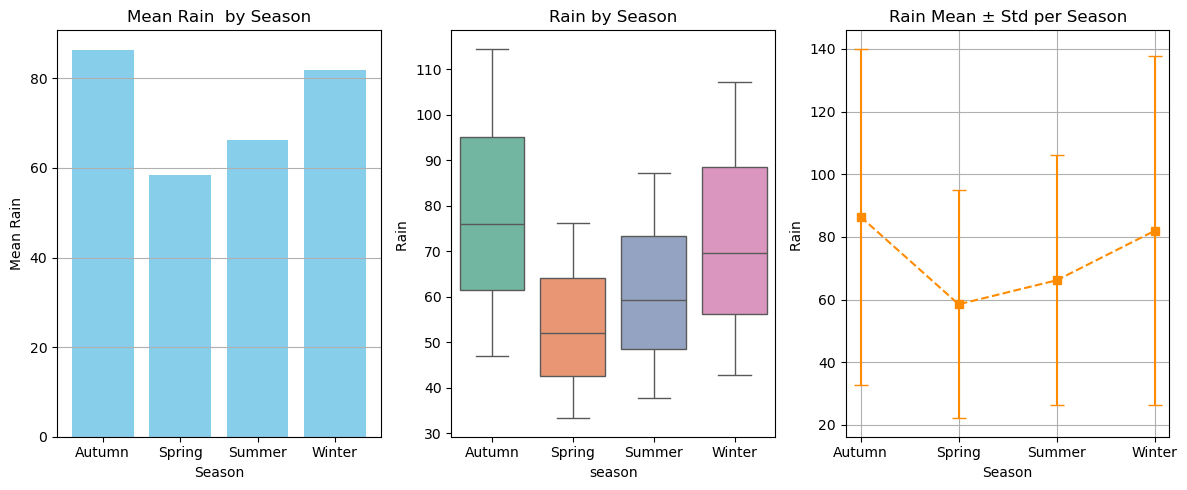

In [194]:
df_rain_not_missing=df[df['rain'].notnull()]
df_rain_not_missing['rain'] = pd.to_numeric(df_rain_not_missing['rain'])
rain_stats_per_season = df_rain_not_missing.groupby('season')['rain'].describe()
rain_stats_per_season

seasons = rain_stats_per_season.index
means = rain_stats_per_season['mean']
stds = rain_stats_per_season['std']

quartiles = rain_stats_per_season[['25%', '50%', '75%']].copy()
quartiles['season'] = quartiles.index
df_quartiles_melted = quartiles.melt(id_vars='season', var_name='quartile', value_name='temp')

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))

axes[0].bar(seasons, means, color='skyblue')
axes[0].set_title("Mean Rain  by Season")
axes[0].set_ylabel("Mean Rain")
axes[0].set_xlabel("Season")
axes[0].grid(axis='y')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(ax=axes[1], x='season', y='temp', data=df_quartiles_melted, palette='Set2')
axes[1].set_title("Rain by Season")
axes[1].set_ylabel("Rain ")

axes[2].errorbar(seasons, means, yerr=stds, fmt='o', capsize=5, color='darkorange', marker='s', linestyle='--')
axes[2].set_title("Rain Mean ± Std per Season")
axes[2].set_ylabel("Rain ")
axes[2].set_xlabel("Season")
axes[2].grid(True)

plt.tight_layout()
plt.show()


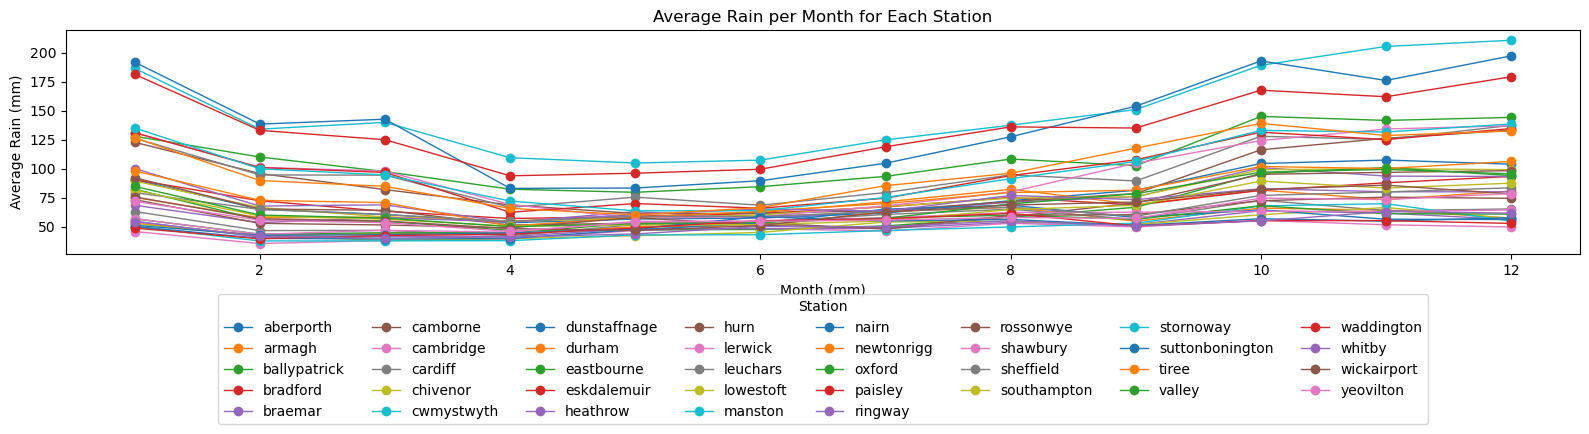

In [200]:

mean_rain = (df.groupby(['station', 'mm'])['rain'].mean().reset_index())

pivot = mean_rain.pivot(index='mm', columns='station', values='rain')

fig, ax = plt.subplots(figsize=(16, 6))
pivot.plot(ax=ax, marker='o', linewidth=1)

ax.set_xlabel('Month (mm)')
ax.set_ylabel('Average Rain (mm)')
ax.set_title('Average Rain per Month for Each Station')
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=8,
    title='Station'
)

plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()


In [204]:
#### From the above line chart, we can see the trends for all the station is almost the same over months, we will follow the same approcah to fill the null values for rain as well
df['rain'] = df.groupby(['station', 'mm'])['rain'] \
               .transform(lambda x: x.fillna(x.mean()))

# any remaining NaNs?
remaining_nans = df['rain'].isna().sum()
print(f"Remaining missing tmax values: {remaining_nans}")

Remaining missing tmax values: 0


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39705 entries, 1 to 39744
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   yyyy                  39705 non-null  float64
 1   mm                    39705 non-null  float64
 2   tmax                  39705 non-null  float64
 3   tmin                  39705 non-null  float64
 4   af                    37378 non-null  float64
 5   rain                  39705 non-null  float64
 6   sun                   30507 non-null  float64
 7   station               39705 non-null  object 
 8   is_closed             39705 non-null  object 
 9   sunshine_sensor       39705 non-null  object 
 10  has_estimated_values  39705 non-null  object 
 11  season                39705 non-null  object 
dtypes: float64(7), object(5)
memory usage: 3.9+ MB


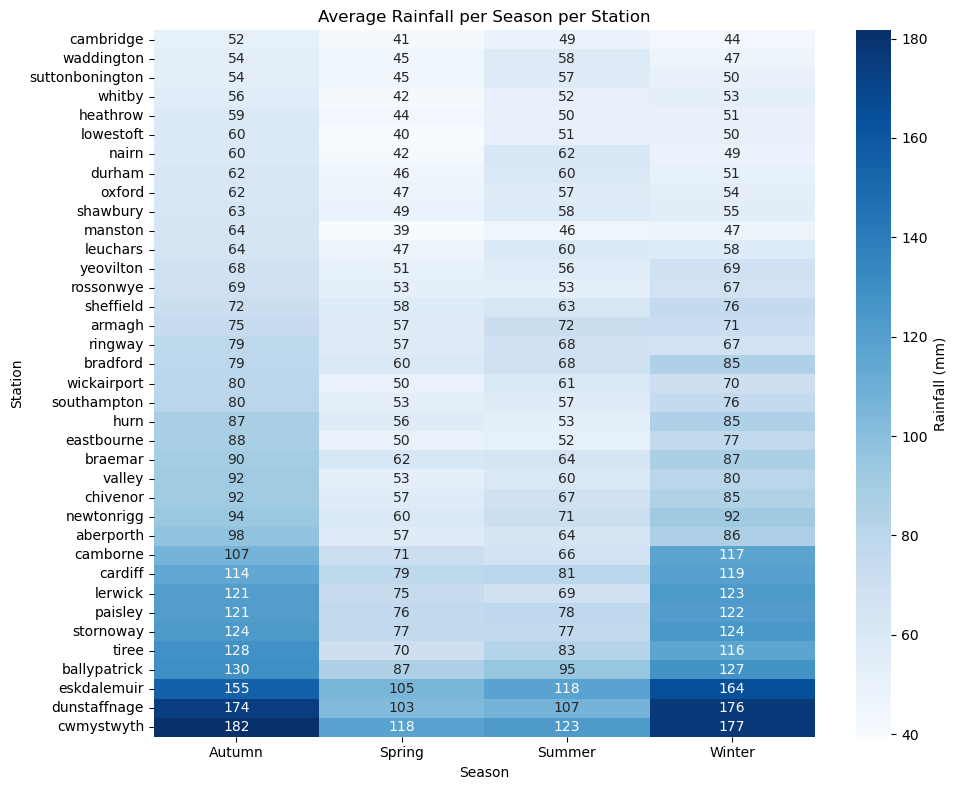

In [208]:
### I am intersted to see more insights on what stations have the most rain average as the above line chart shows only the pattern and the top rainy stations are not really clear
plt.figure(figsize=(10, 8))
sns.heatmap(df.groupby(['station', 'season'])['rain'].mean().unstack().sort_values(by='Autumn'), cmap='Blues', annot=True, fmt=".0f", cbar_kws={'label': 'Rainfall (mm)'})
plt.title("Average Rainfall per Season per Station")
plt.ylabel("Station")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

In [210]:
### We can see that stations like cwmystwyth and dunstafnage are having the most rainy days

#### Air forst

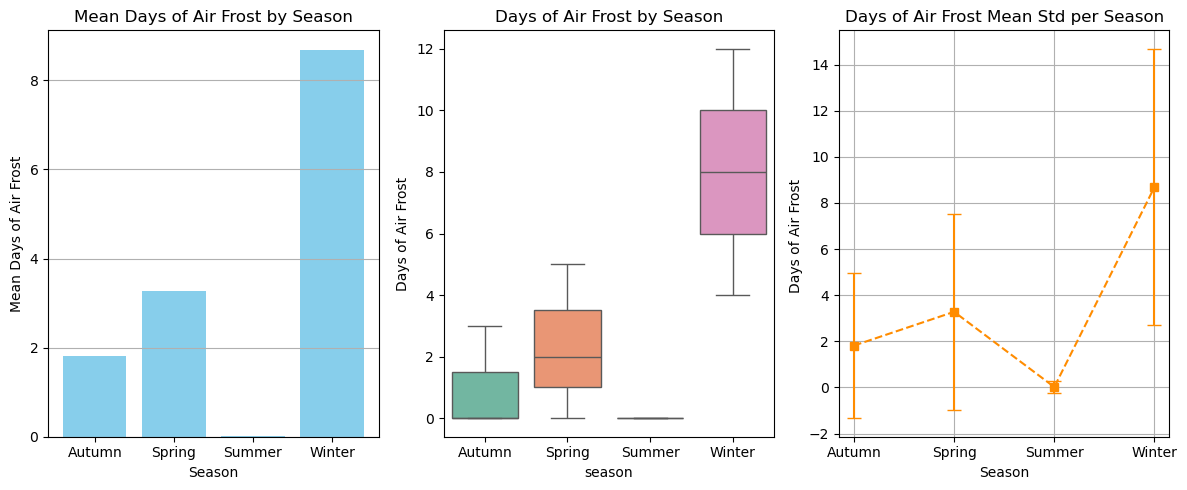

In [213]:
#df_af_not_missing=df[df['af'].notnull()]
#df_af_not_missing['af'] = pd.to_numeric(df_rain_not_missing['af'])
af_stats_per_season = df.groupby('season')['af'].describe()
af_stats_per_season



seasons = af_stats_per_season.index
means = af_stats_per_season['mean']
stds = af_stats_per_season['std']

quartiles = af_stats_per_season[['25%', '50%', '75%']].copy()
quartiles['season'] = quartiles.index
df_quartiles_melted = quartiles.melt(id_vars='season', var_name='quartile', value_name='af')


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
axes[0].bar(seasons, means, color='skyblue')
axes[0].set_title("Mean Days of Air Frost by Season")
axes[0].set_ylabel("Mean Days of Air Frost")
axes[0].set_xlabel("Season")
axes[0].grid(axis='y')
axes[0].tick_params(axis='x', rotation=0)
sns.boxplot(ax=axes[1], x='season', y='af', data=df_quartiles_melted, palette='Set2')
axes[1].set_title("Days of Air Frost by Season")
axes[1].set_ylabel("Days of Air Frost")
axes[2].errorbar(seasons, means, yerr=stds, fmt='o', capsize=5, color='darkorange', marker='s', linestyle='--')
axes[2].set_title("Days of Air Frost Mean Std per Season")
axes[2].set_ylabel("Days of Air Frost ")
axes[2].set_xlabel("Season")
axes[2].grid(True)
plt.tight_layout()
plt.show()


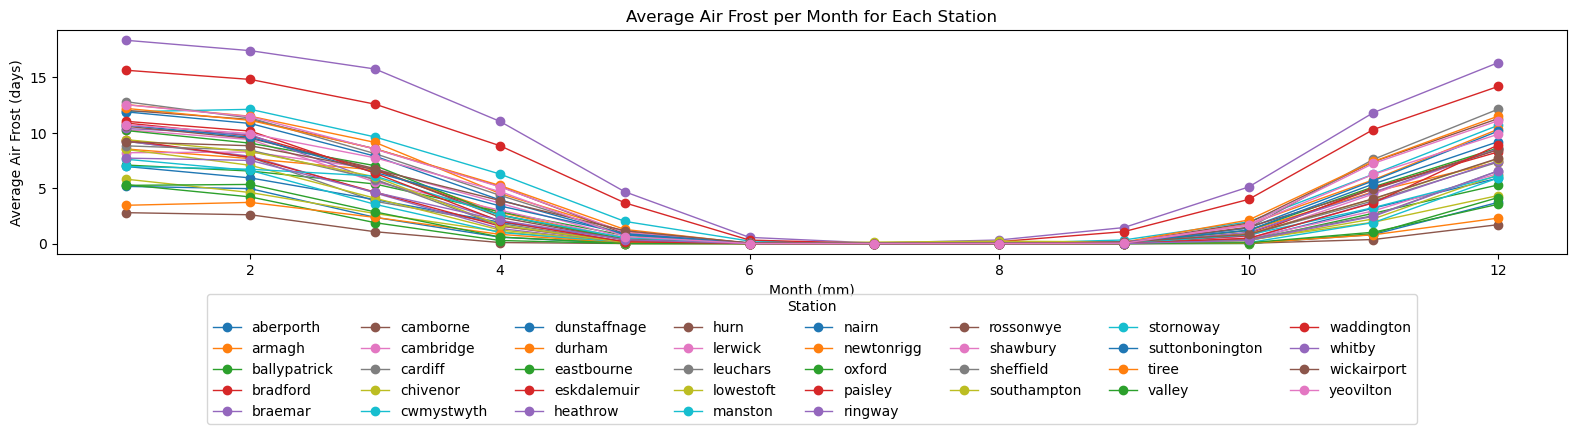

In [215]:
### The above charts shows us clearly that AF dosen't happen in summer where it's the highest in winter but is has high std which means that some stations have a higher average of AF days whoch measn they tend to be cloder
### let's do the same and see how tha pattern of AF looks like through the year per station
mean_af = (df.groupby(['station', 'mm'])['af'].mean().reset_index())

pivot = mean_af.pivot(index='mm', columns='station', values='af')

fig, ax = plt.subplots(figsize=(16, 6))
pivot.plot(ax=ax, marker='o', linewidth=1)

ax.set_xlabel('Month (mm)')
ax.set_ylabel('Average Air Frost (days)')
ax.set_title('Average Air Frost per Month for Each Station')
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=8,
    title='Station'
)

plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()


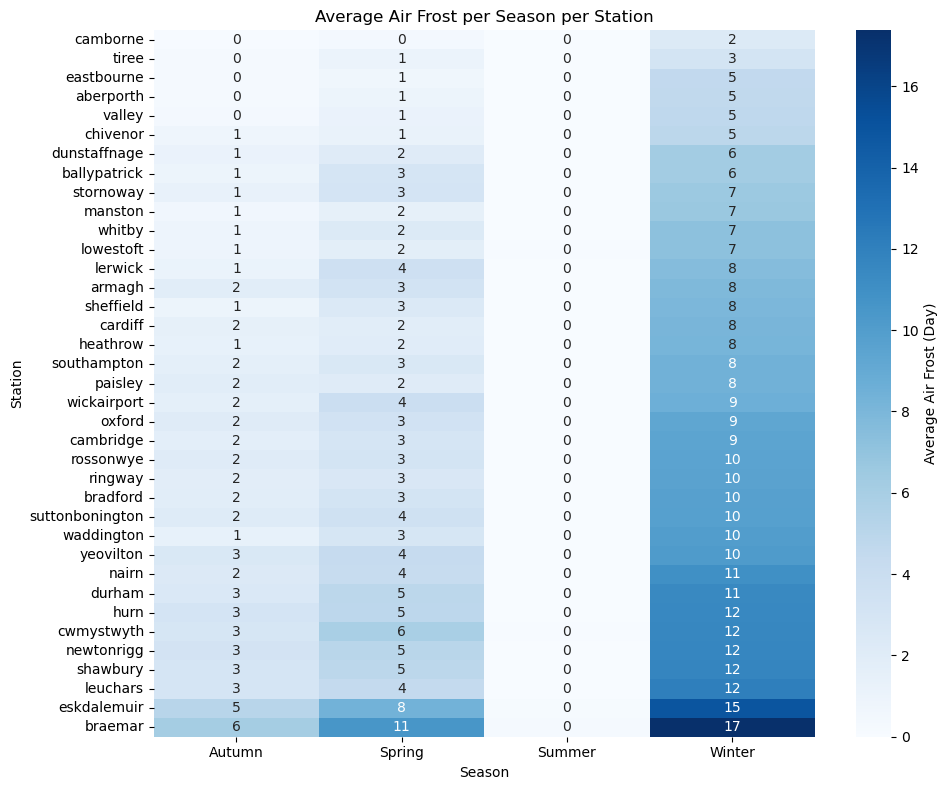

In [217]:
### Amaizng, the AF average is reallay high on Jan, Feb and March, decreasing slightly on April and then goes to almost zero from May to Sep then increases agin from Oct to December
## Let's dive deepr into each station per season and see who are the cooldest stations

## Here I am sorting the values on Winter so the heatmap shows proberly
plt.figure(figsize=(10, 8))
sns.heatmap(df.groupby(['station', 'season'])['af'].mean().unstack().sort_values(by='Winter'), cmap='Blues', annot=True, fmt=".0f", cbar_kws={'label': 'Average Air Frost (Day)'})
plt.title("Average Air Frost per Season per Station")
plt.ylabel("Station")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

In [219]:
### AF peackes in winter and stations like bramar, eskdalmuir are the cooldest ones, the second highest season is Spring which is new to me
### Will follow the same appraoch and fill the null values based on the average per station per month
#### From the above line chart, we can see the trends for all the station is almost the same over months, we will follow the same approcah to fill the null values for rain as well
df['af'] = df.groupby(['station', 'mm'])['af'] \
               .transform(lambda x: x.fillna(x.mean()))

#any remaining NaNs?
remaining_nans = df['af'].isna().sum()
print(f"Remaining missing tmax values: {remaining_nans}")

Remaining missing tmax values: 0


### Sun

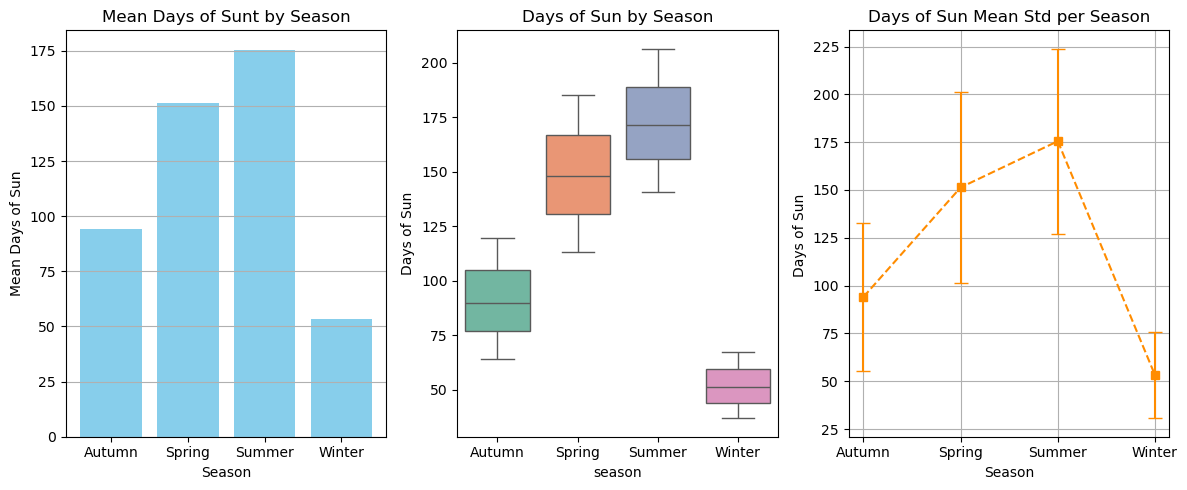

In [224]:
#df_af_not_missing=df[df['af'].notnull()]
#df_af_not_missing['af'] = pd.to_numeric(df_rain_not_missing['af'])
af_stats_per_season = df.groupby('season')['sun'].describe()
af_stats_per_season

seasons = af_stats_per_season.index
means = af_stats_per_season['mean']
stds = af_stats_per_season['std']

quartiles = af_stats_per_season[['25%', '50%', '75%']].copy()
quartiles['season'] = quartiles.index
df_quartiles_melted = quartiles.melt(id_vars='season', var_name='quartile', value_name='sun')

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))

axes[0].bar(seasons, means, color='skyblue')
axes[0].set_title("Mean Days of Sunt by Season")
axes[0].set_ylabel("Mean Days of Sun")
axes[0].set_xlabel("Season")
axes[0].grid(axis='y')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(ax=axes[1], x='season', y='sun', data=df_quartiles_melted, palette='Set2')
axes[1].set_title("Days of Sun by Season")
axes[1].set_ylabel("Days of Sun")
axes[2].errorbar(seasons, means, yerr=stds, fmt='o', capsize=5, color='darkorange', marker='s', linestyle='--')
axes[2].set_title("Days of Sun Mean Std per Season")
axes[2].set_ylabel("Days of Sun ")
axes[2].set_xlabel("Season")
axes[2].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


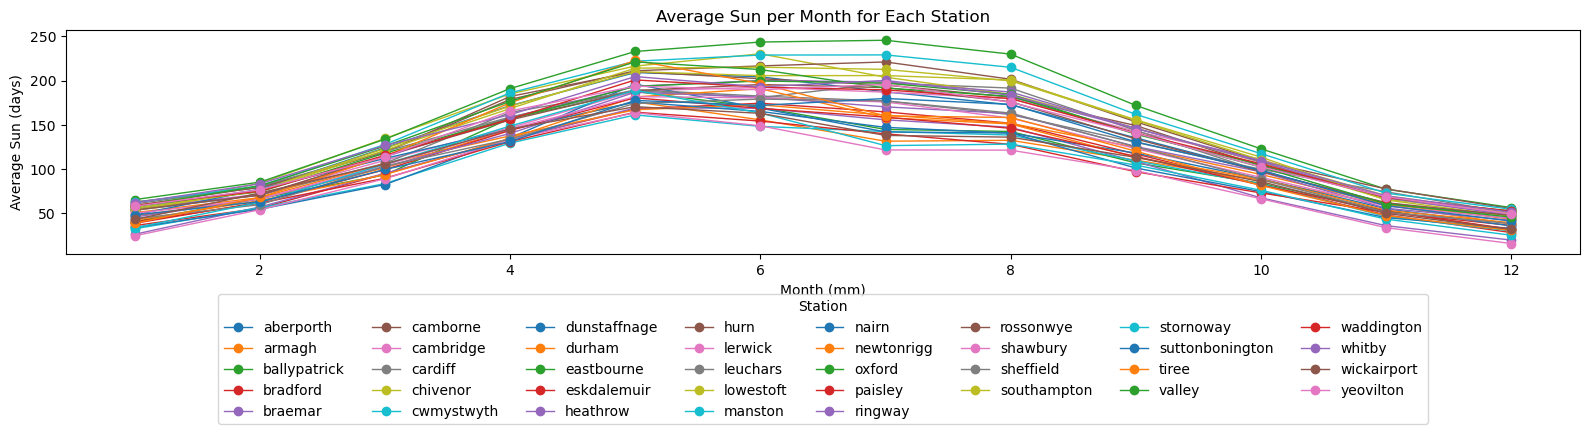

In [230]:
### Opposite to AF, sun time is really high during summer season, really low during Winter, the std is a bit high during summer which also indicates that some stations have higher mean of sunny days, will dive a bit and see the pattern and which station are having higher sunny days
### Spring comes in the second postioinin terms of hgiher sunny days, that helps us ti say that Spring is similar to summer and winter is closer ro Autmumn
### The above charts shows us clearly that AF dosen't happen in summer where it's the highest in winter but is has high std which means that some stations have a higher average of AF days whoch measn they tend to be cloder
### let's do the same and see how tha pattern of AF looks like through the year per station
mean_sun = (df.groupby(['station', 'mm'])['sun'].mean().reset_index())

pivot = mean_sun.pivot(index='mm', columns='station', values='sun')

fig, ax = plt.subplots(figsize=(16, 6))
pivot.plot(ax=ax, marker='o', linewidth=1)

ax.set_xlabel('Month (mm)')
ax.set_ylabel('Average Sun (days)')
ax.set_title('Average Sun per Month for Each Station')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),  ncol=8, title='Station')

plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()


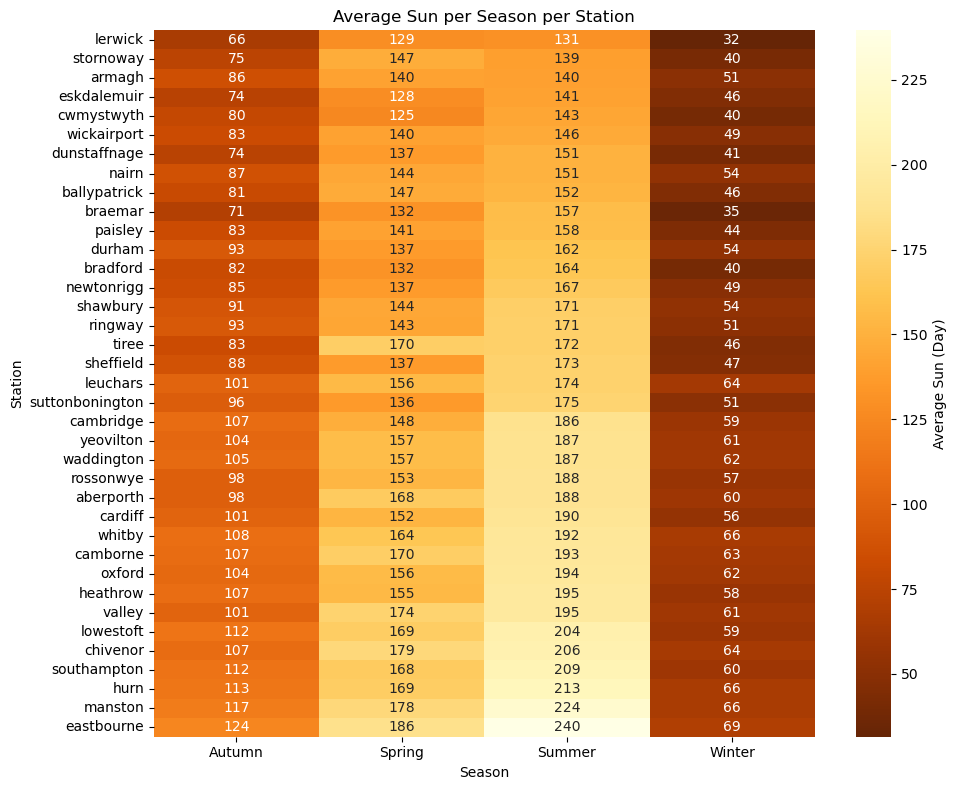

In [242]:
### Amaizng, the AF average is reallay high on Jan, Feb and March, decreasing slightly on April and then goes to almost zero from May to Sep then increases agin from Oct to December
## Let's dive deepr into each station per season and see who are the cooldest stations

## Here I am sorting the values on Winter so the heatmap shows proberly
plt.figure(figsize=(10, 8))
sns.heatmap(df.groupby(['station', 'season'])['sun'].mean().unstack().sort_values(by='Summer'), cmap='YlOrBr_r', annot=True, fmt=".0f", cbar_kws={'label': 'Average Sun (Day)'})
plt.title("Average Sun per Season per Station")
plt.ylabel("Station")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

In [244]:
df['sun'] = df.groupby(['station', 'mm'])['sun'].transform(lambda x: x.fillna(x.mean()))

# any remaining NaNs?
remaining_nans = df['sun'].isna().sum()
print(f"Remaining missing sun values: {remaining_nans}")

Remaining missing sun values: 0


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39705 entries, 1 to 39744
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   yyyy                  39705 non-null  float64
 1   mm                    39705 non-null  float64
 2   tmax                  39705 non-null  float64
 3   tmin                  39705 non-null  float64
 4   af                    39705 non-null  float64
 5   rain                  39705 non-null  float64
 6   sun                   39705 non-null  float64
 7   station               39705 non-null  object 
 8   is_closed             39705 non-null  object 
 9   sunshine_sensor       39705 non-null  object 
 10  has_estimated_values  39705 non-null  object 
 11  season                39705 non-null  object 
dtypes: float64(7), object(5)
memory usage: 3.9+ MB


### Featuer Engineering and Selection

#### Why not the most recent ? why not all the observations ? why the average ?
I can't pick all the observation as we will have imbalanced data issue since not all the stations been operating  through all the years and this will cause biase in the clustering if a station is having more observations than others so this option is dropped.

Why not the most recent ? I don't think it reflects the whole story and readings throughout the years, what if there was a peak during that reading? what if there was sensor issue ? some of the station like Souothampton, RingWay, Cwmystwyth don't have recent readings (last reading was on 2000) which is 25 years older and consediring the climate change, this won;t be reliable so i will go with the mean of each station per season for each


In [280]:
### Let's intreduoce new feauters by breaking the columns down by deason so we can maintaiin the difference in each season
seasonal_means = (
    df
    .groupby(['station', 'season'])[['tmax', 'tmin', 'af', 'rain', 'sun']]
    .mean()
    .round(2)
    .reset_index()
)

# Pivot to wide format: columns like tmax_Summer, tmin_Winter, etc.
df_seasons = seasonal_means.pivot(index='station', columns='season')
df_seasons.columns = [f'{var}_{season}' for var, season in df_seasons.columns]
df_seasons = df_seasons.reset_index().sort_values('station')
df_seasons

,station,tmax_Autumn,tmax_Spring,tmax_Summer,tmax_Winter,tmin_Autumn,tmin_Spring,tmin_Summer,tmin_Winter,af_Autumn,...,af_Summer,af_Winter,rain_Autumn,rain_Spring,rain_Summer,rain_Winter,sun_Autumn,sun_Spring,sun_Summer,sun_Winter
0,aberporth,13.42,11.43,17.45,7.69,8.55,5.65,11.63,3.30,0.27,...,0.00,4.62,97.74,56.79,63.81,86.39,97.81,168.04,188.00,60.17
1,armagh,13.10,12.50,18.79,7.52,6.29,4.24,10.40,1.87,1.96,...,0.00,7.86,74.65,57.39,71.89,71.15,85.63,140.49,139.81,50.44
2,ballypatrick,12.06,10.48,16.32,6.85,6.65,4.00,9.65,2.08,1.04,...,0.01,6.31,129.74,86.50,95.40,127.40,81.24,145.79,152.16,46.22
3,bradford,12.73,11.59,18.77,6.36,6.60,4.26,10.90,1.32,1.95,...,0.00,9.72,79.21,59.65,67.85,85.32,82.50,132.05,163.53,40.07
4,braemar,10.84,9.94,17.11,4.59,3.62,1.38,7.90,-1.64,6.12,...,0.31,17.38,90.06,61.85,63.90,86.98,70.70,132.36,157.17,34.48
5,camborne,14.53,12.13,18.18,9.30,9.71,6.76,12.50,4.91,0.13,...,0.00,2.36,107.00,70.72,65.66,117.22,107.00,169.97,192.70,63.27
6,cambridge,14.91,13.59,21.59,7.50,7.29,4.72,11.46,1.64,1.71,...,0.00,9.44,52.24,41.28,49.09,43.60,106.85,148.02,186.27,58.63
7,cardiff,15.22,14.11,20.99,8.76,7.84,5.81,12.30,2.57,1.56,...,0.00,8.12,114.14,78.90,80.81,119.38,100.98,152.63,189.74,55.87
8,chivenor,15.34,13.71,19.95,9.39,8.94,6.19,12.58,3.89,0.76,...,0.00,4.92,91.61,56.71,67.33,84.89,106.52,178.35,206.07,64.36
9,cwmystwyth,12.32,10.82,17.22,6.22,5.85,3.34,9.44,0.93,2.83,...,0.07,11.56,181.65,118.12,123.21,177.13,79.78,124.64,142.98,39.60


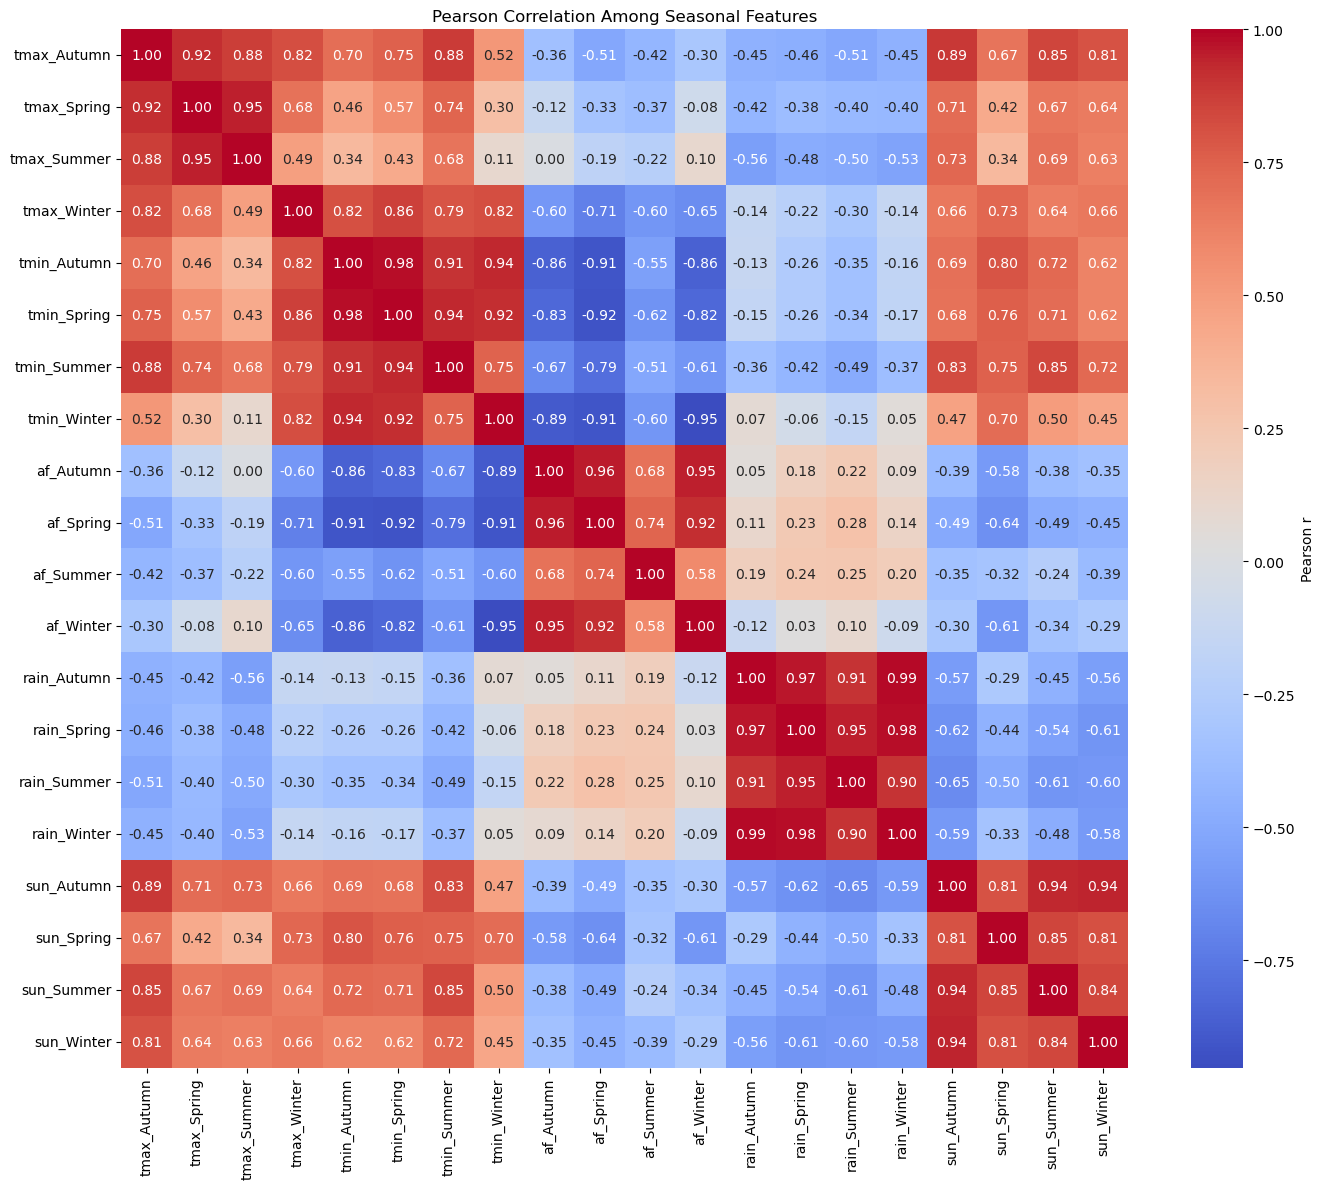

In [286]:
seasonal_means = (
    df
    .groupby(['station', 'season'])[['tmax', 'tmin', 'af', 'rain', 'sun']]
    .mean()
    .reset_index()
)

df_seasons = seasonal_means.pivot(index='station', columns='season')
df_seasons.columns = [f"{var}_{season}" for var, season in df_seasons.columns]
df_seasons = df_seasons.reset_index()

corr = df_seasons.drop(columns='station').corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={'label': 'Pearson r'}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Pearson Correlation Among Seasonal Features')
plt.tight_layout()
plt.show()

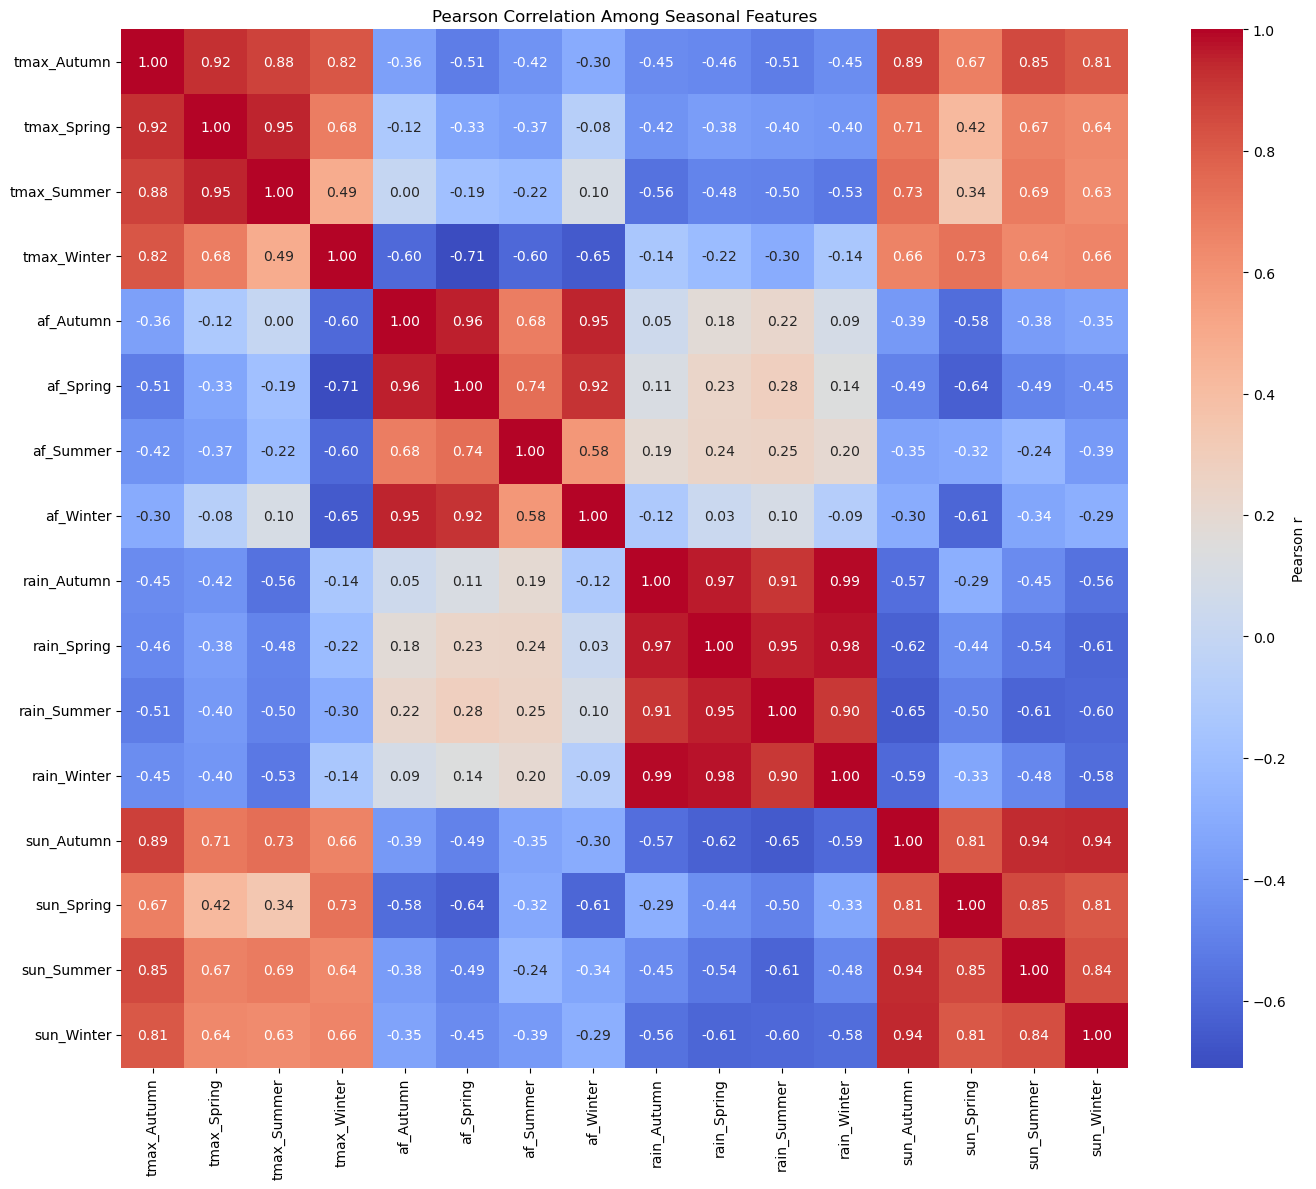

In [296]:



## ['station', 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
#       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
#       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
#       'sun_Summer', 'sun_Winter']



df_seasons = seasonal_means.pivot(index='station', columns='season')
df_seasons.columns = [f"{var}_{season}" for var, season in df_seasons.columns]
df_seasons = df_seasons.reset_index()
corr = df_seasons.drop(columns='station').corr()
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={'label': 'Pearson r'}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Pearson Correlation Among Seasonal Features')
plt.tight_layout()
plt.show()

##### When we examine how summer sunshine relates to everything else, a clear story emerges: stations that bask in more hours of sunshine each June-July-August also tend to record higher maximum and minimum temperatures in every season (with Pearson r values climbing from about 0.63 in winter to roughly 0.85 in autumn), and they almost invariably see fewer frost days and less rainfall (ranging from –0.24 against summer frosts down to –0.61 versus winter rain). At the same time, summer sunshine is virtually interchangeable with the sunshine totals of spring, autumn or winter – correlations exceed 0.85 across the board – so it alone carries the full signal of seasonal light variance. By keeping only the sun_Summer feature, we capture both the warm-season brightness and its strong ties to temperature and moisture extremes without bloating our model with nearly identical, collinear predictors. This single axis therefore maximizes the geographic and climatic contrasts we want for clustering while shedding redundant dimensions.

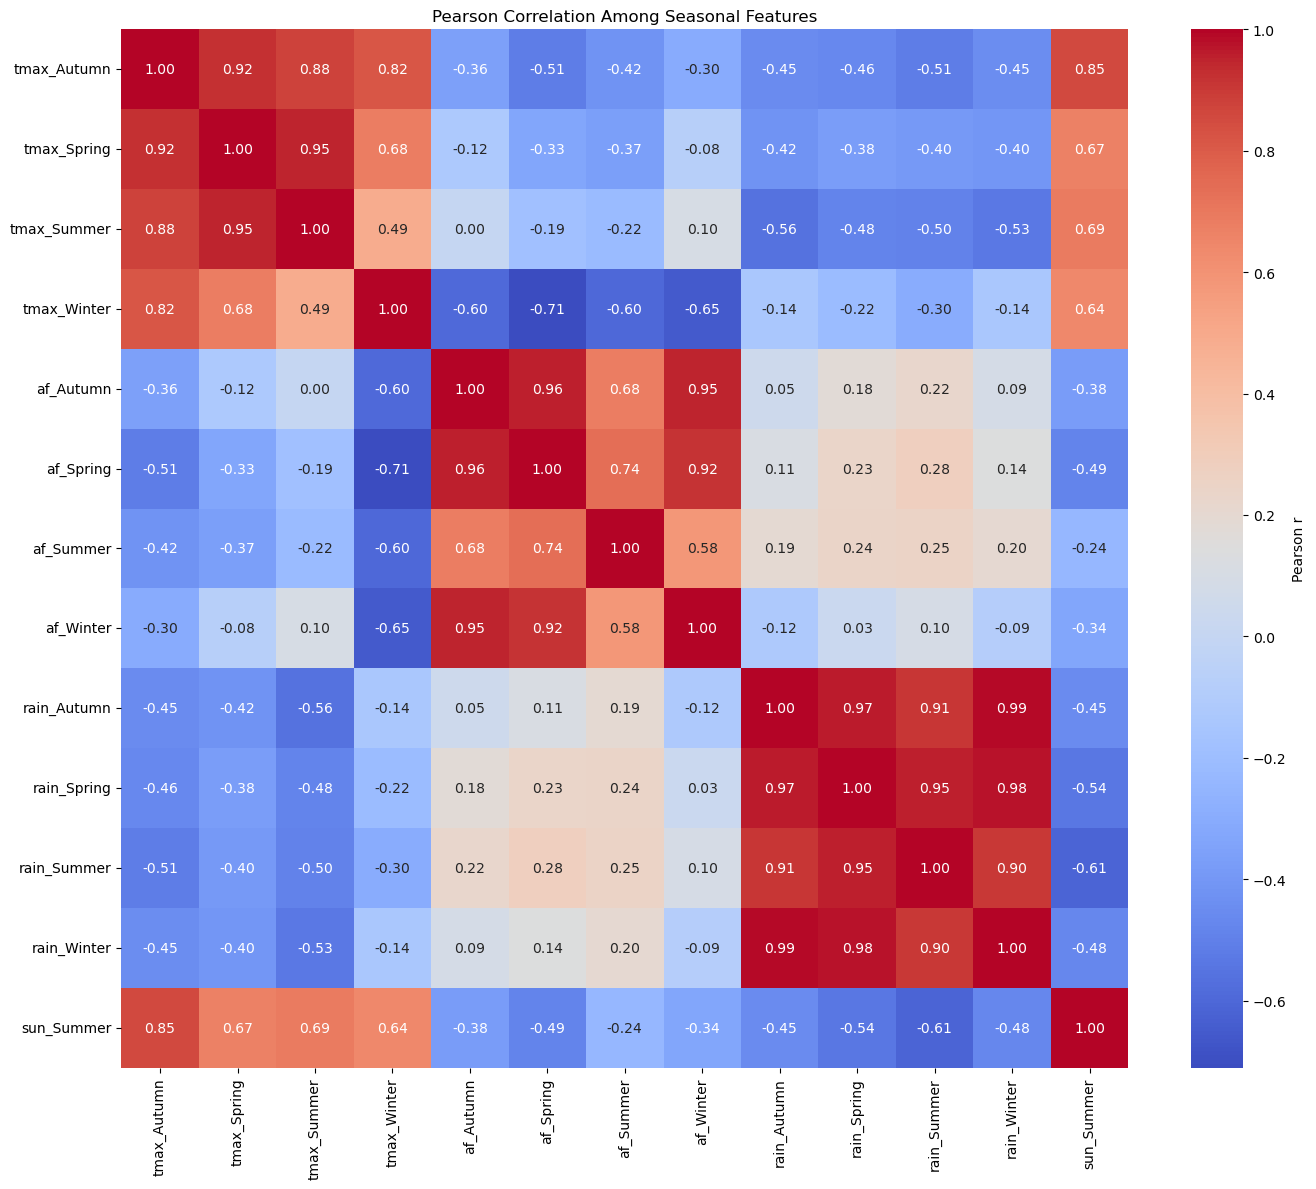

In [315]:



## [ 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
#       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
#       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
#       'sun_Summer', 'sun_Winter']

columns=[ 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
       'rain_Spring', 'rain_Summer', 'rain_Winter',
       'sun_Summer']

# Pivot to wide format: each feature-season becomes a column
df_seasons = seasonal_means.pivot(index='station', columns='season')
df_seasons.columns = [f"{var}_{season}" for var, season in df_seasons.columns]
df_seasons = df_seasons.reset_index()


df_seasons_1=df_seasons[columns]
# Compute Pearson correlation matrix
corr = df_seasons_1.corr()

# Plot annotated heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={'label': 'Pearson r'}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Pearson Correlation Among Seasonal Features')
plt.tight_layout()
plt.show()

In [300]:
### WE can see that rain season have almose the same correlation values with other featuers, summer was having the hier values so we can chose as it will help us to distingue the clusters further

Index(['station', 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
       'sun_Summer', 'sun_Winter'],
      dtype='object')

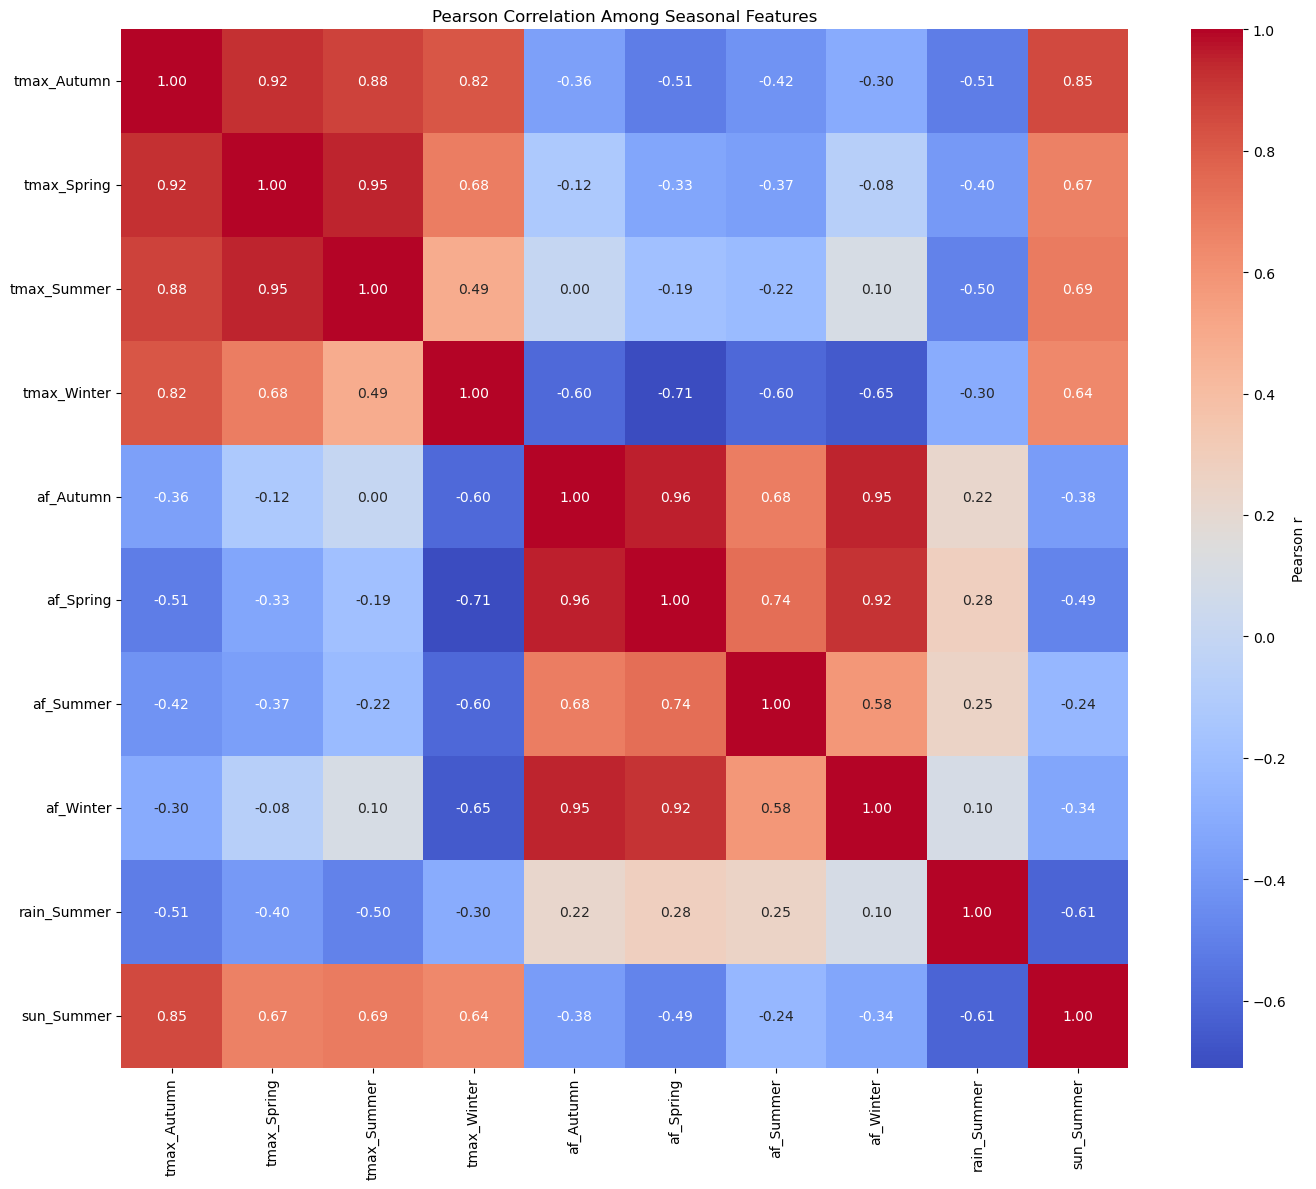

In [317]:



## [ 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
#       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
#       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
#       'sun_Summer', 'sun_Winter']

columns=[ 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Summer',
       'sun_Summer']

# Pivot to wide format: each feature-season becomes a column
df_seasons = seasonal_means.pivot(index='station', columns='season')
df_seasons.columns = [f"{var}_{season}" for var, season in df_seasons.columns]
df_seasons = df_seasons.reset_index()


df_seasons_1=df_seasons[columns]
# Compute Pearson correlation matrix
corr = df_seasons_1.corr()

# Plot annotated heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={'label': 'Pearson r'}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Pearson Correlation Among Seasonal Features')
plt.tight_layout()
plt.show()

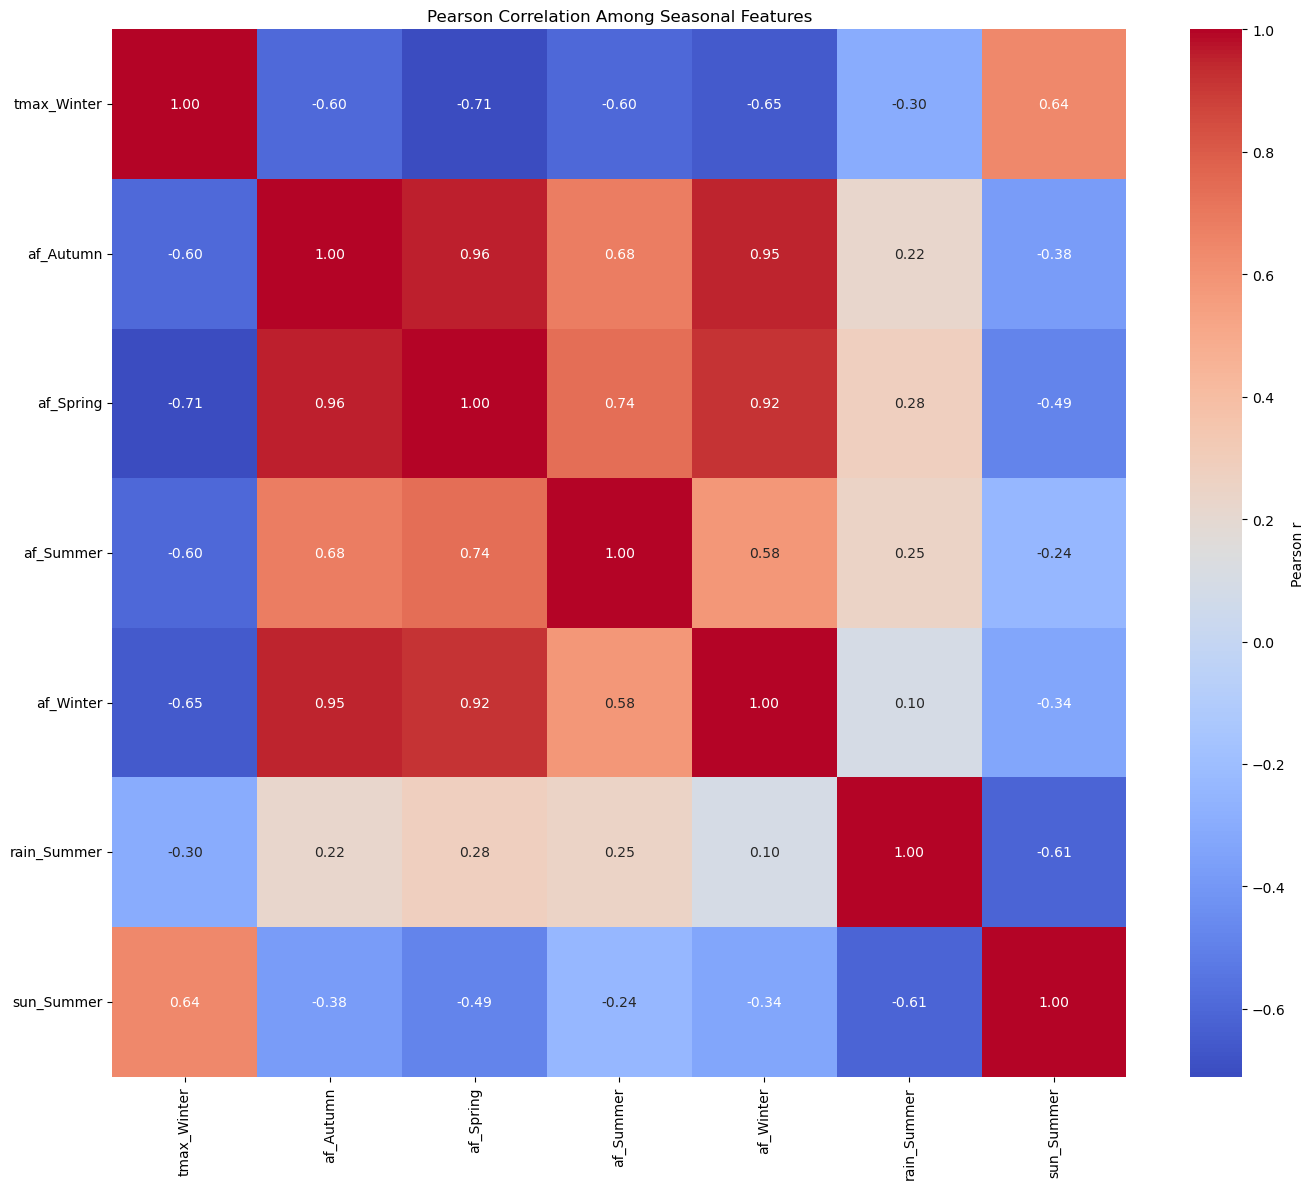

In [319]:



## [ 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
#       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
#       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
#       'sun_Summer', 'sun_Winter']

columns=['tmax_Winter',
       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Summer',
       'sun_Summer']
df_seasons = seasonal_means.pivot(index='station', columns='season')
df_seasons.columns = [f"{var}_{season}" for var, season in df_seasons.columns]
df_seasons = df_seasons.reset_index()


df_seasons_1=df_seasons[columns]
corr = df_seasons_1.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={'label': 'Pearson r'}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Pearson Correlation Among Seasonal Features')
plt.tight_layout()
plt.show()

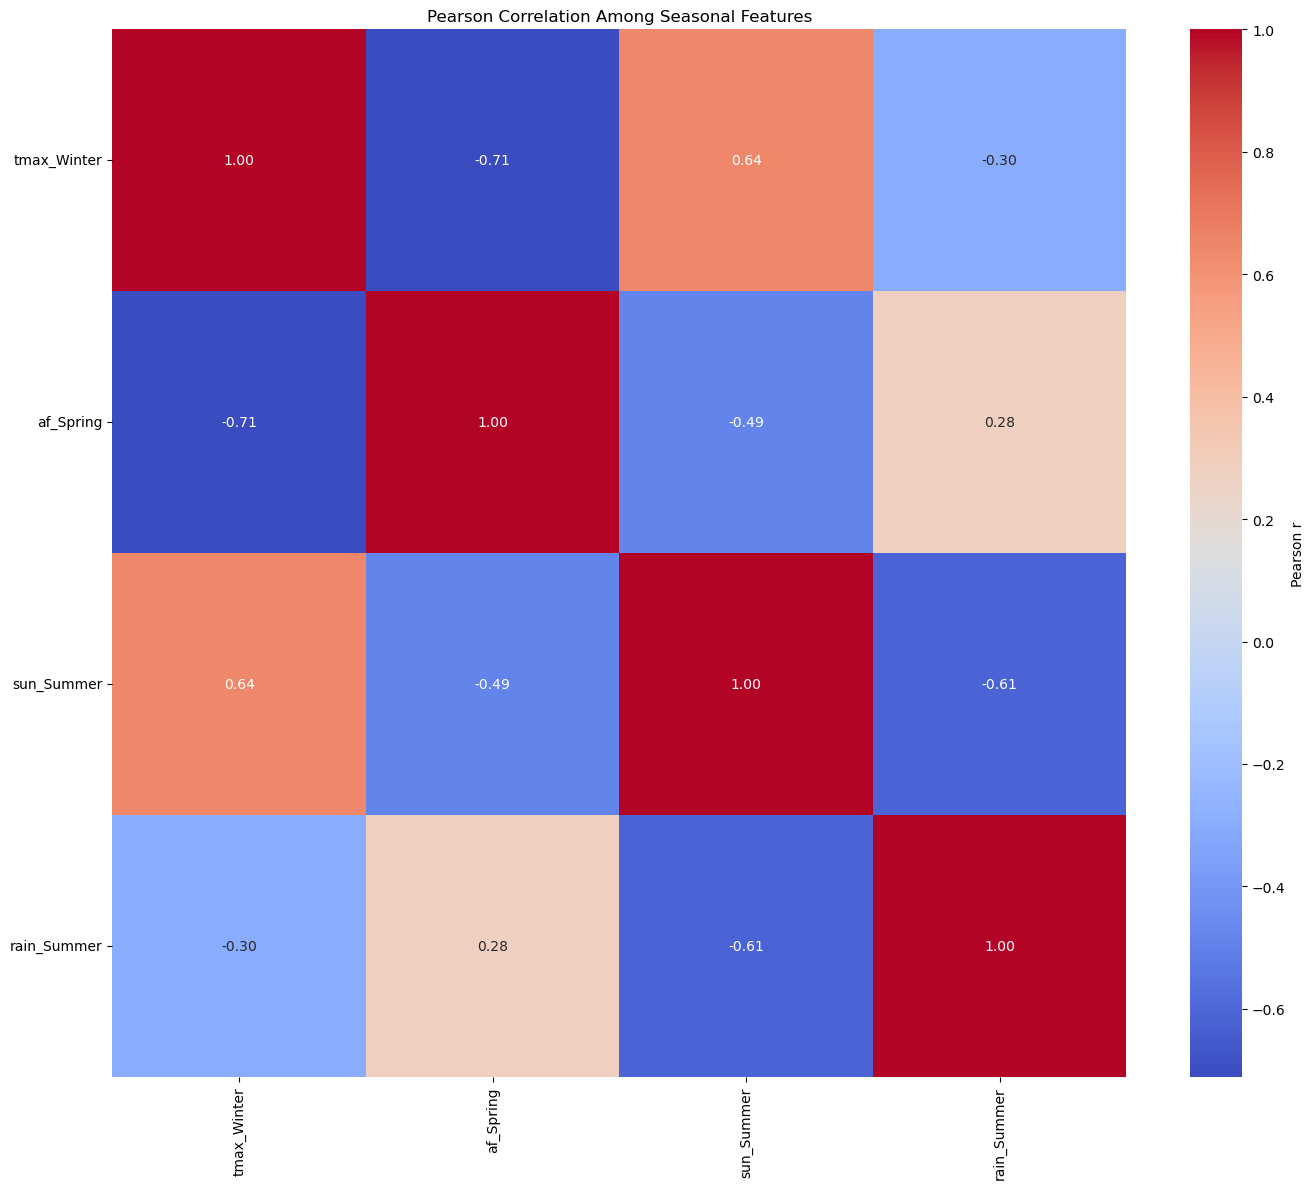

In [341]:



## [ 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
#       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
#       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
#       'sun_Summer', 'sun_Winter']

columns=['tmax_Winter','af_Spring',
       'sun_Summer','rain_Summer']
df_seasons = seasonal_means.pivot(index='station', columns='season')
df_seasons.columns = [f"{var}_{season}" for var, season in df_seasons.columns]
df_seasons = df_seasons.reset_index()


df_seasons_1=df_seasons[columns]
corr = df_seasons_1.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={'label': 'Pearson r'}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Pearson Correlation Among Seasonal Features')
plt.tight_layout()
plt.show()

In [323]:
df_seasons_1

,tmax_Winter,af_Spring,sun_Summer,rain_Summer
0,7.686641,0.984085,187.995102,63.813889
1,7.520378,3.279425,139.811911,71.886822
2,6.851317,3.001578,152.163008,95.403418
3,6.364463,3.189028,163.531339,67.852924
4,4.586500,10.516119,157.167858,63.902728
5,9.300000,0.388489,192.701449,65.656522
6,7.498000,3.005025,186.266415,49.090104
7,8.755556,1.936620,189.744444,80.806383
8,9.388323,1.270116,206.069123,67.331079
9,6.222931,5.962839,142.981094,123.206000


# K-Means

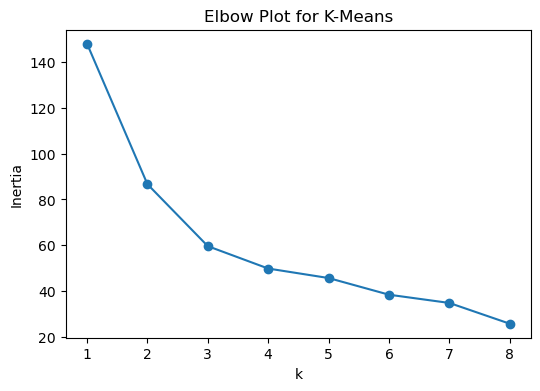

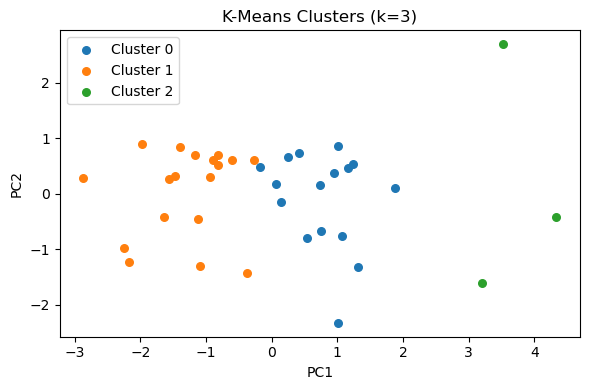

Index(['tmax_Winter', 'af_Spring', 'sun_Summer', 'rain_Summer'], dtype='object')


array([[-0.53709841, -0.38708866],
       [ 0.49548143,  0.48469023],
       [-0.54432852,  0.26415894],
       [ 0.41198292, -0.73855116]])

In [1422]:

scaler = StandardScaler()
X = scaler.fit_transform(df_seasons_1)
inertia = []
ks = range(1,9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=0).fit(X)
    inertia.append(km.inertia_)
plt.figure(figsize=(6,4))
plt.plot(ks, inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Plot for K-Means')
plt.show()
k = 3
km = KMeans(n_clusters=k, random_state=0).fit(X)
labels = km.labels_
pca = PCA(n_components=2)
proj = pca.fit_transform(X)
plt.figure(figsize=(6,4))
for cluster in range(k):
    plt.scatter(proj[labels==cluster,0], proj[labels==cluster,1], label=f'Cluster {cluster}', s=30)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters (k=3)')
plt.legend()
plt.tight_layout()
plt.show()
print(df_seasons_1.columns)
pca.components_.T

In [1113]:
## The clusters seem fine, they are well sperated to some extent, no overlap and all the point are grouped in a good way, now let's interp[ret the clusters and see how valid they are
df_seasons['cluster']=labels

In [1115]:
## the distibution of the cluster is imbalanced, only three observations under cluster 2 where cluster 0 has 16 and 1 has the most, 18
df_seasons['cluster'].value_counts()

cluster
1    18
0    16
2     3
Name: count, dtype: int64

In [1255]:
df_seasons.columns

Index(['station', 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
       'sun_Summer', 'sun_Winter', 'cluster', 'latitude', 'region',
       'area_name', 'Area names'],
      dtype='object')

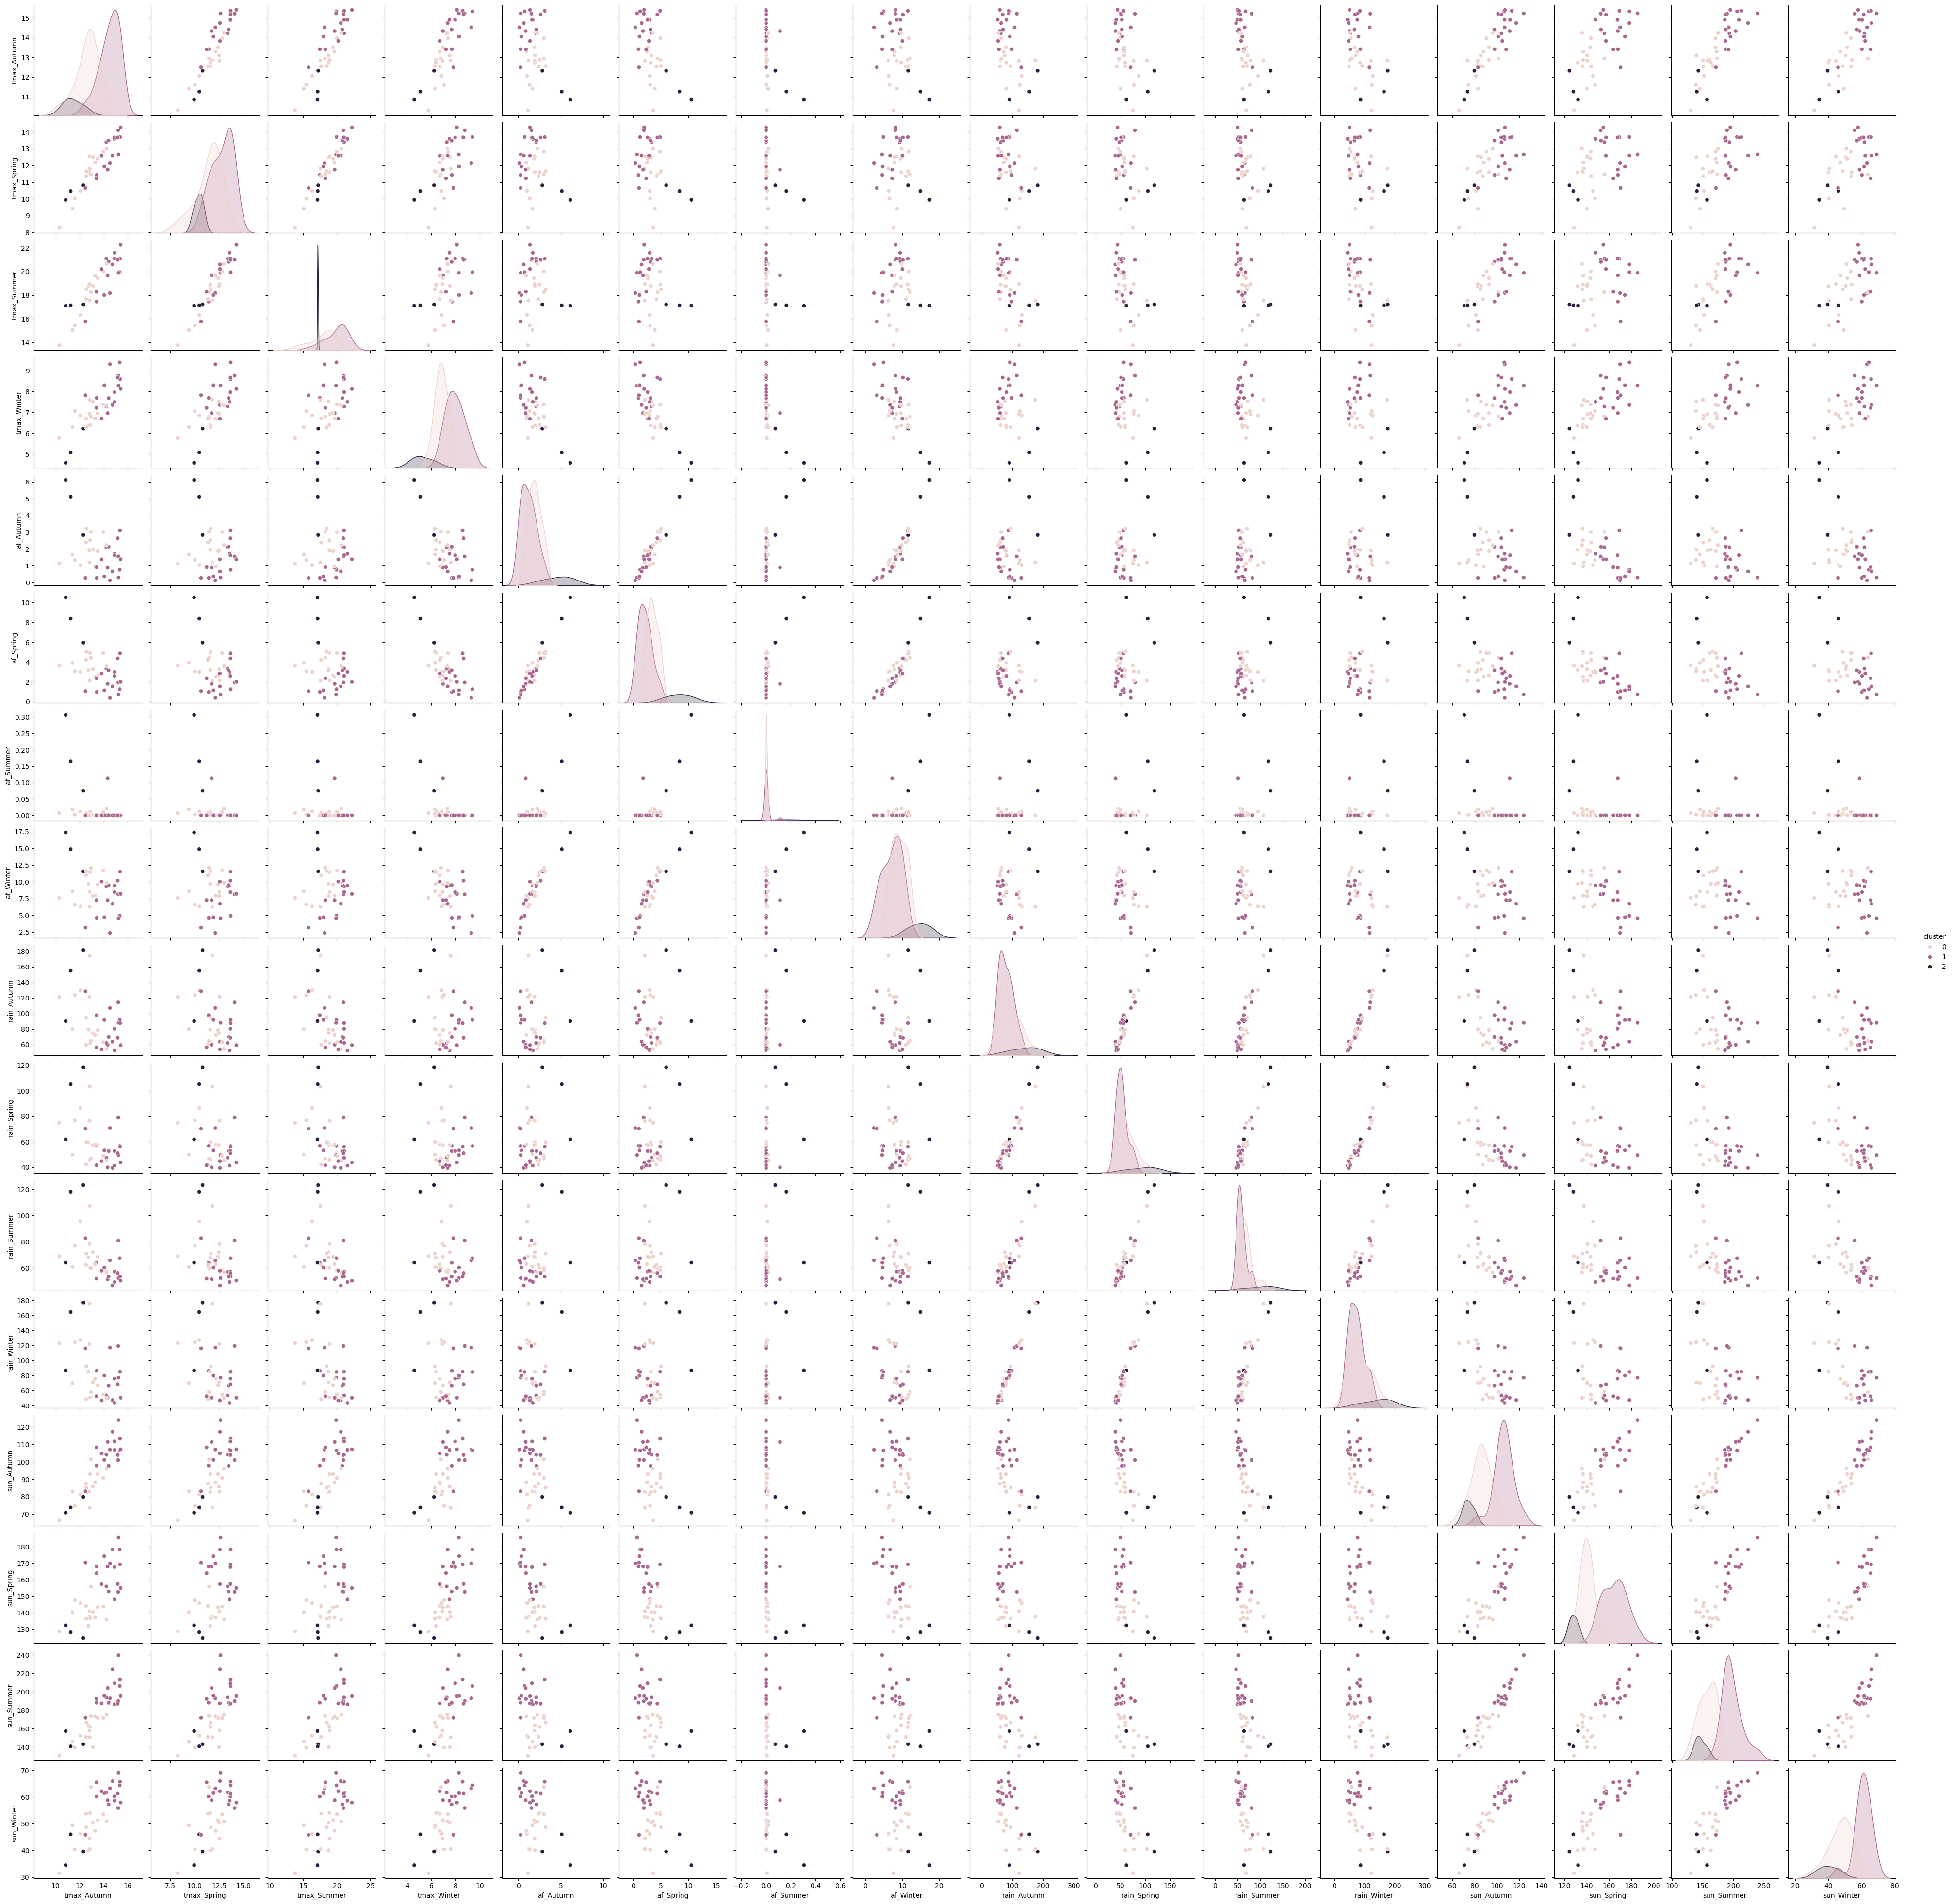

In [1265]:
columns=['station', 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
       'sun_Summer', 'sun_Winter', 'cluster',]

df_seasons_plot=df_seasons[columns]
sns.pairplot(df_seasons_plot, hue='cluster')

In [1117]:
### let get the mean of each cluster for each value and see
df_seasons.groupby('cluster')[[ 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
       'sun_Summer', 'sun_Winter']].mean().sort_values(by='tmax_Winter')

,tmax_Autumn,tmax_Spring,tmax_Summer,tmax_Winter,af_Autumn,af_Spring,af_Summer,af_Winter,rain_Autumn,rain_Spring,rain_Summer,rain_Winter,sun_Autumn,sun_Spring,sun_Summer,sun_Winter
cluster,,,,,,,,,,,,,,,,
2,11.470387,10.412544,17.158294,5.296883,4.689524,8.284906,0.181737,14.608879,142.205617,94.995493,101.743650,142.866803,74.725754,128.377499,146.918517,40.042447
0,12.674970,11.447699,17.977338,6.806679,1.964754,3.537901,0.005918,9.161579,90.696401,61.788742,70.364165,87.361696,85.253826,140.386122,157.642945,47.891792
1,14.501957,12.812423,19.884624,7.974062,1.232948,2.192719,0.006256,7.238648,79.428007,52.617714,58.633132,73.514779,105.931723,165.169982,197.895976,60.850699


#### From the table above, the clusters clearly differentiate by temperature and seasonality. Cluster 2 contains the coldest stations, with a winter Tmax of 5.2 °C compared with 6.8 °C for Cluster 0 and 7.9 °C for Cluster 1. In terms of air frost, Cluster 2 averages 14.6 days in winter, versus 9.16 days for Cluster 0 and 7.23 days for Cluster 1. Looking at rainfall, Cluster 2 records 142 mm in autumn, while Cluster 0 sees 90 mm and Cluster 1 just 79 mm. Sunshine hours reinforce this pattern: Cluster 2 receives the fewest at 146 hours, Cluster 0 has 157 hours, and Cluster 1 enjoys 197 hours on average.

# DBSCAN

DBSCAN clusters (excluding noise): 1


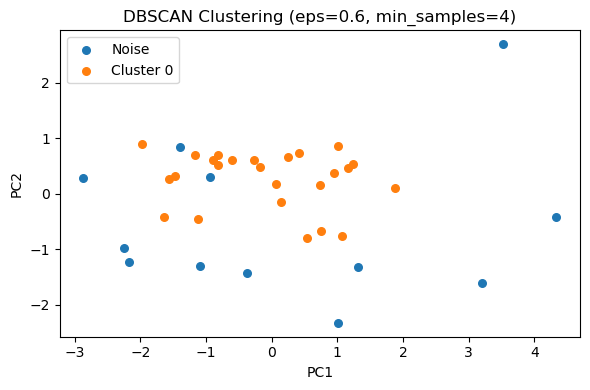

In [403]:
### Let's try using the same dataset in DBSCAN

df_seasons_dbscan=df_seasons_1
scaler = StandardScaler()
X = scaler.fit_transform(df_seasons_dbscan)
dbscan = DBSCAN(eps=1, min_samples=3)
db_labels = dbscan.fit_predict(X)

n_clusters = len(set(db_labels) - {-1})
print("DBSCAN clusters (excluding noise):", n_clusters)
pca = PCA(n_components=2)
proj = pca.fit_transform(X)

plt.figure(figsize=(6,4))
for label in sorted(set(db_labels)):
    mask = db_labels == label
    name = f"Cluster {label}" if label != -1 else "Noise"
    plt.scatter(proj[mask,0], proj[mask,1], label=name, s=30)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clustering (eps=0.6, min_samples=4)')
plt.legend()
plt.tight_layout()
plt.show()
plt.show()

In [407]:
### Seems like DBSACN is not performeing well with the current parameters, let;s try to improve them
results = []
for eps in [0.3,0.4,0.5,0.6,0.8]:
    for ms in [3,4,5,6]:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        n_clusters = len(set(labels) - {-1})
        noise_frac = np.mean(labels == -1)
        results.append((eps, ms, n_clusters, noise_frac))

print(pd.DataFrame(results, columns=['eps','min_s','n_clusters','noise_frac']))


    eps  min_s  n_clusters  noise_frac
0   0.3      3           0    1.000000
1   0.3      4           0    1.000000
2   0.3      5           0    1.000000
3   0.3      6           0    1.000000
4   0.4      3           0    1.000000
5   0.4      4           0    1.000000
6   0.4      5           0    1.000000
7   0.4      6           0    1.000000
8   0.5      3           0    1.000000
9   0.5      4           0    1.000000
10  0.5      5           0    1.000000
11  0.5      6           0    1.000000
12  0.6      3           1    0.864865
13  0.6      4           1    0.864865
14  0.6      5           0    1.000000
15  0.6      6           0    1.000000
16  0.8      3           1    0.459459
17  0.8      4           1    0.513514
18  0.8      5           1    0.729730
19  0.8      6           1    0.729730


In [411]:
### Seems like DBSCAN is not performing well despite a try of tuning the parameters (eps and min_samples) with almost all possible option, and the reson behind this is:
## Low number of observations, as DBSCAN is based on density, 37 observations won't be sufficient to train the model
## high diminonality, more than two dimesntion can cause an issue when using DBSCAN

In [417]:
### Let's save the datasets first 
#df_seasons_1.to_csv('tarining_set.csv')
#df_seasons.to_csv('cleaned_dataset.csv')

Index(['tmax_Winter', 'af_Spring', 'sun_Summer', 'rain_Summer'], dtype='object')

# Classification

In [427]:
### we will utilaie the saem data set prepared earlier to resolve the clasiification problem, first I will add the latitude to each station and classify them Northern, Central or Southern
# we will continue using the same data set (df_seasons)

locations_df=pd.read_csv('locations.csv')

locations_df[['longitude', 'latitude']] = locations_df['Location'].str.split(',', expand=True)
locations_df['latitude'] = locations_df['latitude'].astype(float)
locations_df = locations_df[['station', 'latitude']]
locations_df['station'] = locations_df['station'].str.lower()
locations_df

,station,latitude
0,aberporth,52.139
1,armagh,54.352
2,ballypatrick,55.181
3,bradford,53.813
4,braemar,57.011
5,camborne,50.218
6,cambridge,52.245
7,cardiff,51.488
8,chivenor,51.089
9,cwmystwyth,52.358


In [437]:
# Merge latitude with dataset
df_seasons = df_seasons.merge(locations_df, on='station', how='left')
df_seasons

,station,tmax_Autumn,tmax_Spring,tmax_Summer,tmax_Winter,af_Autumn,af_Spring,af_Summer,af_Winter,rain_Autumn,rain_Spring,rain_Summer,rain_Winter,sun_Autumn,sun_Spring,sun_Summer,sun_Winter,cluster,latitude
0,aberporth,13.415246,11.432763,17.454618,7.686641,0.274510,0.984085,0.000000,4.615687,97.738889,56.785771,63.813889,86.387402,97.813253,168.037317,187.995102,60.173126,1,52.139
1,armagh,13.097708,12.502336,18.792292,7.520378,1.956250,3.279425,0.002083,7.859291,74.651938,57.394197,71.886822,71.147251,85.625965,140.485283,139.811911,50.441700,0,54.352
2,ballypatrick,12.058895,10.484615,16.315340,6.851317,1.037151,3.001578,0.011780,6.309281,129.743100,86.502738,95.403418,127.400175,81.235897,145.792706,152.163008,46.217077,0,55.181
3,bradford,12.734699,11.592913,18.767529,6.364463,1.948743,3.189028,0.000000,9.715624,79.210819,59.650462,67.852924,85.321518,82.498006,132.049650,163.531339,40.070320,0,53.813
4,braemar,10.839394,9.943201,17.110536,4.586500,6.121212,10.516119,0.306061,17.375000,90.059896,61.848759,63.902728,86.975708,70.702174,132.361050,157.167858,34.480203,2,57.011
5,camborne,14.527660,12.129496,18.178261,9.300000,0.127660,0.388489,0.000000,2.361702,107.004255,70.719424,65.656522,117.219149,106.997665,169.971942,192.701449,63.267391,1,50.218
6,cambridge,14.912626,13.592965,21.588384,7.498000,1.712121,3.005025,0.000000,9.435000,52.241146,41.281338,49.090104,43.596816,106.848366,148.024217,186.266415,58.625234,1,52.245
7,cardiff,15.221528,14.109155,20.990780,8.755556,1.555556,1.936620,0.000000,8.125000,114.143056,78.897887,80.806383,119.379861,100.977193,152.632022,189.744444,55.873684,1,51.488
8,chivenor,15.342553,13.705309,19.948400,9.388323,0.755061,1.270116,0.000000,4.920927,91.613636,56.709721,67.331079,84.890552,106.525000,178.350024,206.069123,64.363086,1,51.089
9,cwmystwyth,12.316512,10.818138,17.219001,6.222931,2.829989,5.962839,0.074830,11.564490,181.648768,118.124601,123.206000,177.131677,79.782032,124.638622,142.981094,39.602425,2,52.358


In [431]:
def assign_region(lat):
    """
    Assigns a station to one of three UK thirds based on latitude:
      - 'South'   : 49.9 ≤ lat < 53.567
      - 'Central' : 53.567 ≤ lat < 57.234
      - 'North'   : 57.234 ≤ lat ≤ 60.9
    """
    # Southern third
    if 49.9 <= lat < 53.567:
        return 'South'
    # Central third
    if 53.567 <= lat < 57.234:
        return 'Central'
    # Northern third
    if 57.234 <= lat <= 60.9:
        return 'North'
    # Out of expected range
    raise ValueError(f"Latitude {lat} is outside the range 49.9–60.9°")

In [439]:
df_seasons['region'] = df_seasons['latitude'].apply(assign_region)
df_seasons

,station,tmax_Autumn,tmax_Spring,tmax_Summer,tmax_Winter,af_Autumn,af_Spring,af_Summer,af_Winter,rain_Autumn,rain_Spring,rain_Summer,rain_Winter,sun_Autumn,sun_Spring,sun_Summer,sun_Winter,cluster,latitude,region
0,aberporth,13.415246,11.432763,17.454618,7.686641,0.274510,0.984085,0.000000,4.615687,97.738889,56.785771,63.813889,86.387402,97.813253,168.037317,187.995102,60.173126,1,52.139,South
1,armagh,13.097708,12.502336,18.792292,7.520378,1.956250,3.279425,0.002083,7.859291,74.651938,57.394197,71.886822,71.147251,85.625965,140.485283,139.811911,50.441700,0,54.352,Central
2,ballypatrick,12.058895,10.484615,16.315340,6.851317,1.037151,3.001578,0.011780,6.309281,129.743100,86.502738,95.403418,127.400175,81.235897,145.792706,152.163008,46.217077,0,55.181,Central
3,bradford,12.734699,11.592913,18.767529,6.364463,1.948743,3.189028,0.000000,9.715624,79.210819,59.650462,67.852924,85.321518,82.498006,132.049650,163.531339,40.070320,0,53.813,Central
4,braemar,10.839394,9.943201,17.110536,4.586500,6.121212,10.516119,0.306061,17.375000,90.059896,61.848759,63.902728,86.975708,70.702174,132.361050,157.167858,34.480203,2,57.011,Central
5,camborne,14.527660,12.129496,18.178261,9.300000,0.127660,0.388489,0.000000,2.361702,107.004255,70.719424,65.656522,117.219149,106.997665,169.971942,192.701449,63.267391,1,50.218,South
6,cambridge,14.912626,13.592965,21.588384,7.498000,1.712121,3.005025,0.000000,9.435000,52.241146,41.281338,49.090104,43.596816,106.848366,148.024217,186.266415,58.625234,1,52.245,South
7,cardiff,15.221528,14.109155,20.990780,8.755556,1.555556,1.936620,0.000000,8.125000,114.143056,78.897887,80.806383,119.379861,100.977193,152.632022,189.744444,55.873684,1,51.488,South
8,chivenor,15.342553,13.705309,19.948400,9.388323,0.755061,1.270116,0.000000,4.920927,91.613636,56.709721,67.331079,84.890552,106.525000,178.350024,206.069123,64.363086,1,51.089,South
9,cwmystwyth,12.316512,10.818138,17.219001,6.222931,2.829989,5.962839,0.074830,11.564490,181.648768,118.124601,123.206000,177.131677,79.782032,124.638622,142.981094,39.602425,2,52.358,South


In [1119]:
### let's check the distribution of the regions
df_seasons['region'].value_counts()

region
South      21
Central    12
North       4
Name: count, dtype: int64

In [599]:
df_back=df_seasons

y = df_back["region"]  # target label
X = df_back.drop(columns=["region", "station", "cluster", "latitude"])  # all predictors (Numeric)


def cv_accuracy(cols):
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
    scores = cross_val_score(pipe, X[cols], y,cv=5, scoring="accuracy")
    return scores.mean()

current_cols = list(X.columns)
current_score = cv_accuracy(current_cols)
print(f"Start: {len(current_cols)} features, accuracy = {current_score:.3f}")


while len(current_cols) > 1:
    scores_if_dropped = {}
    for col in current_cols:
        trial_cols = [c for c in current_cols if c != col]
        scores_if_dropped[col] = cv_accuracy(trial_cols)

    best_drop = max(scores_if_dropped, key=scores_if_dropped.get)
    best_score = scores_if_dropped[best_drop]

    if best_score < current_score:
        print("Stopping: removing any feature now decreases accuracy.")
        break

    current_cols.remove(best_drop)
    current_score = best_score
    print(f"Drop {best_drop:15s}  ->  {current_score:.3f}  ({len(current_cols)} left)")

print("\nSelected features:\n", current_cols)
print(f"Final 5-fold CV accuracy: {current_score:.3f}")


Start: 16 features, accuracy = 0.782
Drop sun_Winter       ->  0.839  (15 left)
Drop sun_Autumn       ->  0.868  (14 left)
Drop rain_Autumn      ->  0.893  (13 left)
Drop tmax_Winter      ->  0.893  (12 left)
Drop af_Spring        ->  0.893  (11 left)
Drop af_Summer        ->  0.893  (10 left)
Drop rain_Spring      ->  0.893  (9 left)
Drop rain_Winter      ->  0.921  (8 left)
Drop tmax_Autumn      ->  0.921  (7 left)
Drop sun_Spring       ->  0.921  (6 left)
Drop af_Winter        ->  0.921  (5 left)
Drop tmax_Spring      ->  0.921  (4 left)
Stopping: removing any feature now decreases accuracy.

Selected features:
 ['tmax_Summer', 'af_Autumn', 'rain_Summer', 'sun_Summer']
Final 5-fold CV accuracy: 0.921


### In the above example, I have used one od the Wrappers which is  Backward elimination Where I am testing the accuarcy startign with all the featuers and then start removing Remove features one at a time choosing the one that gives best improvement and the good thing is that it gave me almost the same fueaters set the I choosen during clustering usin the correlation cofficent which confirms  that I am on the right track

In [622]:
# final feature set
X = df_seasons[['tmax_Summer', 'af_Autumn', 'rain_Summer', 'sun_Summer']]
y = df_seasons['region']


last_five = sorted(df_seasons['station'].unique())[-5:]     # alphabetically last
test_mask = df_seasons['station'].isin(last_five)

X_train, X_test = X[~test_mask], X[test_mask]
y_train, y_test = y[~test_mask], y[test_mask]

print("Held-out stations:", ", ".join(last_five))


scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std  = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_std, y_train)

y_pred = knn.predict(X_test_std)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Held-out stations: valley, waddington, whitby, wickairport, yeovilton

Accuracy: 0.8
              precision    recall  f1-score   support

     Central      0.000     0.000     0.000         1
       North      1.000     1.000     1.000         1
       South      0.750     1.000     0.857         3

    accuracy                          0.800         5
   macro avg      0.583     0.667     0.619         5
weighted avg      0.650     0.800     0.714         5



In [638]:
df_back=df_seasons

y = df_back["region"]  # target label
X = df_back.drop(columns=["region", "station", "cluster", "latitude"])  # all predictors (Numeric)


def cv_accuracy(cols):
    pipe = make_pipeline(StandardScaler(), GaussianNB())
    scores = cross_val_score(pipe, X[cols], y,cv=5, scoring="accuracy")
    return scores.mean()

current_cols = list(X.columns)
current_score = cv_accuracy(current_cols)
print(f"Start: {len(current_cols)} features, accuracy = {current_score:.3f}")


while len(current_cols) > 1:
    scores_if_dropped = {}
    for col in current_cols:
        trial_cols = [c for c in current_cols if c != col]
        scores_if_dropped[col] = cv_accuracy(trial_cols)

    best_drop = max(scores_if_dropped, key=scores_if_dropped.get)
    best_score = scores_if_dropped[best_drop]

    if best_score < current_score:
        print("Stopping: removing any feature now decreases accuracy.")
        break

    current_cols.remove(best_drop)
    current_score = best_score
    print(f"Drop {best_drop:15s}  ->  {current_score:.3f}  ({len(current_cols)} left)")

print("\nSelected features:\n", current_cols)
print(f"Final 5-fold CV accuracy: {current_score:.3f}")


Start: 16 features, accuracy = 0.761
Drop sun_Spring       ->  0.839  (15 left)
Drop rain_Summer      ->  0.843  (14 left)
Drop af_Spring        ->  0.843  (13 left)
Drop af_Summer        ->  0.843  (12 left)
Drop rain_Autumn      ->  0.871  (11 left)
Drop rain_Winter      ->  0.896  (10 left)
Stopping: removing any feature now decreases accuracy.

Selected features:
 ['tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter', 'af_Autumn', 'af_Winter', 'rain_Spring', 'sun_Autumn', 'sun_Summer', 'sun_Winter']
Final 5-fold CV accuracy: 0.896


In [662]:
# final feature set
X = df_seasons[['tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter', 'af_Autumn', 'af_Winter', 'rain_Spring', 'sun_Autumn', 'sun_Summer', 'sun_Winter']]
y = df_seasons['region']


last_five = sorted(df_seasons['station'].unique())[-5:]     # alphabetically last
test_mask = df_seasons['station'].isin(last_five)

X_train, X_test = X[~test_mask], X[test_mask]
y_train, y_test = y[~test_mask], y[test_mask]

print("Held-out stations:", ", ".join(last_five))


scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std  = scaler.transform(X_test)

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Held-out stations: valley, waddington, whitby, wickairport, yeovilton

Accuracy: 0.8
              precision    recall  f1-score   support

     Central      0.000     0.000     0.000         1
       North      1.000     1.000     1.000         1
       South      0.750     1.000     0.857         3

    accuracy                          0.800         5
   macro avg      0.583     0.667     0.619         5
weighted avg      0.650     0.800     0.714         5



### The five-station hold-out set gives us a headline accuracy of 0.80—four of the five stations were labelled in the correct latitude band—but the per-class metrics reveal what that single figure hides.

Support is simply the number of true examples for each class in the test set: 3 South, 1 North, 1 Central.
Precision answers “when the model predicts this class, how often is it right?” For South the model produced four ‘South’ labels and three were correct, so precision is 0.750. It never predicted ‘Central’, so Central precision is 0 (undefined defaults to zero). For North it predicted ‘North’ exactly once and that was correct—precision 1.000.
Recall (also called sensitivity) asks “out of the true members of this class, how many did the model find?” All three South stations were caught (recall 1.000); the single North station was caught (recall 1.000); the single Central station was missed (recall 0.000).
F1-score is the harmonic mean of precision and recall. It is 0 for Central (both components are zero), 1.000 for North (both perfect), and 0.857 for South—penalised a little by the one South false-positive.

# Happiness

In [678]:
xls=pd.read_excel('geographicbreakdownreferencetable_tcm77-417203.xls')

In [686]:
df_happy = pd.read_excel('geographicbreakdownreferencetable_tcm77-417203.xls',
                         sheet_name="Happiness",
                         skiprows=5,   # <- number of rows to skip
                         engine="xlrd")

In [688]:
df_happy

,Area Codes,Area names,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,CV,...,CV.2,Lower limit.2,Upper limit.2,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Unnamed: 24
0,K02000001,UNITED KINGDOM,NaN,NaN,8.93,16.68,40.28,34.11,7.46,1.07,...,0.41,39.95,40.61,0.48,33.78,34.43,0.1,7.45,7.47,165160
1,E92000001,ENGLAND,NaN,NaN,8.95,16.73,40.47,33.85,7.45,1.2,...,0.46,40.1,40.84,0.55,33.49,34.22,0.11,7.44,7.47,120320
2,E12000001,NORTH EAST,NaN,NaN,10.77,17.05,39.06,33.13,7.34,3.44,...,1.56,37.86,40.25,1.79,31.96,34.29,0.37,7.29,7.4,11310
3,E06000047,NaN,County Durham UA,NaN,10.84,17.04,37.76,34.36,7.37,10.36,...,4.78,34.21,41.3,5.08,30.93,37.8,1.11,7.21,7.53,890
4,E06000005,NaN,Darlington UA,NaN,9.76,15.43,38.68,36.13,7.46,10.71,...,4.65,35.14,42.22,4.94,32.62,39.64,1.08,7.3,7.62,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
454,"Source: April 2014 to March 2015, Annual Popul...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [690]:
df_happy.columns

Index(['Area Codes', 'Area names', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'CV',
       'Lower limit', 'Upper limit', 'CV.1', 'Lower limit.1', 'Upper limit.1',
       'CV.2', 'Lower limit.2', 'Upper limit.2', 'CV.3', 'Lower limit.3',
       'Upper limit.3', 'CV.4', 'Lower limit.4', 'Upper limit.4',
       'Unnamed: 24'],
      dtype='object')

In [710]:
df_happy=df_happy[df_happy['Area names'].notnull()]

In [712]:
df_happy

,Area Codes,Area names,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,CV,...,CV.2,Lower limit.2,Upper limit.2,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Unnamed: 24
0,K02000001,UNITED KINGDOM,NaN,NaN,8.93,16.68,40.28,34.11,7.46,1.07,...,0.41,39.95,40.61,0.48,33.78,34.43,0.1,7.45,7.47,165160
1,E92000001,ENGLAND,NaN,NaN,8.95,16.73,40.47,33.85,7.45,1.2,...,0.46,40.1,40.84,0.55,33.49,34.22,0.11,7.44,7.47,120320
2,E12000001,NORTH EAST,NaN,NaN,10.77,17.05,39.06,33.13,7.34,3.44,...,1.56,37.86,40.25,1.79,31.96,34.29,0.37,7.29,7.4,11310
16,E12000002,NORTH WEST,NaN,NaN,10.17,16.82,39.1,33.91,7.39,2.79,...,1.17,38.2,39.99,1.36,33.01,34.81,0.29,7.35,7.44,19460
60,E12000003,YORKSHIRE AND THE HUMBER,NaN,NaN,10.21,16.6,38.56,34.63,7.41,3.33,...,1.4,37.5,39.62,1.57,33.56,35.69,0.34,7.36,7.46,13110
85,E12000004,EAST MIDLANDS,NaN,NaN,8.66,16.74,38.62,35.99,7.51,4.36,...,1.78,37.27,39.97,1.9,34.65,37.33,0.4,7.45,7.57,7880
131,E12000005,WEST MIDLANDS,NaN,NaN,8.61,17.59,41.72,32.08,7.43,3.77,...,1.49,40.51,42.94,1.82,30.93,33.22,0.34,7.38,7.48,11940
166,E12000006,EAST,NaN,NaN,8.53,15.69,41.69,34.09,7.51,4.3,...,1.48,40.48,42.9,1.79,32.9,35.29,0.36,7.46,7.57,9960
219,E12000007,LONDON,NaN,NaN,8.32,18.3,42.2,31.18,7.38,3.32,...,1.21,41.2,43.2,1.56,30.23,32.14,0.29,7.34,7.42,13560
255,E12000008,SOUTH EAST,NaN,NaN,7.97,15.83,40.88,35.32,7.54,3.44,...,1.17,39.94,41.82,1.38,34.36,36.28,0.28,7.5,7.58,19490


In [716]:
df_happy.drop(columns=['Unnamed: 2','Unnamed: 3'], inplace=True)

In [718]:
df_happy

,Area Codes,Area names,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,CV,Lower limit,Upper limit,...,CV.2,Lower limit.2,Upper limit.2,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Unnamed: 24
0,K02000001,UNITED KINGDOM,8.93,16.68,40.28,34.11,7.46,1.07,8.75,9.12,...,0.41,39.95,40.61,0.48,33.78,34.43,0.1,7.45,7.47,165160
1,E92000001,ENGLAND,8.95,16.73,40.47,33.85,7.45,1.2,8.73,9.16,...,0.46,40.1,40.84,0.55,33.49,34.22,0.11,7.44,7.47,120320
2,E12000001,NORTH EAST,10.77,17.05,39.06,33.13,7.34,3.44,10.05,11.5,...,1.56,37.86,40.25,1.79,31.96,34.29,0.37,7.29,7.4,11310
16,E12000002,NORTH WEST,10.17,16.82,39.1,33.91,7.39,2.79,9.62,10.73,...,1.17,38.2,39.99,1.36,33.01,34.81,0.29,7.35,7.44,19460
60,E12000003,YORKSHIRE AND THE HUMBER,10.21,16.6,38.56,34.63,7.41,3.33,9.55,10.88,...,1.4,37.5,39.62,1.57,33.56,35.69,0.34,7.36,7.46,13110
85,E12000004,EAST MIDLANDS,8.66,16.74,38.62,35.99,7.51,4.36,7.92,9.4,...,1.78,37.27,39.97,1.9,34.65,37.33,0.4,7.45,7.57,7880
131,E12000005,WEST MIDLANDS,8.61,17.59,41.72,32.08,7.43,3.77,7.97,9.25,...,1.49,40.51,42.94,1.82,30.93,33.22,0.34,7.38,7.48,11940
166,E12000006,EAST,8.53,15.69,41.69,34.09,7.51,4.3,7.81,9.25,...,1.48,40.48,42.9,1.79,32.9,35.29,0.36,7.46,7.57,9960
219,E12000007,LONDON,8.32,18.3,42.2,31.18,7.38,3.32,7.78,8.86,...,1.21,41.2,43.2,1.56,30.23,32.14,0.29,7.34,7.42,13560
255,E12000008,SOUTH EAST,7.97,15.83,40.88,35.32,7.54,3.44,7.43,8.51,...,1.17,39.94,41.82,1.38,34.36,36.28,0.28,7.5,7.58,19490


In [728]:
df_happy.columns=['Area Codes', 'Area names', 'Low', 'Medium', 'High',
       'Very High', 'average raiting', 'CV', 'Lower limit', 'Upper limit', 'CV.1',
       'Lower limit.1', 'Upper limit.1', 'CV.2', 'Lower limit.2',
       'Upper limit.2', 'CV.3', 'Lower limit.3', 'Upper limit.3', 'CV.4',
       'Lower limit.4', 'Upper limit.4', 'Sample size']

In [730]:
df_happy

,Area Codes,Area names,Low,Medium,High,Very High,average raiting,CV,Lower limit,Upper limit,...,CV.2,Lower limit.2,Upper limit.2,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size
0,K02000001,UNITED KINGDOM,8.93,16.68,40.28,34.11,7.46,1.07,8.75,9.12,...,0.41,39.95,40.61,0.48,33.78,34.43,0.1,7.45,7.47,165160
1,E92000001,ENGLAND,8.95,16.73,40.47,33.85,7.45,1.2,8.73,9.16,...,0.46,40.1,40.84,0.55,33.49,34.22,0.11,7.44,7.47,120320
2,E12000001,NORTH EAST,10.77,17.05,39.06,33.13,7.34,3.44,10.05,11.5,...,1.56,37.86,40.25,1.79,31.96,34.29,0.37,7.29,7.4,11310
16,E12000002,NORTH WEST,10.17,16.82,39.1,33.91,7.39,2.79,9.62,10.73,...,1.17,38.2,39.99,1.36,33.01,34.81,0.29,7.35,7.44,19460
60,E12000003,YORKSHIRE AND THE HUMBER,10.21,16.6,38.56,34.63,7.41,3.33,9.55,10.88,...,1.4,37.5,39.62,1.57,33.56,35.69,0.34,7.36,7.46,13110
85,E12000004,EAST MIDLANDS,8.66,16.74,38.62,35.99,7.51,4.36,7.92,9.4,...,1.78,37.27,39.97,1.9,34.65,37.33,0.4,7.45,7.57,7880
131,E12000005,WEST MIDLANDS,8.61,17.59,41.72,32.08,7.43,3.77,7.97,9.25,...,1.49,40.51,42.94,1.82,30.93,33.22,0.34,7.38,7.48,11940
166,E12000006,EAST,8.53,15.69,41.69,34.09,7.51,4.3,7.81,9.25,...,1.48,40.48,42.9,1.79,32.9,35.29,0.36,7.46,7.57,9960
219,E12000007,LONDON,8.32,18.3,42.2,31.18,7.38,3.32,7.78,8.86,...,1.21,41.2,43.2,1.56,30.23,32.14,0.29,7.34,7.42,13560
255,E12000008,SOUTH EAST,7.97,15.83,40.88,35.32,7.54,3.44,7.43,8.51,...,1.17,39.94,41.82,1.38,34.36,36.28,0.28,7.5,7.58,19490


In [726]:
df_happy.columns

Index(['Area Codes', 'Area names', '0-4', '5-6', '7-8', '9-10',
       'average raiting', 'CV', 'Lower limit', 'Upper limit', 'CV.1',
       'Lower limit.1', 'Upper limit.1', 'CV.2', 'Lower limit.2',
       'Upper limit.2', 'CV.3', 'Lower limit.3', 'Upper limit.3', 'CV.4',
       'Lower limit.4', 'Upper limit.4', 'Sample size'],
      dtype='object')

In [842]:
df_happy['Area names'].unique()

array(['UNITED KINGDOM', 'ENGLAND', 'NORTH EAST', 'NORTH WEST ',
       'YORKSHIRE AND THE HUMBER', 'EAST MIDLANDS', 'WEST MIDLANDS',
       'EAST', 'LONDON', 'SOUTH EAST', 'SOUTH WEST', 'WALES', 'SCOTLAND',
       'NORTHERN IRELAND5'], dtype=object)

In [874]:
### I have copied the details of regions form learn and placed them in a CSV file called regions, let's read it
regions=pd.read_csv('regions.csv', names=(['area_code','area_name', 'latitude', 'longtitude']))
regions.area_name.unique()

array(['NORTH EAST', 'NORTH WEST', 'YORKSHIRE AND THE HUMBER',
       'EAST MIDLANDS', 'WEST MIDLANDS', 'EAST', 'LONDON', 'SOUTH EAST',
       'SOUTH WEST', 'WALES', 'SCOTLAND', 'NORTHERN IRELAND'],
      dtype=object)

In [852]:
### UK and ENGLAD should be dropped form the happiness dataset as all the regions are under UK and ENgland has london
df_happy=df_happy[(df_happy['Area names'] != 'UNITED KINGDOM') & (df_happy['Area names'] != 'ENGLAND')]
df_happy

,Area Codes,Area names,Low,Medium,High,Very High,average raiting,CV,Lower limit,Upper limit,...,CV.2,Lower limit.2,Upper limit.2,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size
2,E12000001,NORTH EAST,10.77,17.05,39.06,33.13,7.34,3.44,10.05,11.5,...,1.56,37.86,40.25,1.79,31.96,34.29,0.37,7.29,7.4,11310
16,E12000002,NORTH WEST,10.17,16.82,39.1,33.91,7.39,2.79,9.62,10.73,...,1.17,38.2,39.99,1.36,33.01,34.81,0.29,7.35,7.44,19460
60,E12000003,YORKSHIRE AND THE HUMBER,10.21,16.6,38.56,34.63,7.41,3.33,9.55,10.88,...,1.4,37.5,39.62,1.57,33.56,35.69,0.34,7.36,7.46,13110
85,E12000004,EAST MIDLANDS,8.66,16.74,38.62,35.99,7.51,4.36,7.92,9.4,...,1.78,37.27,39.97,1.9,34.65,37.33,0.4,7.45,7.57,7880
131,E12000005,WEST MIDLANDS,8.61,17.59,41.72,32.08,7.43,3.77,7.97,9.25,...,1.49,40.51,42.94,1.82,30.93,33.22,0.34,7.38,7.48,11940
166,E12000006,EAST,8.53,15.69,41.69,34.09,7.51,4.3,7.81,9.25,...,1.48,40.48,42.9,1.79,32.9,35.29,0.36,7.46,7.57,9960
219,E12000007,LONDON,8.32,18.3,42.2,31.18,7.38,3.32,7.78,8.86,...,1.21,41.2,43.2,1.56,30.23,32.14,0.29,7.34,7.42,13560
255,E12000008,SOUTH EAST,7.97,15.83,40.88,35.32,7.54,3.44,7.43,8.51,...,1.17,39.94,41.82,1.38,34.36,36.28,0.28,7.5,7.58,19490
330,E12000009,SOUTH WEST,8.79,15.92,40.44,34.84,7.5,3.64,8.17,9.42,...,1.38,39.34,41.53,1.57,33.77,35.92,0.31,7.46,7.55,13600
372,W92000004,WALES,9.56,16.54,39.45,34.45,7.44,2.85,9.02,10.09,...,1.13,38.58,40.33,1.37,33.53,35.38,0.3,7.39,7.48,19540


In [858]:
set(df_happy['Area names'].unique()) - set(regions.area_name.unique())

{'NORTH WEST ', 'NORTHERN IRELAND5'}

In [894]:
### We have small observation which we should take care of it before merging the data sets, {'NORTH WEST ', 'NORTHERN IRELAND5'} regions are having a slight difference bwtween the datasets, in happiness dataset,NORTH WEST has a wihte space which can be handeled by applying .strip but NORTHERN IRELAND5 is having extra 5 at the end whihc will make the merge incorrect
df_happy["Area names"] = df_happy["Area names"].replace({"NORTHERN IRELAND5": "NORTHERN IRELAND"})
df_happy["Area names"] = df_happy["Area names"].replace({"NORTH WEST ": "NORTH WEST"})
df_happy

,Area Codes,Area names,Low,Medium,High,Very High,average raiting,CV,Lower limit,Upper limit,...,CV.2,Lower limit.2,Upper limit.2,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size
2,E12000001,NORTH EAST,10.77,17.05,39.06,33.13,7.34,3.44,10.05,11.5,...,1.56,37.86,40.25,1.79,31.96,34.29,0.37,7.29,7.4,11310
16,E12000002,NORTH WEST,10.17,16.82,39.1,33.91,7.39,2.79,9.62,10.73,...,1.17,38.2,39.99,1.36,33.01,34.81,0.29,7.35,7.44,19460
60,E12000003,YORKSHIRE AND THE HUMBER,10.21,16.6,38.56,34.63,7.41,3.33,9.55,10.88,...,1.4,37.5,39.62,1.57,33.56,35.69,0.34,7.36,7.46,13110
85,E12000004,EAST MIDLANDS,8.66,16.74,38.62,35.99,7.51,4.36,7.92,9.4,...,1.78,37.27,39.97,1.9,34.65,37.33,0.4,7.45,7.57,7880
131,E12000005,WEST MIDLANDS,8.61,17.59,41.72,32.08,7.43,3.77,7.97,9.25,...,1.49,40.51,42.94,1.82,30.93,33.22,0.34,7.38,7.48,11940
166,E12000006,EAST,8.53,15.69,41.69,34.09,7.51,4.3,7.81,9.25,...,1.48,40.48,42.9,1.79,32.9,35.29,0.36,7.46,7.57,9960
219,E12000007,LONDON,8.32,18.3,42.2,31.18,7.38,3.32,7.78,8.86,...,1.21,41.2,43.2,1.56,30.23,32.14,0.29,7.34,7.42,13560
255,E12000008,SOUTH EAST,7.97,15.83,40.88,35.32,7.54,3.44,7.43,8.51,...,1.17,39.94,41.82,1.38,34.36,36.28,0.28,7.5,7.58,19490
330,E12000009,SOUTH WEST,8.79,15.92,40.44,34.84,7.5,3.64,8.17,9.42,...,1.38,39.34,41.53,1.57,33.77,35.92,0.31,7.46,7.55,13600
372,W92000004,WALES,9.56,16.54,39.45,34.45,7.44,2.85,9.02,10.09,...,1.13,38.58,40.33,1.37,33.53,35.38,0.3,7.39,7.48,19540


In [896]:
## Now we have difference
set(df_happy['Area names'].unique()) - set(regions.area_name.unique())

set()

In [900]:
regions["key"]   = regions["area_name"].str.upper().str.strip()
df_happy["key"]  = df_happy["Area names"].str.upper().str.strip()

In [912]:
merged = df_happy.merge(regions[["key", "area_code", "latitude", "longtitude"]],on="key", how="left")
merged

,Area Codes,Area names,Low,Medium,High,Very High,average raiting,CV,Lower limit,Upper limit,...,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size,key,area_code,latitude,longtitude
0,E12000001,NORTH EAST,10.77,17.05,39.06,33.13,7.34,3.44,10.05,11.5,...,31.96,34.29,0.37,7.29,7.4,11310,NORTH EAST,E12000001,55.0,-1.9
1,E12000002,NORTH WEST,10.17,16.82,39.1,33.91,7.39,2.79,9.62,10.73,...,33.01,34.81,0.29,7.35,7.44,19460,NORTH WEST,E12000002,54.0,-2.6
2,E12000003,YORKSHIRE AND THE HUMBER,10.21,16.6,38.56,34.63,7.41,3.33,9.55,10.88,...,33.56,35.69,0.34,7.36,7.46,13110,YORKSHIRE AND THE HUMBER,E12000003,53.6,-1.2
3,E12000004,EAST MIDLANDS,8.66,16.74,38.62,35.99,7.51,4.36,7.92,9.4,...,34.65,37.33,0.4,7.45,7.57,7880,EAST MIDLANDS,E12000004,53.0,-0.8
4,E12000005,WEST MIDLANDS,8.61,17.59,41.72,32.08,7.43,3.77,7.97,9.25,...,30.93,33.22,0.34,7.38,7.48,11940,WEST MIDLANDS,E12000005,52.5,-2.3
5,E12000006,EAST,8.53,15.69,41.69,34.09,7.51,4.3,7.81,9.25,...,32.9,35.29,0.36,7.46,7.57,9960,EAST,E12000006,52.2,0.4
6,E12000007,LONDON,8.32,18.3,42.2,31.18,7.38,3.32,7.78,8.86,...,30.23,32.14,0.29,7.34,7.42,13560,LONDON,E12000007,51.5,-0.1
7,E12000008,SOUTH EAST,7.97,15.83,40.88,35.32,7.54,3.44,7.43,8.51,...,34.36,36.28,0.28,7.5,7.58,19490,SOUTH EAST,E12000008,51.3,-0.5
8,E12000009,SOUTH WEST,8.79,15.92,40.44,34.84,7.5,3.64,8.17,9.42,...,33.77,35.92,0.31,7.46,7.55,13600,SOUTH WEST,E12000009,51.0,-3.2
9,W92000004,WALES,9.56,16.54,39.45,34.45,7.44,2.85,9.02,10.09,...,33.53,35.38,0.3,7.39,7.48,19540,WALES,W92000004,51.5,-3.2


In [914]:
merged = merged.drop(columns="key")

In [920]:
merged['latitude'].nunique()

11

In [922]:
merged[merged.duplicated(subset="latitude", keep=False)]

,Area Codes,Area names,Low,Medium,High,Very High,average raiting,CV,Lower limit,Upper limit,...,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size,area_code,latitude,longtitude
6,E12000007,LONDON,8.32,18.3,42.2,31.18,7.38,3.32,7.78,8.86,...,1.56,30.23,32.14,0.29,7.34,7.42,13560,E12000007,51.5,-0.1
9,W92000004,WALES,9.56,16.54,39.45,34.45,7.44,2.85,9.02,10.09,...,1.37,33.53,35.38,0.3,7.39,7.48,19540,W92000004,51.5,-3.2


In [924]:
##I could see that London WALES are having the same latitude, which is a duplicate entry due to rounding issues probabily the correct latitude for wales is 52.1
merged.loc[merged["Area names"] == "WALES", "latitude"] = 52.1

merged

,Area Codes,Area names,Low,Medium,High,Very High,average raiting,CV,Lower limit,Upper limit,...,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size,area_code,latitude,longtitude
0,E12000001,NORTH EAST,10.77,17.05,39.06,33.13,7.34,3.44,10.05,11.5,...,1.79,31.96,34.29,0.37,7.29,7.4,11310,E12000001,55.0,-1.9
1,E12000002,NORTH WEST,10.17,16.82,39.1,33.91,7.39,2.79,9.62,10.73,...,1.36,33.01,34.81,0.29,7.35,7.44,19460,E12000002,54.0,-2.6
2,E12000003,YORKSHIRE AND THE HUMBER,10.21,16.6,38.56,34.63,7.41,3.33,9.55,10.88,...,1.57,33.56,35.69,0.34,7.36,7.46,13110,E12000003,53.6,-1.2
3,E12000004,EAST MIDLANDS,8.66,16.74,38.62,35.99,7.51,4.36,7.92,9.4,...,1.9,34.65,37.33,0.4,7.45,7.57,7880,E12000004,53.0,-0.8
4,E12000005,WEST MIDLANDS,8.61,17.59,41.72,32.08,7.43,3.77,7.97,9.25,...,1.82,30.93,33.22,0.34,7.38,7.48,11940,E12000005,52.5,-2.3
5,E12000006,EAST,8.53,15.69,41.69,34.09,7.51,4.3,7.81,9.25,...,1.79,32.9,35.29,0.36,7.46,7.57,9960,E12000006,52.2,0.4
6,E12000007,LONDON,8.32,18.3,42.2,31.18,7.38,3.32,7.78,8.86,...,1.56,30.23,32.14,0.29,7.34,7.42,13560,E12000007,51.5,-0.1
7,E12000008,SOUTH EAST,7.97,15.83,40.88,35.32,7.54,3.44,7.43,8.51,...,1.38,34.36,36.28,0.28,7.5,7.58,19490,E12000008,51.3,-0.5
8,E12000009,SOUTH WEST,8.79,15.92,40.44,34.84,7.5,3.64,8.17,9.42,...,1.57,33.77,35.92,0.31,7.46,7.55,13600,E12000009,51.0,-3.2
9,W92000004,WALES,9.56,16.54,39.45,34.45,7.44,2.85,9.02,10.09,...,1.37,33.53,35.38,0.3,7.39,7.48,19540,W92000004,52.1,-3.2


In [926]:
### No duplicates now
merged[merged.duplicated(subset="latitude", keep=False)]

,Area Codes,Area names,Low,Medium,High,Very High,average raiting,CV,Lower limit,Upper limit,...,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size,area_code,latitude,longtitude


In [930]:
merged.sort_values(by='latitude')

,Area Codes,Area names,Low,Medium,High,Very High,average raiting,CV,Lower limit,Upper limit,...,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size,area_code,latitude,longtitude
8,E12000009,SOUTH WEST,8.79,15.92,40.44,34.84,7.5,3.64,8.17,9.42,...,1.57,33.77,35.92,0.31,7.46,7.55,13600,E12000009,51.0,-3.2
7,E12000008,SOUTH EAST,7.97,15.83,40.88,35.32,7.54,3.44,7.43,8.51,...,1.38,34.36,36.28,0.28,7.5,7.58,19490,E12000008,51.3,-0.5
6,E12000007,LONDON,8.32,18.3,42.2,31.18,7.38,3.32,7.78,8.86,...,1.56,30.23,32.14,0.29,7.34,7.42,13560,E12000007,51.5,-0.1
9,W92000004,WALES,9.56,16.54,39.45,34.45,7.44,2.85,9.02,10.09,...,1.37,33.53,35.38,0.3,7.39,7.48,19540,W92000004,52.1,-3.2
5,E12000006,EAST,8.53,15.69,41.69,34.09,7.51,4.3,7.81,9.25,...,1.79,32.9,35.29,0.36,7.46,7.57,9960,E12000006,52.2,0.4
4,E12000005,WEST MIDLANDS,8.61,17.59,41.72,32.08,7.43,3.77,7.97,9.25,...,1.82,30.93,33.22,0.34,7.38,7.48,11940,E12000005,52.5,-2.3
3,E12000004,EAST MIDLANDS,8.66,16.74,38.62,35.99,7.51,4.36,7.92,9.4,...,1.9,34.65,37.33,0.4,7.45,7.57,7880,E12000004,53.0,-0.8
2,E12000003,YORKSHIRE AND THE HUMBER,10.21,16.6,38.56,34.63,7.41,3.33,9.55,10.88,...,1.57,33.56,35.69,0.34,7.36,7.46,13110,E12000003,53.6,-1.2
1,E12000002,NORTH WEST,10.17,16.82,39.1,33.91,7.39,2.79,9.62,10.73,...,1.36,33.01,34.81,0.29,7.35,7.44,19460,E12000002,54.0,-2.6
11,N92000002,NORTHERN IRELAND,6.76,14.66,37.57,41,7.75,9.22,5.54,7.99,...,2.83,38.72,43.28,0.6,7.66,7.84,2540,N92000002,54.6,5.9


In [932]:
df_seasons

,station,tmax_Autumn,tmax_Spring,tmax_Summer,tmax_Winter,af_Autumn,af_Spring,af_Summer,af_Winter,rain_Autumn,rain_Spring,rain_Summer,rain_Winter,sun_Autumn,sun_Spring,sun_Summer,sun_Winter,cluster,latitude,region
0,aberporth,13.415246,11.432763,17.454618,7.686641,0.274510,0.984085,0.000000,4.615687,97.738889,56.785771,63.813889,86.387402,97.813253,168.037317,187.995102,60.173126,2,52.139,South
1,armagh,13.097708,12.502336,18.792292,7.520378,1.956250,3.279425,0.002083,7.859291,74.651938,57.394197,71.886822,71.147251,85.625965,140.485283,139.811911,50.441700,0,54.352,Central
2,ballypatrick,12.058895,10.484615,16.315340,6.851317,1.037151,3.001578,0.011780,6.309281,129.743100,86.502738,95.403418,127.400175,81.235897,145.792706,152.163008,46.217077,1,55.181,Central
3,bradford,12.734699,11.592913,18.767529,6.364463,1.948743,3.189028,0.000000,9.715624,79.210819,59.650462,67.852924,85.321518,82.498006,132.049650,163.531339,40.070320,0,53.813,Central
4,braemar,10.839394,9.943201,17.110536,4.586500,6.121212,10.516119,0.306061,17.375000,90.059896,61.848759,63.902728,86.975708,70.702174,132.361050,157.167858,34.480203,0,57.011,Central
5,camborne,14.527660,12.129496,18.178261,9.300000,0.127660,0.388489,0.000000,2.361702,107.004255,70.719424,65.656522,117.219149,106.997665,169.971942,192.701449,63.267391,1,50.218,South
6,cambridge,14.912626,13.592965,21.588384,7.498000,1.712121,3.005025,0.000000,9.435000,52.241146,41.281338,49.090104,43.596816,106.848366,148.024217,186.266415,58.625234,2,52.245,South
7,cardiff,15.221528,14.109155,20.990780,8.755556,1.555556,1.936620,0.000000,8.125000,114.143056,78.897887,80.806383,119.379861,100.977193,152.632022,189.744444,55.873684,2,51.488,South
8,chivenor,15.342553,13.705309,19.948400,9.388323,0.755061,1.270116,0.000000,4.920927,91.613636,56.709721,67.331079,84.890552,106.525000,178.350024,206.069123,64.363086,2,51.089,South
9,cwmystwyth,12.316512,10.818138,17.219001,6.222931,2.829989,5.962839,0.074830,11.564490,181.648768,118.124601,123.206000,177.131677,79.782032,124.638622,142.981094,39.602425,1,52.358,South


In [936]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area Codes       12 non-null     object 
 1   Area names       12 non-null     object 
 2   Low              12 non-null     object 
 3   Medium           12 non-null     object 
 4   High             12 non-null     object 
 5   Very High        12 non-null     object 
 6   average raiting  12 non-null     object 
 7   CV               12 non-null     object 
 8   Lower limit      12 non-null     object 
 9   Upper limit      12 non-null     object 
 10  CV.1             12 non-null     object 
 11  Lower limit.1    12 non-null     object 
 12  Upper limit.1    12 non-null     object 
 13  CV.2             12 non-null     object 
 14  Lower limit.2    12 non-null     object 
 15  Upper limit.2    12 non-null     object 
 16  CV.3             12 non-null     object 
 17  Lower limit.3    1

In [940]:
edges=merged["latitude"].rolling(2).mean().dropna().tolist()
edges

[54.5, 53.8, 53.3, 52.75, 52.35, 51.85, 51.4, 51.15, 51.55, 54.05, 55.3]

In [950]:
df_backup2=df_seasons

In [1129]:
merged_final_backup=merged_final

In [1131]:
merged = merged.sort_values("latitude")
edges  = merged["latitude"].rolling(2).mean().dropna()   # mid-points
bins   = [-float("inf"), *edges, float("inf")]             # add ±∞
labels = merged["Area names"]                             # region names

# 3.  Assign each station to the band it falls in
df_seasons["Area names"] = pd.cut(df_seasons["latitude"],
                                 bins=bins,
                                 labels=labels)

# 4.  Bring any extra region columns onto the station table
merged_final = df_seasons.merge(merged, on="Area names", how="left")
merged_final

,station,tmax_Autumn,tmax_Spring,tmax_Summer,tmax_Winter,af_Autumn,af_Spring,af_Summer,af_Winter,rain_Autumn,...,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size,area_code,latitude_y,longtitude
0,aberporth,13.415246,11.432763,17.454618,7.686641,0.274510,0.984085,0.000000,4.615687,97.738889,...,1.37,33.53,35.38,0.3,7.39,7.48,19540,W92000004,52.1,-3.2
1,armagh,13.097708,12.502336,18.792292,7.520378,1.956250,3.279425,0.002083,7.859291,74.651938,...,2.83,38.72,43.28,0.6,7.66,7.84,2540,N92000002,54.6,5.9
2,ballypatrick,12.058895,10.484615,16.315340,6.851317,1.037151,3.001578,0.011780,6.309281,129.743100,...,1.79,31.96,34.29,0.37,7.29,7.4,11310,E12000001,55.0,-1.9
3,bradford,12.734699,11.592913,18.767529,6.364463,1.948743,3.189028,0.000000,9.715624,79.210819,...,1.36,33.01,34.81,0.29,7.35,7.44,19460,E12000002,54.0,-2.6
4,braemar,10.839394,9.943201,17.110536,4.586500,6.121212,10.516119,0.306061,17.375000,90.059896,...,1.32,33.31,35.08,0.27,7.41,7.49,22760,S92000003,56.0,-3.2
5,camborne,14.527660,12.129496,18.178261,9.300000,0.127660,0.388489,0.000000,2.361702,107.004255,...,1.57,33.77,35.92,0.31,7.46,7.55,13600,E12000009,51.0,-3.2
6,cambridge,14.912626,13.592965,21.588384,7.498000,1.712121,3.005025,0.000000,9.435000,52.241146,...,1.79,32.9,35.29,0.36,7.46,7.57,9960,E12000006,52.2,0.4
7,cardiff,15.221528,14.109155,20.990780,8.755556,1.555556,1.936620,0.000000,8.125000,114.143056,...,1.56,30.23,32.14,0.29,7.34,7.42,13560,E12000007,51.5,-0.1
8,chivenor,15.342553,13.705309,19.948400,9.388323,0.755061,1.270116,0.000000,4.920927,91.613636,...,1.57,33.77,35.92,0.31,7.46,7.55,13600,E12000009,51.0,-3.2
9,cwmystwyth,12.316512,10.818138,17.219001,6.222931,2.829989,5.962839,0.074830,11.564490,181.648768,...,1.82,30.93,33.22,0.34,7.38,7.48,11940,E12000005,52.5,-2.3


In [954]:
labels

0                   NORTH EAST
1                   NORTH WEST
2     YORKSHIRE AND THE HUMBER
3                EAST MIDLANDS
4                WEST MIDLANDS
5                         EAST
6                       LONDON
7                   SOUTH EAST
8                   SOUTH WEST
9                        WALES
10                    SCOTLAND
11            NORTHERN IRELAND
Name: Area names, dtype: object

In [962]:
merged_final.columns

Index(['station', 'tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter',
       'af_Autumn', 'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn',
       'rain_Spring', 'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring',
       'sun_Summer', 'sun_Winter', 'cluster', 'latitude_x', 'region',
       'area_name', 'Area names', 'Area Codes', 'Low', 'Medium', 'High',
       'Very High', 'average raiting', 'CV', 'Lower limit', 'Upper limit',
       'CV.1', 'Lower limit.1', 'Upper limit.1', 'CV.2', 'Lower limit.2',
       'Upper limit.2', 'CV.3', 'Lower limit.3', 'Upper limit.3', 'CV.4',
       'Lower limit.4', 'Upper limit.4', 'Sample size', 'area_code',
       'latitude_y', 'longtitude'],
      dtype='object')

In [972]:
merged_final[['area_name','latitude_x', 'region', 'station']].sort_values(by='latitude_x')

,area_name,latitude_x,region,station
5,SOUTH WEST,50.218,South,camborne
12,SOUTH WEST,50.759,South,eastbourne
15,SOUTH WEST,50.779,South,hurn
28,SOUTH WEST,50.898,South,southampton
36,SOUTH WEST,51.006,South,yeovilton
8,SOUTH WEST,51.089,South,chivenor
19,SOUTH EAST,51.346,South,manston
14,LONDON,51.479,South,heathrow
7,LONDON,51.488,South,cardiff
22,LONDON,51.761,South,oxford


In [976]:
regions.sort_values(by='latitude')

,area_code,area_name,latitude,longtitude,key
8,E12000009,SOUTH WEST,51.0,-3.2,SOUTH WEST
7,E12000008,SOUTH EAST,51.3,-0.5,SOUTH EAST
6,E12000007,LONDON,51.5,-0.1,LONDON
9,W92000004,WALES,51.5,-3.2,WALES
5,E12000006,EAST,52.2,0.4,EAST
4,E12000005,WEST MIDLANDS,52.5,-2.3,WEST MIDLANDS
3,E12000004,EAST MIDLANDS,53.0,-0.8,EAST MIDLANDS
2,E12000003,YORKSHIRE AND THE HUMBER,53.6,-1.2,YORKSHIRE AND THE HUMBER
1,E12000002,NORTH WEST,54.0,-2.6,NORTH WEST
11,N92000002,NORTHERN IRELAND,54.6,5.9,NORTHERN IRELAND


In [1012]:
merged_final

,station,tmax_Autumn,tmax_Spring,tmax_Summer,tmax_Winter,af_Autumn,af_Spring,af_Summer,af_Winter,rain_Autumn,...,CV.3,Lower limit.3,Upper limit.3,CV.4,Lower limit.4,Upper limit.4,Sample size,area_code,latitude_y,longtitude
0,aberporth,13.415246,11.432763,17.454618,7.686641,0.274510,0.984085,0.000000,4.615687,97.738889,...,1.37,33.53,35.38,0.3,7.39,7.48,19540,W92000004,52.1,-3.2
1,armagh,13.097708,12.502336,18.792292,7.520378,1.956250,3.279425,0.002083,7.859291,74.651938,...,2.83,38.72,43.28,0.6,7.66,7.84,2540,N92000002,54.6,5.9
2,ballypatrick,12.058895,10.484615,16.315340,6.851317,1.037151,3.001578,0.011780,6.309281,129.743100,...,1.79,31.96,34.29,0.37,7.29,7.4,11310,E12000001,55.0,-1.9
3,bradford,12.734699,11.592913,18.767529,6.364463,1.948743,3.189028,0.000000,9.715624,79.210819,...,1.36,33.01,34.81,0.29,7.35,7.44,19460,E12000002,54.0,-2.6
4,braemar,10.839394,9.943201,17.110536,4.586500,6.121212,10.516119,0.306061,17.375000,90.059896,...,1.32,33.31,35.08,0.27,7.41,7.49,22760,S92000003,56.0,-3.2
5,camborne,14.527660,12.129496,18.178261,9.300000,0.127660,0.388489,0.000000,2.361702,107.004255,...,1.57,33.77,35.92,0.31,7.46,7.55,13600,E12000009,51.0,-3.2
6,cambridge,14.912626,13.592965,21.588384,7.498000,1.712121,3.005025,0.000000,9.435000,52.241146,...,1.79,32.9,35.29,0.36,7.46,7.57,9960,E12000006,52.2,0.4
7,cardiff,15.221528,14.109155,20.990780,8.755556,1.555556,1.936620,0.000000,8.125000,114.143056,...,1.56,30.23,32.14,0.29,7.34,7.42,13560,E12000007,51.5,-0.1
8,chivenor,15.342553,13.705309,19.948400,9.388323,0.755061,1.270116,0.000000,4.920927,91.613636,...,1.57,33.77,35.92,0.31,7.46,7.55,13600,E12000009,51.0,-3.2
9,cwmystwyth,12.316512,10.818138,17.219001,6.222931,2.829989,5.962839,0.074830,11.564490,181.648768,...,1.82,30.93,33.22,0.34,7.38,7.48,11940,E12000005,52.5,-2.3


In [1040]:
## Let me select the numerical columns and analyze the data set
merged_final.select_dtypes(include=['number']).columns
columns=['tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter', 'af_Autumn',
       'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn', 'rain_Spring',
       'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring', 'sun_Summer',
       'sun_Winter', 'average raiting', 'Area names']
merged_final_numeric=merged_final[columns]
merged_final_numeric

,tmax_Autumn,tmax_Spring,tmax_Summer,tmax_Winter,af_Autumn,af_Spring,af_Summer,af_Winter,rain_Autumn,rain_Spring,rain_Summer,rain_Winter,sun_Autumn,sun_Spring,sun_Summer,sun_Winter,average raiting,Area names
0,13.415246,11.432763,17.454618,7.686641,0.274510,0.984085,0.000000,4.615687,97.738889,56.785771,63.813889,86.387402,97.813253,168.037317,187.995102,60.173126,7.44,WALES
1,13.097708,12.502336,18.792292,7.520378,1.956250,3.279425,0.002083,7.859291,74.651938,57.394197,71.886822,71.147251,85.625965,140.485283,139.811911,50.441700,7.75,NORTHERN IRELAND
2,12.058895,10.484615,16.315340,6.851317,1.037151,3.001578,0.011780,6.309281,129.743100,86.502738,95.403418,127.400175,81.235897,145.792706,152.163008,46.217077,7.34,NORTH EAST
3,12.734699,11.592913,18.767529,6.364463,1.948743,3.189028,0.000000,9.715624,79.210819,59.650462,67.852924,85.321518,82.498006,132.049650,163.531339,40.070320,7.39,NORTH WEST
4,10.839394,9.943201,17.110536,4.586500,6.121212,10.516119,0.306061,17.375000,90.059896,61.848759,63.902728,86.975708,70.702174,132.361050,157.167858,34.480203,7.45,SCOTLAND
5,14.527660,12.129496,18.178261,9.300000,0.127660,0.388489,0.000000,2.361702,107.004255,70.719424,65.656522,117.219149,106.997665,169.971942,192.701449,63.267391,7.50,SOUTH WEST
6,14.912626,13.592965,21.588384,7.498000,1.712121,3.005025,0.000000,9.435000,52.241146,41.281338,49.090104,43.596816,106.848366,148.024217,186.266415,58.625234,7.51,EAST
7,15.221528,14.109155,20.990780,8.755556,1.555556,1.936620,0.000000,8.125000,114.143056,78.897887,80.806383,119.379861,100.977193,152.632022,189.744444,55.873684,7.38,LONDON
8,15.342553,13.705309,19.948400,9.388323,0.755061,1.270116,0.000000,4.920927,91.613636,56.709721,67.331079,84.890552,106.525000,178.350024,206.069123,64.363086,7.50,SOUTH WEST
9,12.316512,10.818138,17.219001,6.222931,2.829989,5.962839,0.074830,11.564490,181.648768,118.124601,123.206000,177.131677,79.782032,124.638622,142.981094,39.602425,7.43,WEST MIDLANDS


In [1048]:
merged_final_numeric.groupby('Area names').mean().corr()

,tmax_Autumn,tmax_Spring,tmax_Summer,tmax_Winter,af_Autumn,af_Spring,af_Summer,af_Winter,rain_Autumn,rain_Spring,rain_Summer,rain_Winter,sun_Autumn,sun_Spring,sun_Summer,sun_Winter,average raiting
tmax_Autumn,1.000000,0.948029,0.942782,0.883217,-0.740062,-0.795544,-0.593479,-0.657981,-0.676728,-0.712118,-0.765714,-0.713178,0.941522,0.731469,0.899340,0.854217,0.194600
tmax_Spring,0.948029,1.000000,0.964844,0.855389,-0.614698,-0.739693,-0.698848,-0.513224,-0.733456,-0.712815,-0.753532,-0.730832,0.807910,0.544738,0.755160,0.746392,0.135999
tmax_Summer,0.942782,0.964844,1.000000,0.733266,-0.659530,-0.744530,-0.656569,-0.459670,-0.775408,-0.744997,-0.764180,-0.783126,0.840488,0.517254,0.783020,0.714391,0.158530
tmax_Winter,0.883217,0.855389,0.733266,1.000000,-0.616258,-0.717506,-0.599229,-0.737939,-0.514747,-0.587821,-0.677194,-0.534705,0.800601,0.757834,0.785937,0.828185,0.192449
af_Autumn,-0.740062,-0.614698,-0.659530,-0.616258,1.000000,0.962473,0.625976,0.867453,0.658947,0.751536,0.812161,0.723433,-0.780592,-0.745162,-0.863292,-0.669215,-0.192540
af_Spring,-0.795544,-0.739693,-0.744530,-0.717506,0.962473,1.000000,0.767025,0.850414,0.731235,0.794997,0.863789,0.760647,-0.761802,-0.697974,-0.850189,-0.660269,-0.137298
af_Summer,-0.593479,-0.698848,-0.656569,-0.599229,0.625976,0.767025,1.000000,0.519183,0.892503,0.875338,0.885325,0.840480,-0.483848,-0.359845,-0.528742,-0.468467,-0.352659
af_Winter,-0.657981,-0.513224,-0.459670,-0.737939,0.867453,0.850414,0.519183,1.000000,0.390581,0.544815,0.648285,0.459560,-0.730697,-0.899250,-0.846714,-0.749938,-0.149575
rain_Autumn,-0.676728,-0.733456,-0.775408,-0.514747,0.658947,0.731235,0.892503,0.390581,1.000000,0.972421,0.940342,0.985111,-0.608317,-0.344513,-0.572915,-0.525002,-0.492140
rain_Spring,-0.712118,-0.712815,-0.744997,-0.587821,0.751536,0.794997,0.875338,0.544815,0.972421,1.000000,0.985857,0.985366,-0.696612,-0.513217,-0.675116,-0.631636,-0.550151


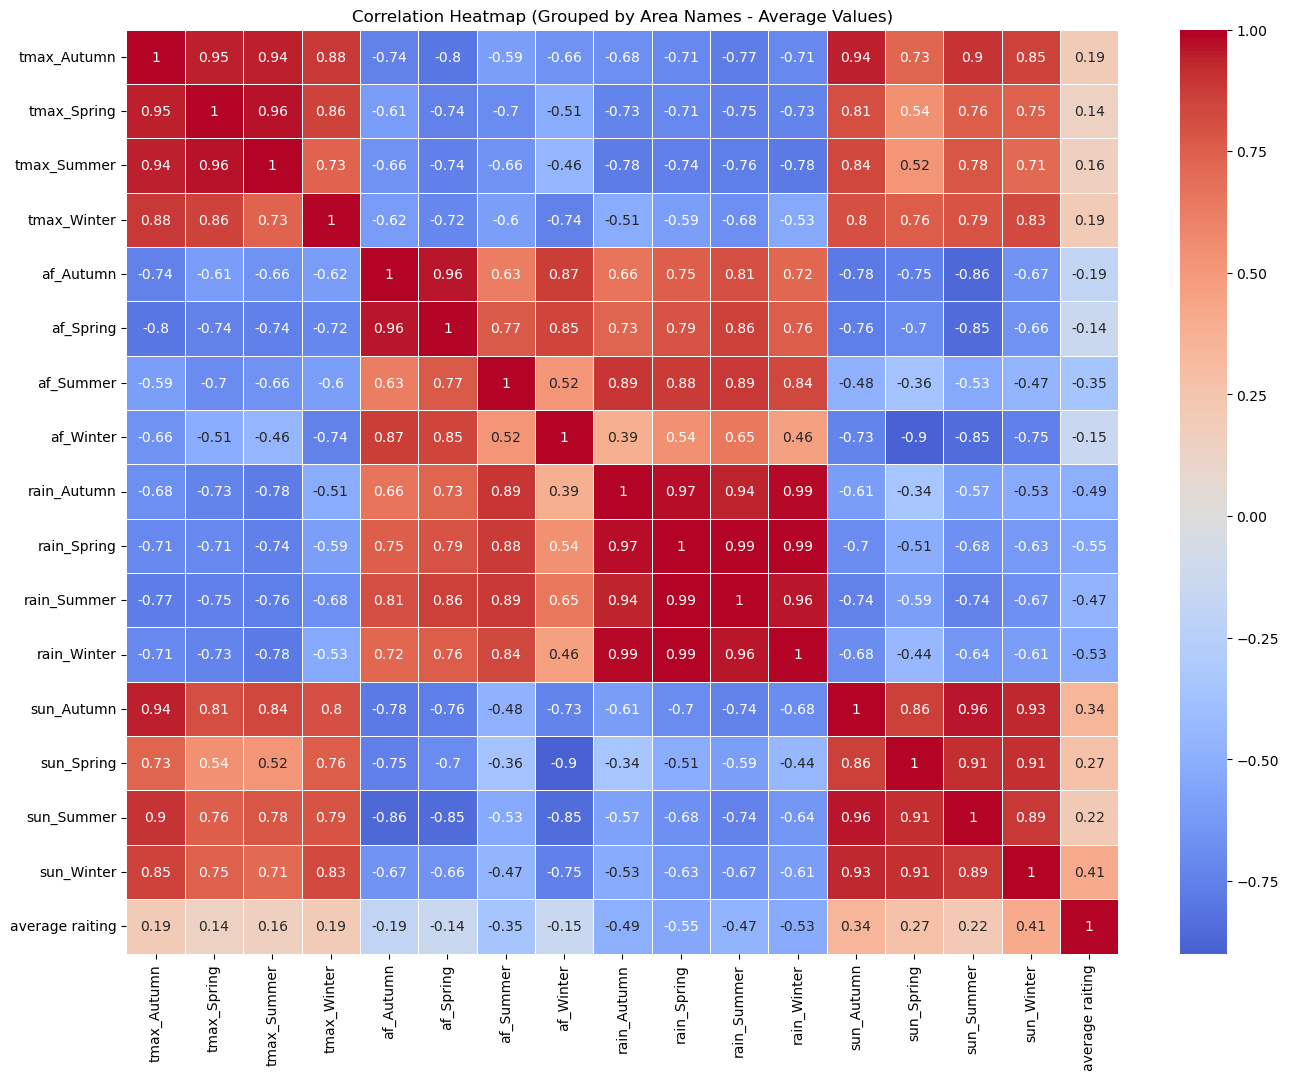

In [1050]:
# Now plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(merged_final_numeric.groupby('Area names').mean().corr(), annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title('Correlation Heatmap (Grouped by Area Names - Average Values)')
plt.show()

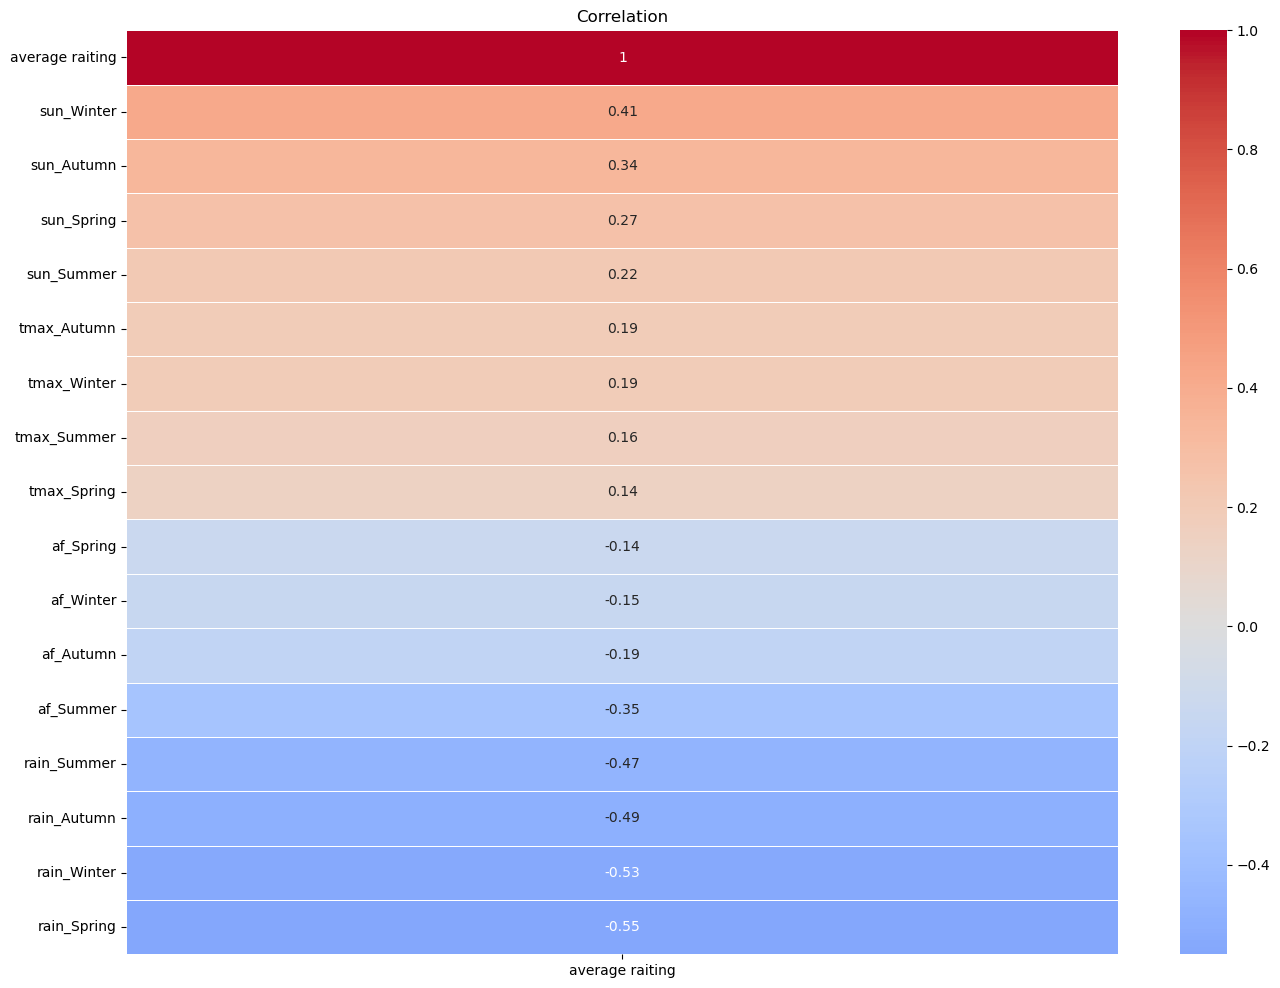

In [1394]:

# let's pick the correlation with averagfe raiting only as it's conufing
plt.figure(figsize=(16, 12))
sns.heatmap(merged_final_numeric.groupby('Area names').mean().corr()[['average raiting']].sort_values(by='average raiting', ascending=False), annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title('Correlation')
plt.show()

### From the above heat map, we could see a that the weather really impact the happiness rates, more sun hours in winter causes a hogher happiness rate and more rainy days during spring can heavily imoact the happiness rate negatively, form what I see, more sun in all the seasons mean happier people, more rain in any of the seasons, make poeple sader, Air forst during sumer seasons can impact the happiness rate as well, let's confirm this by looking into the rates in colder regions (more rain, less sunshine) to confirm

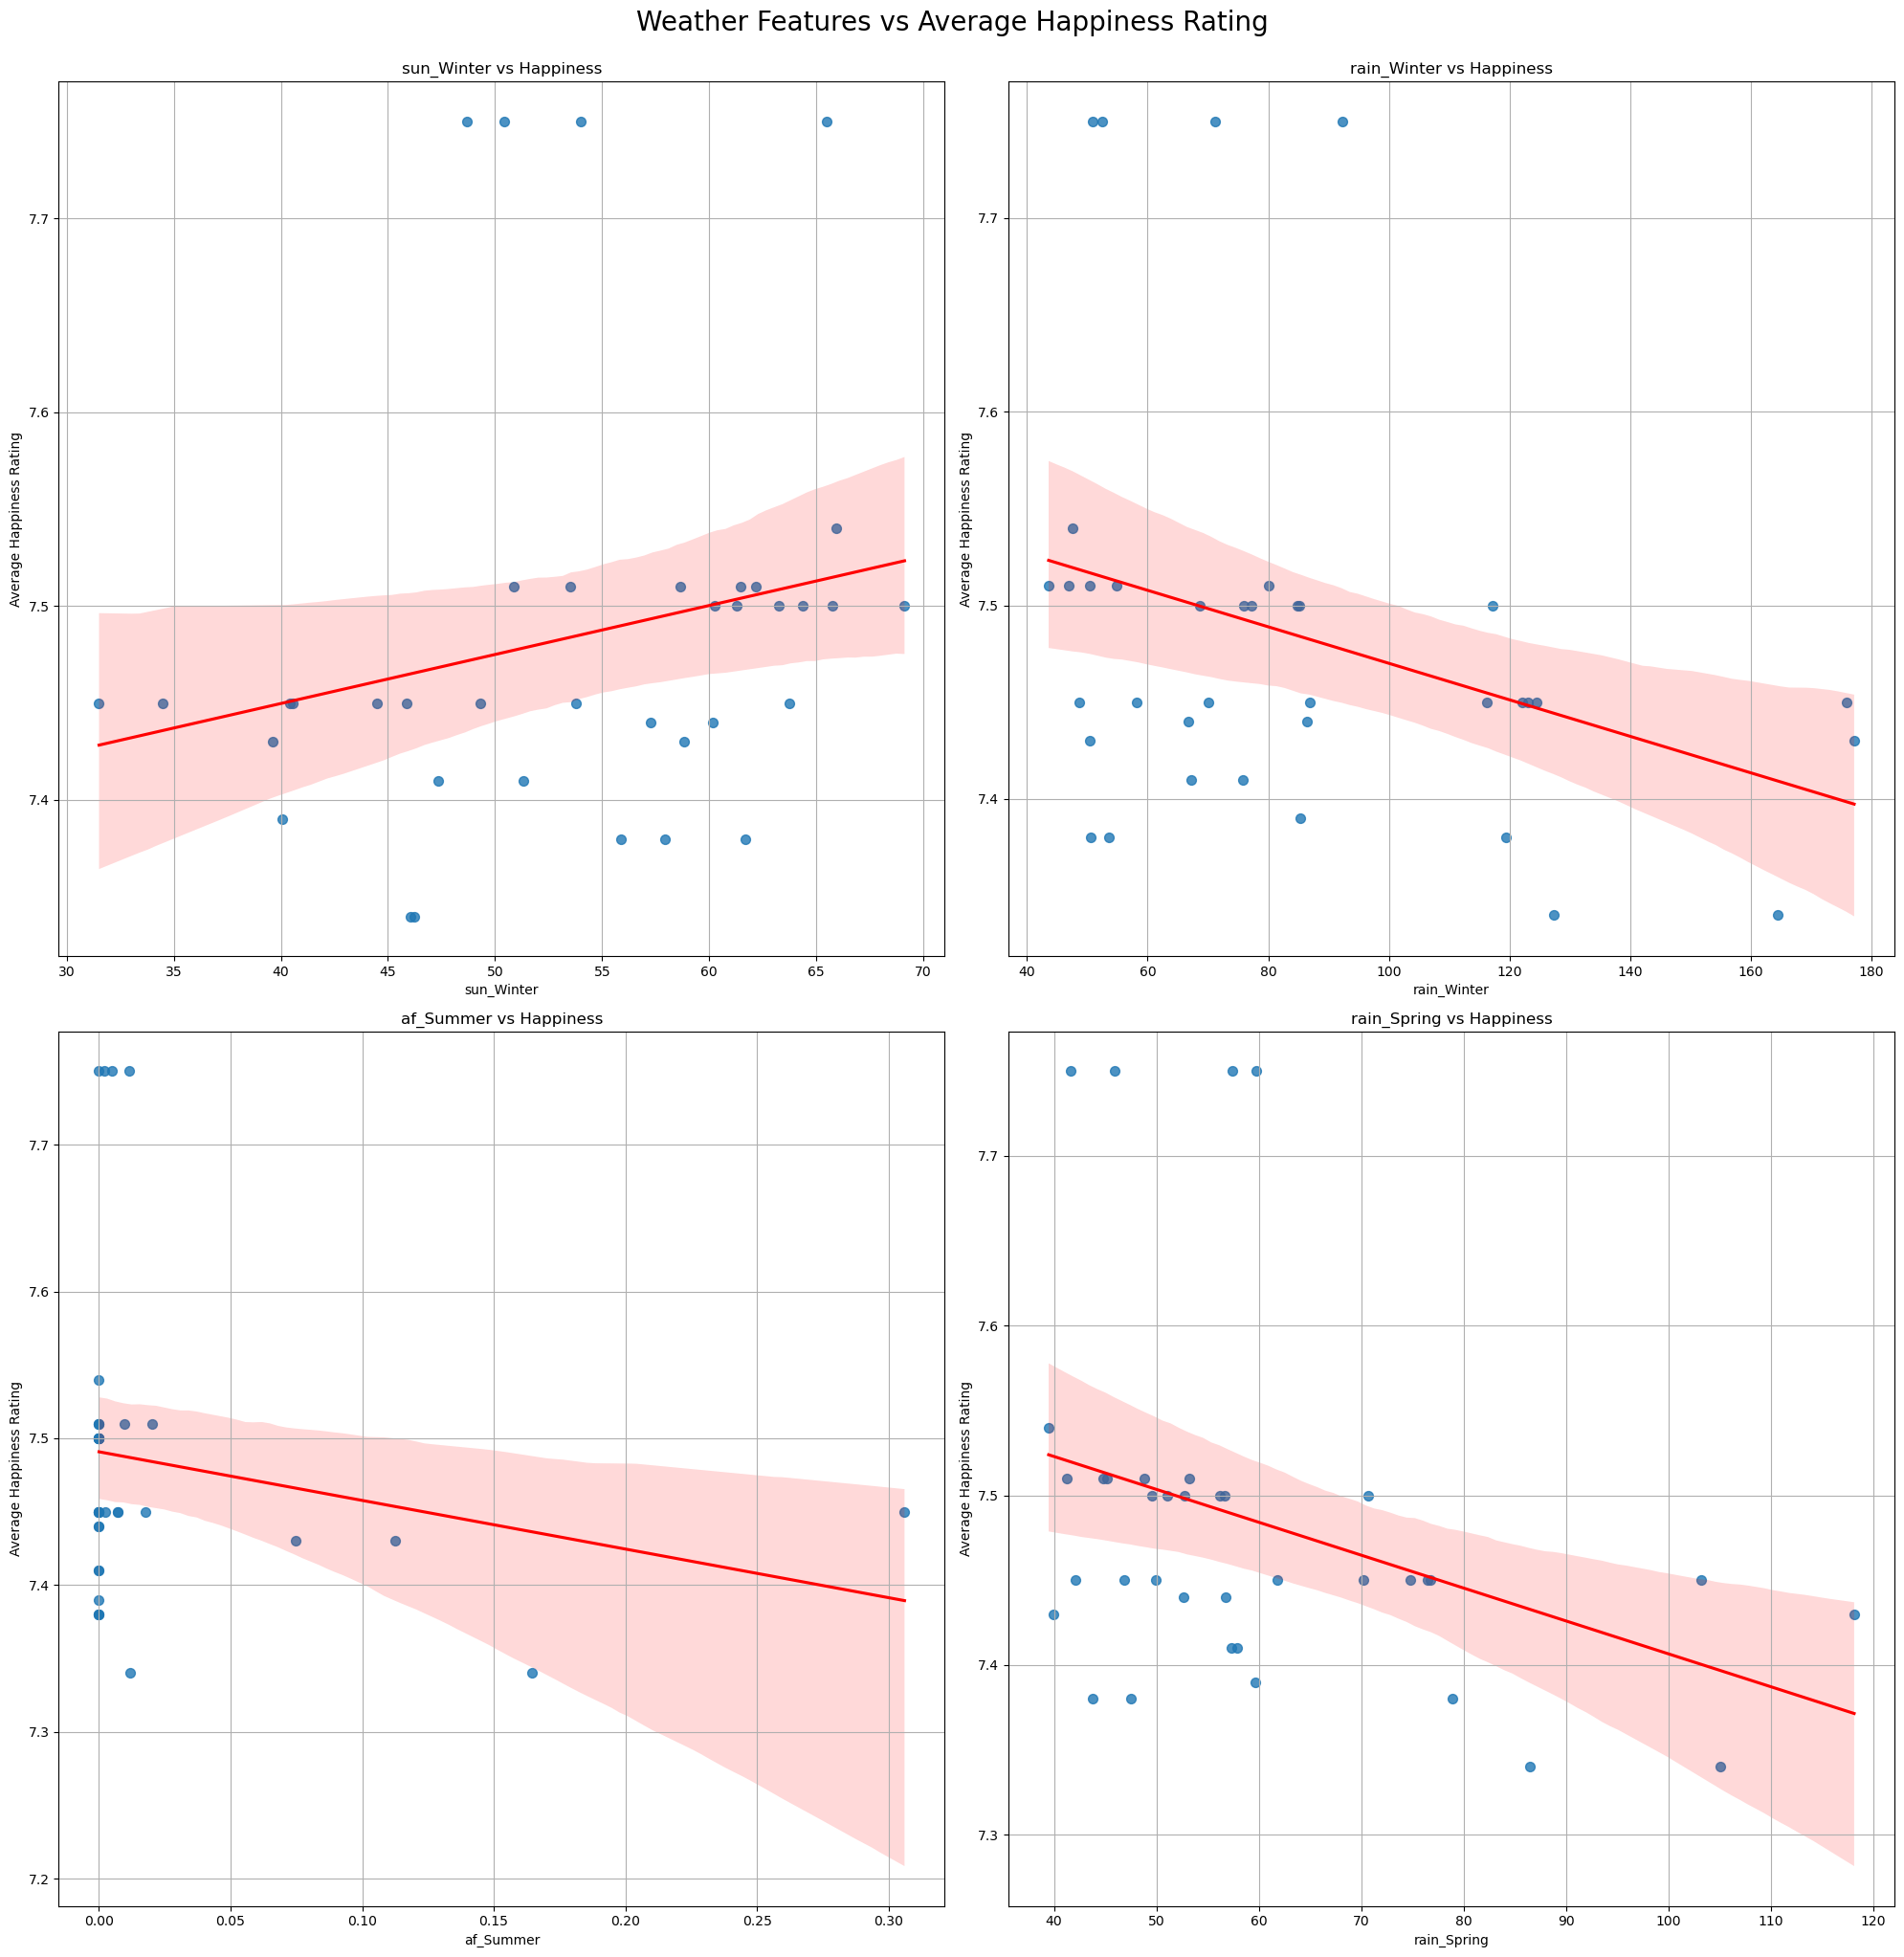

In [1390]:
features_to_plot_extended = [
    'sun_Winter',
    'rain_Winter', 'af_Summer', 'rain_Spring'
]

num_features = len(features_to_plot_extended)
rows = 2
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot_extended):
    sns.regplot(data=merged_final_numeric, x=feature, y='average raiting', ax=axes[idx], scatter_kws={'s': 50}, line_kws={"color": "red"})
    axes[idx].set_title(f'{feature} vs Happiness')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Average Happiness Rating')
    axes[idx].grid(True)

plt.tight_layout()
plt.suptitle('Weather Features vs Average Happiness Rating', fontsize=20, y=1.02)
plt.show()


In [1135]:
## There seems to be some higher vraitings above 7.7, let's investigate them
features_to_plot_extended = [
     'station', 'Area names','sun_Winter',
    'rain_Summer', 'rain_Autumn', 'rain_Winter', 'rain_Spring', 'average raiting', 'cluster','region'
]
merged_final[features_to_plot_extended].sort_values(by='average raiting')
merged_final

,station,Area names,sun_Winter,rain_Summer,rain_Autumn,rain_Winter,rain_Spring,average raiting,cluster,region
2,ballypatrick,NORTH EAST,46.217077,95.403418,129.743100,127.400175,86.502738,7.34,0,Central
13,eskdalemuir,NORTH EAST,46.044713,118.122222,154.908187,164.493023,105.013120,7.34,2,Central
22,oxford,LONDON,61.682154,57.028876,61.838953,53.654440,47.483752,7.38,1,South
7,cardiff,LONDON,55.873684,80.806383,114.143056,119.379861,78.897887,7.38,1,South
14,heathrow,LONDON,57.923890,50.130303,59.054113,50.528755,43.775862,7.38,1,South
3,bradford,NORTH WEST,40.070320,67.852924,79.210819,85.321518,59.650462,7.39,0,Central
27,sheffield,YORKSHIRE AND THE HUMBER,47.357291,62.833333,71.904930,75.846495,57.859485,7.41,0,South
24,ringway,YORKSHIRE AND THE HUMBER,51.340341,68.497727,78.648551,67.201162,57.328030,7.41,0,South
18,lowestoft,WEST MIDLANDS,58.818176,51.181902,59.517747,50.494474,39.941423,7.43,1,South
9,cwmystwyth,WEST MIDLANDS,39.602425,123.206000,181.648768,177.131677,118.124601,7.43,2,South


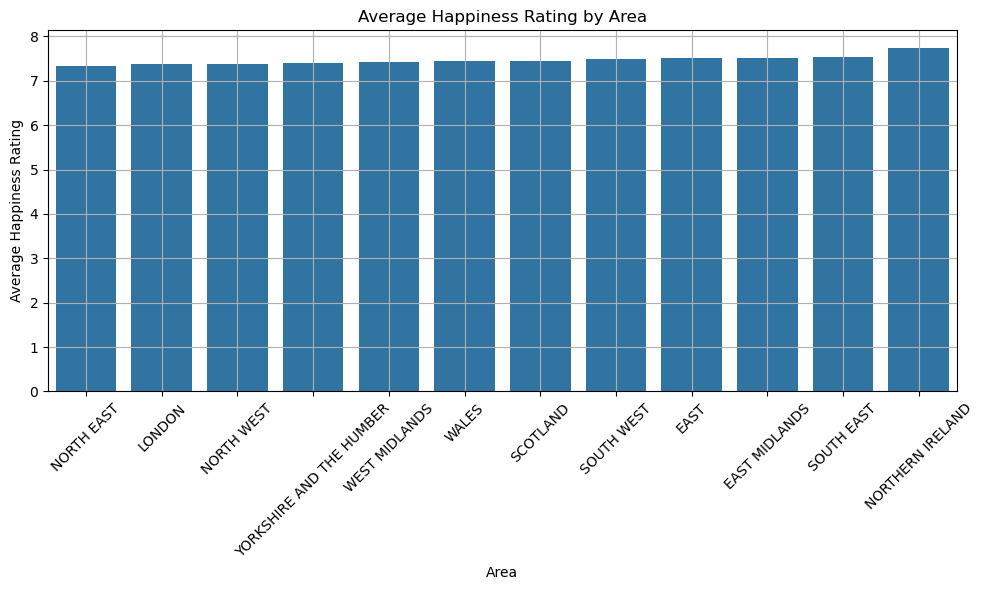

Area names
NORTH EAST                  7.34
LONDON                      7.38
NORTH WEST                  7.39
YORKSHIRE AND THE HUMBER    7.41
WEST MIDLANDS               7.43
WALES                       7.44
SCOTLAND                    7.45
SOUTH WEST                   7.5
EAST                        7.51
EAST MIDLANDS               7.51
SOUTH EAST                  7.54
NORTHERN IRELAND            7.75
Name: average raiting, dtype: object

In [1277]:
### I could see that perople from NORTHERN IRELAND have reported the highest happiness rate, let's dig deeper and see why
features_to_plot_extended = [
    'sun_Winter',
    'rain_Winter', 'af_Summer', 'rain_Spring', 'average raiting' , 'Area names', 'tmax_Summer'
]
area_grouped=merged_final[features_to_plot_extended]
area_grouped = area_grouped.groupby('Area names').mean().sort_values(by='average raiting')

plt.figure(figsize=(10, 6))
sns.barplot(x=area_grouped.index, y=area_grouped['average raiting'])
plt.title('Average Happiness Rating by Area')
plt.xlabel('Area')
plt.ylabel('Average Happiness Rating')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

area_grouped['average raiting']

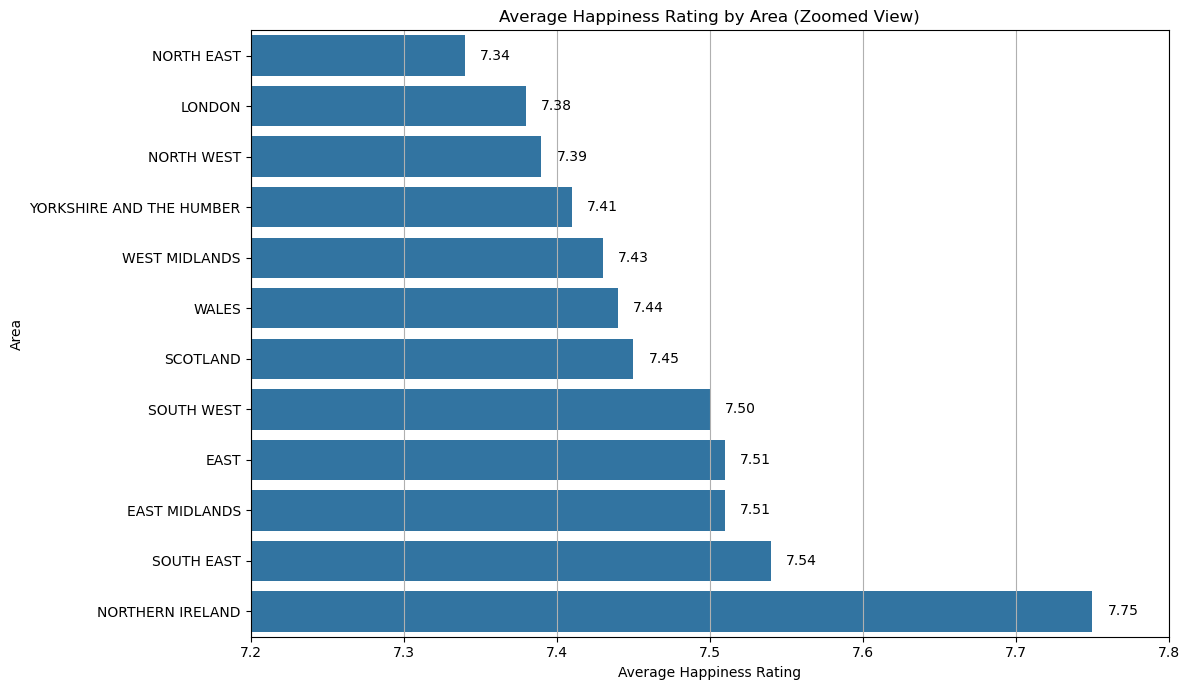

In [1279]:
### The difference is not clear from the above bar chart, let me try to zoom in the Yaxis

plt.figure(figsize=(12, 7))
sns.barplot(data=area_grouped, x='average raiting', y='Area names')

# Zoom the x-axis
plt.xlim(7.2, 7.8)

# Add exact data labels
for index, value in enumerate(area_grouped['average raiting']):
    plt.text(value + 0.01, index, f"{value:.2f}", color='black', va='center')

plt.title('Average Happiness Rating by Area (Zoomed View)')
plt.xlabel('Average Happiness Rating')
plt.ylabel('Area')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

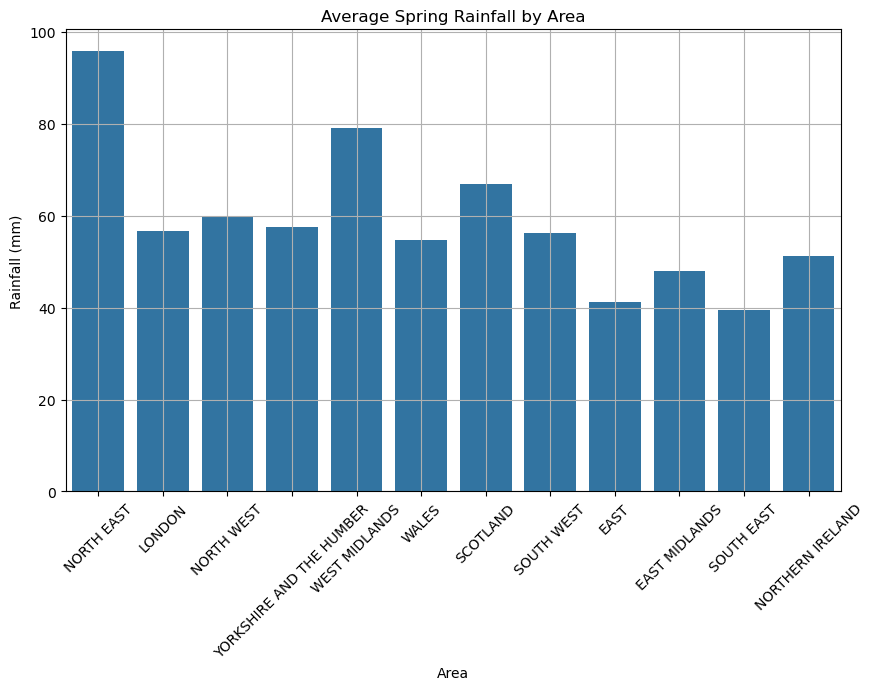

In [1281]:
## Looks better now, let' see what make perople happy the most by comparing the mean for all the featuers
area_grouped.sort_values(by='average raiting', inplace=True)
plt.figure(figsize=(10,6))
sns.barplot(x=area_grouped.index, y=area_grouped['rain_Spring'])
plt.title('Average Spring Rainfall by Area')
plt.xlabel('Area')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


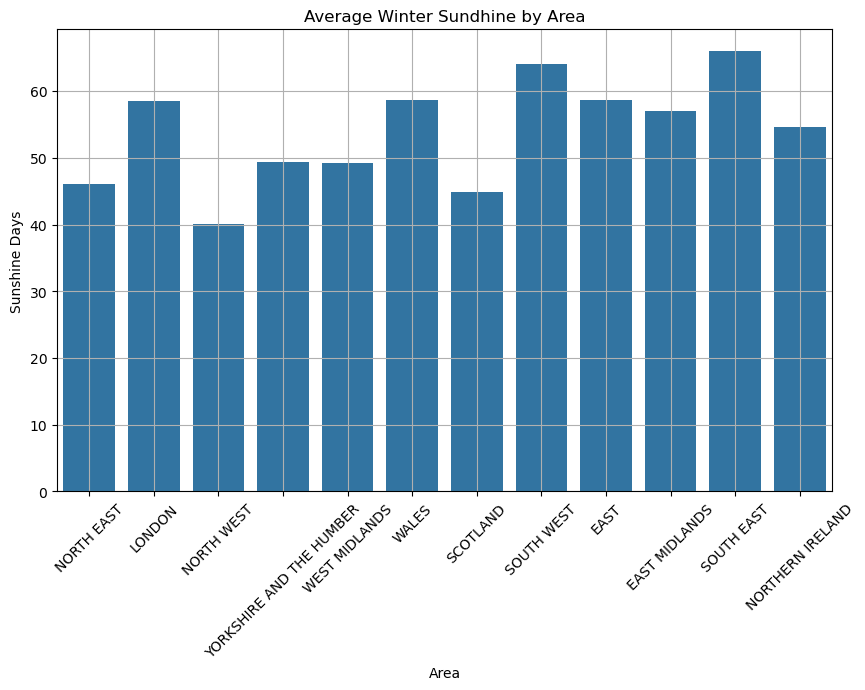

In [1285]:
area_grouped.sort_values(by='average raiting', inplace=True)
plt.figure(figsize=(10,6))
sns.barplot(x=area_grouped.index, y=area_grouped['sun_Winter'])
plt.title('Average Winter Sundhine by Area')
plt.xlabel('Area')
plt.ylabel('Sunshine Days')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [1225]:
without_northen_irleand=merged_final_numeric[merged_final_numeric['Area names'] != 'NORTHERN IRELAND']

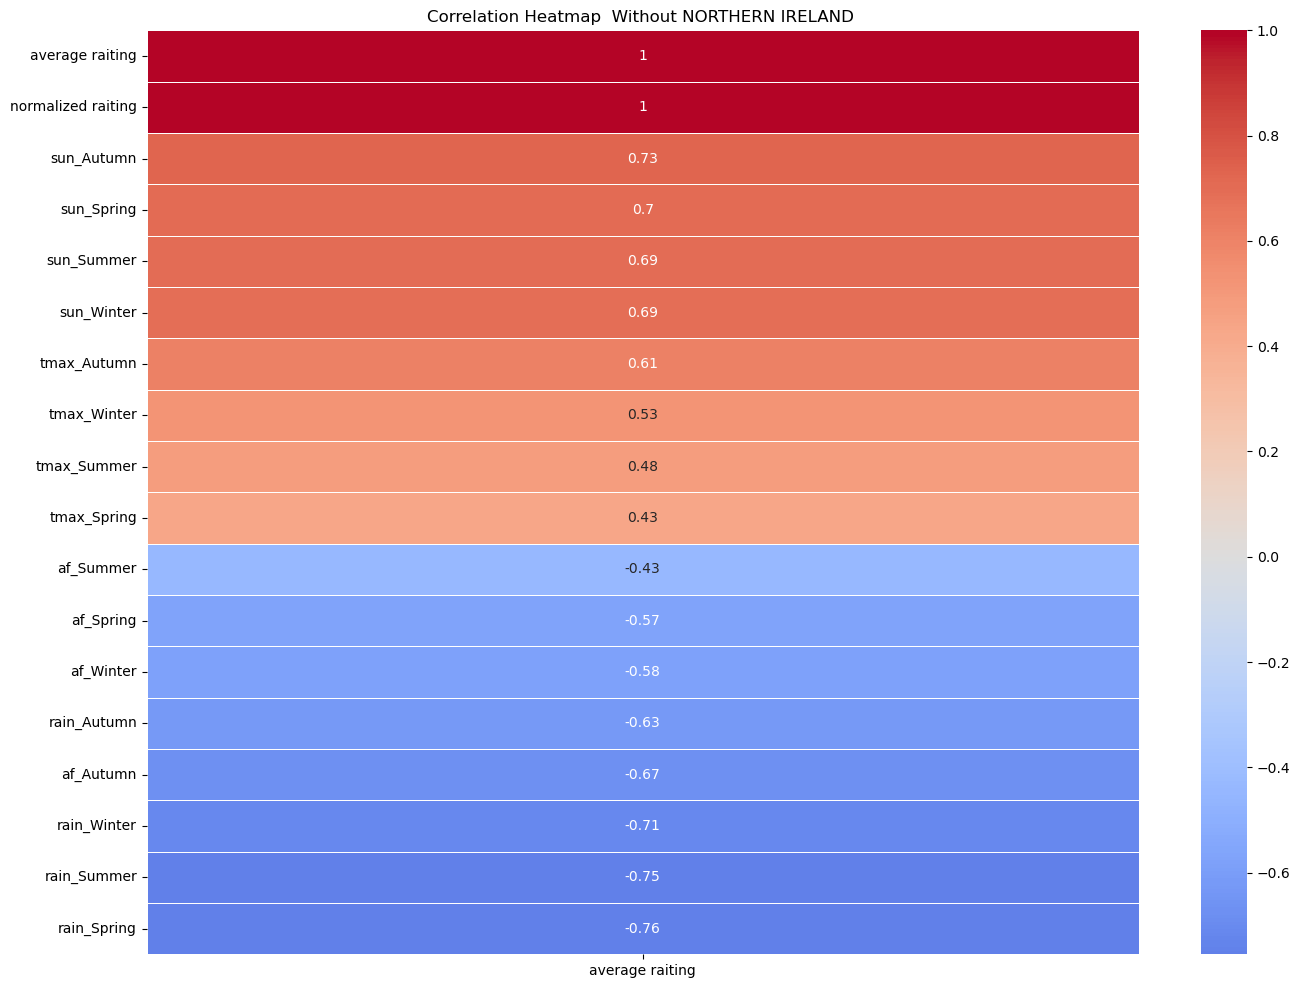

In [1396]:

plt.figure(figsize=(16, 12))
sns.heatmap(without_northen_irleand.groupby('Area names').mean().corr()[['average raiting']].sort_values(by='average raiting', ascending=False), annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title('Correlation Heatmap  Without NORTHERN IRELAND ')
plt.show()

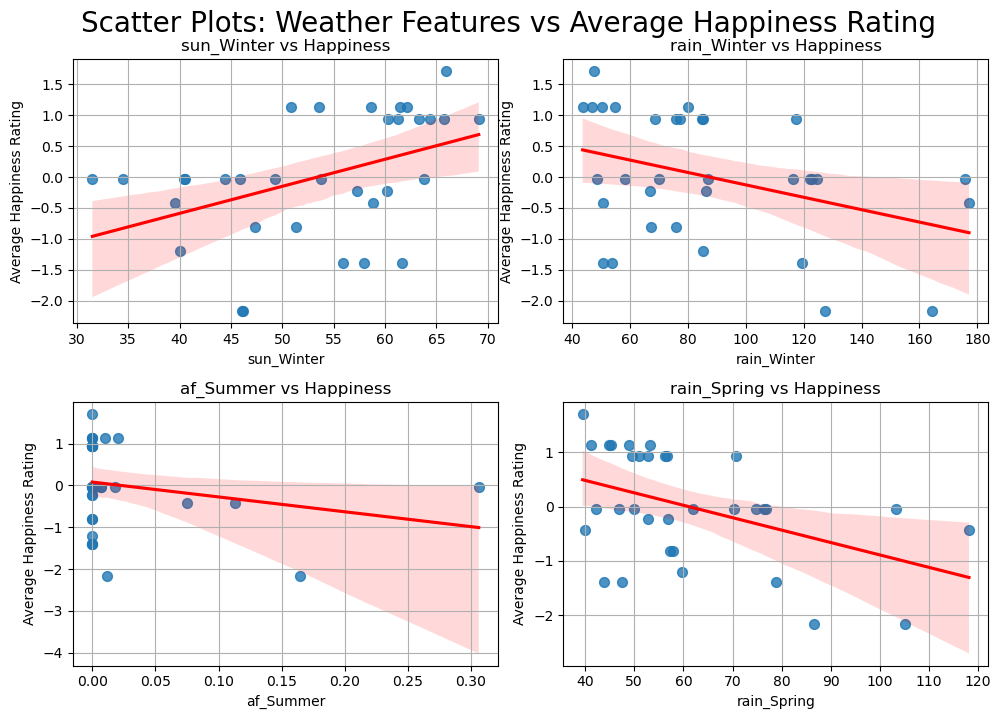

In [1339]:
## NORTHERN IRELAND are conusing me, let me see what happens if I remove them
# Define features to plot against 'average raiting'
features_to_plot_extended = [
    'sun_Winter',
    'rain_Winter', 'af_Summer', 'rain_Spring'
]

num_features = len(features_to_plot_extended)
rows = 2
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(10, 7))
axes = axes.flatten()
for idx, feature in enumerate(features_to_plot_extended):
    sns.regplot(data=without_northen_irleand, x=feature, y='normalized raiting', ax=axes[idx], scatter_kws={'s': 50}, line_kws={"color": "red"})
    axes[idx].set_title(f'{feature} vs Happiness')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Average Happiness Rating')
    axes[idx].grid(True)

plt.tight_layout()
plt.suptitle('Scatter Plots: Weather Features vs Average Happiness Rating', fontsize=20, y=1.02)
plt.show()


#### While Pearson correlations imply moderate-to-strong linear associations between seasonal weather metrics and average happiness, the real-world effect sizes are negligible (< 0.05 points on a 10-point scale) and the results are statistically fragile due to the small number of regions. We therefore interpret the findings as indicative rather than conclusive: favourable weather may coincide with slightly higher happiness, but the evidence is insufficient to assert a causal influence

In [1348]:
## I will plot all the featuers and see if there is any pattern by any chance
without_northen_irleand.columns

Index(['tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter', 'af_Autumn',
       'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn', 'rain_Spring',
       'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring', 'sun_Summer',
       'sun_Winter', 'average raiting', 'Area names', 'normalized raiting'],
      dtype='object')

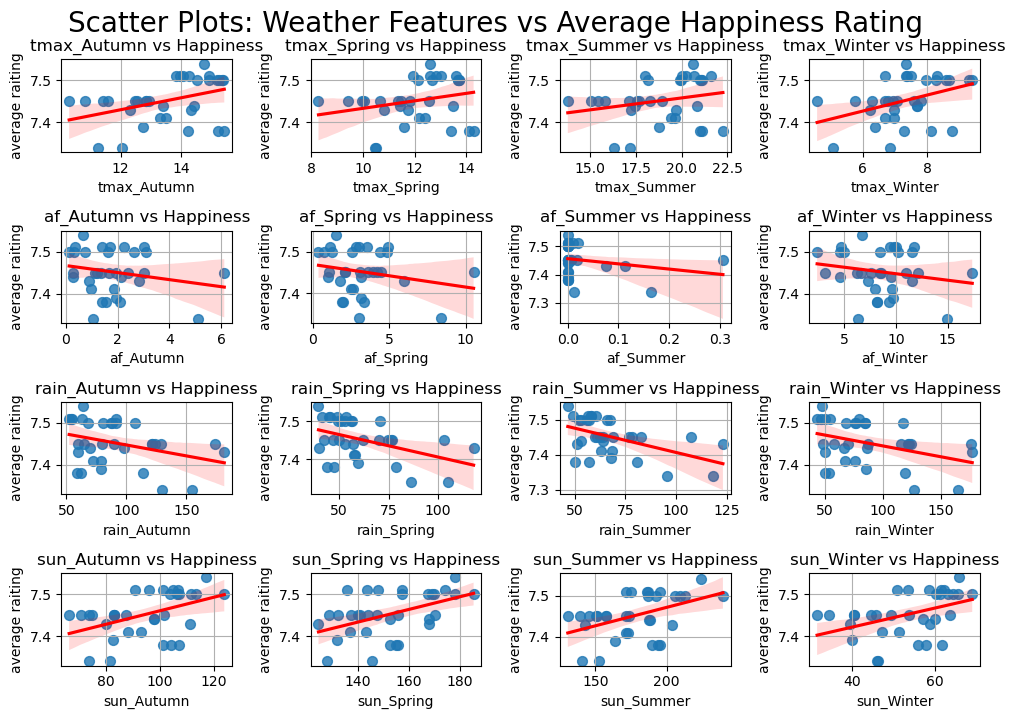

In [1370]:
columns_featuers=['tmax_Autumn', 'tmax_Spring', 'tmax_Summer', 'tmax_Winter', 'af_Autumn',
       'af_Spring', 'af_Summer', 'af_Winter', 'rain_Autumn', 'rain_Spring',
       'rain_Summer', 'rain_Winter', 'sun_Autumn', 'sun_Spring', 'sun_Summer',
       'sun_Winter']

# Prepare the plotting
num_features = len(columns_featuers)
rows = 4
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(10, 7))
axes = axes.flatten()

# Plot each feature
for idx, feature in enumerate(columns_featuers):
    sns.regplot(data=without_northen_irleand, x=feature, y='average raiting', ax=axes[idx], scatter_kws={'s': 50}, line_kws={"color": "red"})
    axes[idx].set_title(f'{feature} vs Happiness')
    axes[idx].set_xlabel(feature)
    #axes[idx].set_ylabel('Average Happiness Rating')
    axes[idx].grid(True)

plt.tight_layout()
plt.suptitle('Scatter Plots: Weather Features vs Average Happiness Rating', fontsize=20, y=1.02)
plt.show()

In [1400]:
without_northen_irleand['average raiting'].describe()

count    33.000000
mean      7.451818
std       0.052348
min       7.340000
25%       7.430000
50%       7.450000
75%       7.500000
max       7.540000
Name: average raiting, dtype: float64